In [2]:
from astropy.io import fits
import numpy as np 
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
import os.path
import warnings
from astropy.utils.exceptions import AstropyUserWarning
import ipympl
from astropy import units as u
import pyarrow.parquet as pq
from scipy.optimize import curve_fit
import pyneb as pn
from astropy.stats import median_absolute_deviation as mad
from dust_extinction.parameter_averages import F99
from astropy.coordinates import SkyCoord

#from sklearn.linear_model import TheilSenRegressor

from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import root_scalar

In [3]:

warnings.filterwarnings('ignore', category=AstropyUserWarning)

In [4]:

data_dir = '/Users/amritasingh/amrita/M8_oct30_25_final_for_paper/'
rss = data_dir+f'resolved/rss.fits' #data_dir+f'resolved/spaxel_weighted_rss_1.1.2dev0_jul8.fits'


In [5]:
# finding ccentral spaxel spectrum

270.91800051345996 [270.91772808] -24.37857153902 [-24.37443968] [1177] [1]


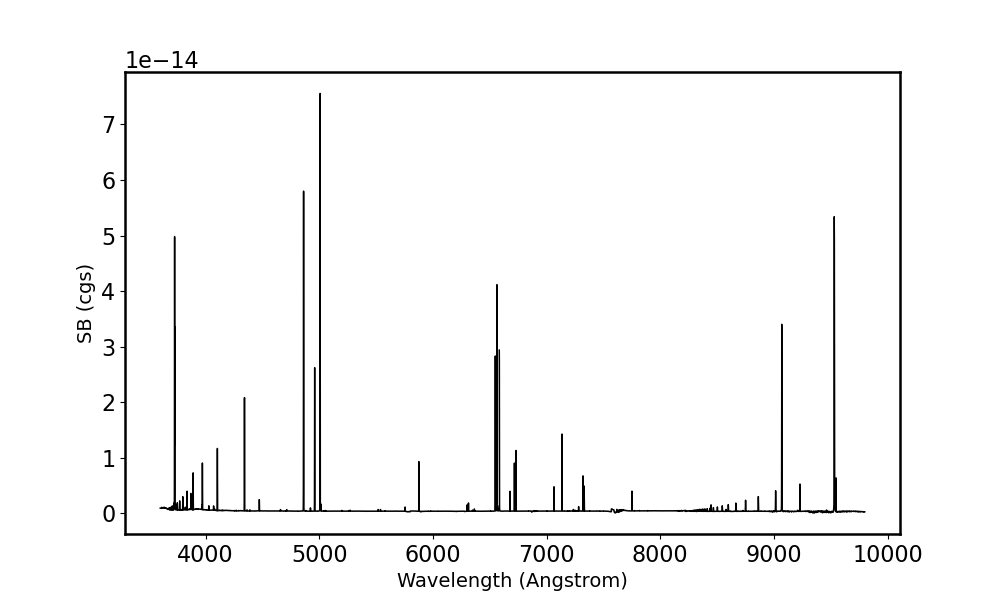

In [360]:

#Her 36 coordinates
ra_hms = '18 03 40.3201232304'
dec_dms = '-24 22 42.857540472'

coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=(u.hourangle, u.deg), frame='icrs')

# Converting RA and Dec to degrees using Skycoord
ra_center_deg = coord.ra.deg
dec_center_deg = coord.dec.deg

# finding ccentral spaxel spectrum
#ra, dec=  270.91876, -24.37906

params={
        'wave':[],
        'flux':[],
        'error':[]
        }


# Opening the rss fits file 
# added oct 27th

# opening rss fits file
with fits.open('/Users/amritasingh/amrita/M8_oct30_25_final_for_paper/lagoon_combined_multi_normalized_sframe_SPECTRA_ha_flux_1.1.2dev_jul8.fits') as hdu: 

        header = hdu[1].header
        data = hdu[1].data

        #print(repr(header), data.shape)

        wave = data['wave'][0]

        flux = data['flux']
        error = data['error']
        fiberid = data['fiberid']
        tileid =  data['tileid']

        RA, DEC = data['RA'], data['Dec']

        #if np.isclose(ra, RA, atol=1e-05).any() & np.isclose(dec, DEC, atol=1e-05).any():          
        idx = (fiberid == 1177) & (tileid == 1)

        flux = flux[idx]
        error = error[idx]  
        ra_cen = RA[idx]
        dec_cen = DEC[idx]
        fiberid = fiberid[idx]
        tileid = tileid[idx]
        wave = wave
        

        flux[~np.isfinite(flux)] = np.nan
        error[~np.isfinite(error)] = np.nan

print(ra_center_deg, ra_cen, dec_center_deg, dec_cen, fiberid, tileid)

params['wave'] = wave   
params['flux'] = flux.flatten()
params['error'] = error.flatten()

col_wave  = fits.Column(name='wave',  array=params['wave'],  format='E')  # float32
col_flux  = fits.Column(name='flux',  array=params['flux'],  format='E')
col_error = fits.Column(name='error', array=params['error'], format='E')

# create binary table
cols = fits.ColDefs([col_wave, col_flux, col_error])
hdu_table = fits.BinTableHDU.from_columns(cols)

# add units and comments
hdu_table.header['BUNIT'] = 'cgs'
hdu_table.header['COMMENT'] = 'Central spaxel spectrum extracted at RA,Dec = (270.9237, -24.3762)'

# primary HDU (empty)
primary = fits.PrimaryHDU()

# write file
hdul = fits.HDUList([primary, hdu_table])

hdul.writeto(data_dir+'integrated/multi_normalized_lagoon_central_spaxel_sframe_spectrum_1.1.2dev0.fits',
             overwrite=True)

# plotting the central spaxel spectrum
plt.figure(figsize=(10,6))
plt.plot(params['wave'].flatten(), params['flux'].flatten(), color='black', lw=1)
plt.fill_between(params['wave'].flatten(), params['flux']-params['error'], params['flux']+params['error'], color='gray', alpha=0.5)
plt.xlabel('Wavelength (Angstrom)', fontsize=14)
plt.ylabel('SB (cgs)', fontsize=14)
plt.show()



In [290]:
# average spectrum of the FOV

In [291]:
'''
# Stacking individual spectrum to create average spectrum of the FOV
params={
        'wave':[],
        'flux':[],
        'error':[]
        }

# Opening the fits file 
# added ooct 27th
with fits.open(rss) as hdu: 
        #header1 = hdu[1].header
        data = hdu[1].data
        header = hdu[1].header
        data = hdu[1].data
        wave = data['wave'][0]

        flux = data['flux']
        error = data['error']

        flux[~np.isfinite(flux)] = np.nan
        error[~np.isfinite(error)] = np.nan


        fib_num = flux.shape[0]

        # normalizing the spectrum for total number of spaxels in the FOV and area of each spaxel (assuming spaxel_r=17.65")
        flux_new=np.nansum(flux, axis=0)/(fib_num)
        error_new=np.sqrt(np.nansum(error**2, axis=0))/(fib_num)

        
params['wave'] = wave
params['flux'] = flux_new
params['error']= error_new

print(flux_new.shape, error_new.shape, wave.shape)
#print('params dict', params)
plt.plot(params['wave'].flatten(), (params['flux'].flatten()), c='black', label ='flux')
plt.plot(params['wave'].flatten(), (params['error'].flatten()), c='b', label ='error')
plt.xlabel(f'Wavelength $\AA$')
plt.ylabel(r'Intensity (erg  $s^{-1}  cm^{-2}  \AA^{-1} arcsec^{-2})$')
   
plt.legend(loc='upper right')
plt.show()

table = Table(params)
table.write(integrated_spectrum, overwrite=True)
'''

'\n# Stacking individual spectrum to create average spectrum of the FOV\nparams={\n        \'wave\':[],\n        \'flux\':[],\n        \'error\':[]\n        }\n\n# Opening the fits file \n# added ooct 27th\nwith fits.open(rss) as hdu: \n        #header1 = hdu[1].header\n        data = hdu[1].data\n        header = hdu[1].header\n        data = hdu[1].data\n        wave = data[\'wave\'][0]\n\n        flux = data[\'flux\']\n        error = data[\'error\']\n\n        flux[~np.isfinite(flux)] = np.nan\n        error[~np.isfinite(error)] = np.nan\n\n\n        fib_num = flux.shape[0]\n\n        # normalizing the spectrum for total number of spaxels in the FOV and area of each spaxel (assuming spaxel_r=17.65")\n        flux_new=np.nansum(flux, axis=0)/(fib_num)\n        error_new=np.sqrt(np.nansum(error**2, axis=0))/(fib_num)\n\n        \nparams[\'wave\'] = wave\nparams[\'flux\'] = flux_new\nparams[\'error\']= error_new\n\nprint(flux_new.shape, error_new.shape, wave.shape)\n#print(\'params di

In [292]:
# spaxel weighted integrated spectrum of the FOV

In [293]:
'''
# INPUTS
fiber_radius_arcsec = 17.65   # radius of each fiber/spaxel
A_spax = np.pi * fiber_radius_arcsec**2   # arcsec^2

# Load RSS with weights
rss1 = fits.open(rss)[1].data

wave  = rss1["wave"][0]          # wavelength grid
flux  = rss1["flux"]             # (Nspax, Nwave), surface brightness
error = rss1["error"]            # same shape
weight = rss1["weight"]          # (Nspax,)

# removing if any NaNs
flux = np.where(np.isfinite(flux), flux, 0)
error = np.where(np.isfinite(error), error, 0)

# Expand weights to match 2D shape
w2d = weight[:,None]

# Convert surface brightness to flux per spaxel
flux_spax = flux * A_spax * w2d
error_spax = error * A_spax * w2d

# Integrated flux 
flux_integrated = np.nansum(flux_spax, axis=0)

# Error propagation
error_integrated = np.sqrt(np.nansum(error_spax**2, axis=0))

# Save
tab = Table({
    "wave":  wave,
    "flux":  flux_integrated,
    "error": error_integrated
})

tab.write(spectrum, overwrite=True)

print("Integrated spectrum saved.", spectrum)
'''

'\n# INPUTS\nfiber_radius_arcsec = 17.65   # radius of each fiber/spaxel\nA_spax = np.pi * fiber_radius_arcsec**2   # arcsec^2\n\n# Load RSS with weights\nrss1 = fits.open(rss)[1].data\n\nwave  = rss1["wave"][0]          # wavelength grid\nflux  = rss1["flux"]             # (Nspax, Nwave), surface brightness\nerror = rss1["error"]            # same shape\nweight = rss1["weight"]          # (Nspax,)\n\n# removing if any NaNs\nflux = np.where(np.isfinite(flux), flux, 0)\nerror = np.where(np.isfinite(error), error, 0)\n\n# Expand weights to match 2D shape\nw2d = weight[:,None]\n\n# Convert surface brightness to flux per spaxel\nflux_spax = flux * A_spax * w2d\nerror_spax = error * A_spax * w2d\n\n# Integrated flux \nflux_integrated = np.nansum(flux_spax, axis=0)\n\n# Error propagation\nerror_integrated = np.sqrt(np.nansum(error_spax**2, axis=0))\n\n# Save\ntab = Table({\n    "wave":  wave,\n    "flux":  flux_integrated,\n    "error": error_integrated\n})\n\ntab.write(spectrum, overwrite=T

In [10]:
spectrum_name =  'integrated' #'integrated' #, 'average','ellipse_integrated', 'central_spaxel'

# spectrum and fluxes
spectrum = data_dir+f'integrated/multi_normalized_lagoon_{spectrum_name}_sframe_spectrum_1.1.2dev0.fits'
spectrum_flux = data_dir+f'integrated/multi_normalized_lagoon_{spectrum_name}_flux_1.1.2dev0.fits'
spectrum_obs_corr_flux = data_dir+f'integrated/multi_normalized_lagoon_{spectrum_name}_obs_corr_flux_1.1.2dev0_feb17_26.fits'


# Nebular diagnostics
spectrum_diag = data_dir+f'integrated/multi_normalized_lagoon_{spectrum_name}_diagnostics_1.1.2dev0_feb17_26.fits'
spectrum_teorl = data_dir+f'integrated/multi_normalized_lagoon_{spectrum_name}_teorl_1.1.2dev0_feb17_26.fits'


In [295]:
# Average spectrum of the FOV

In [296]:
'''

# Load RSS with weights
rss2 = fits.open(rss)[1].data

wave  = rss2["wave"][0]          # wavelength grid
flux  = rss2["flux"]             # (Nspax, Nwave), surface brightness
error = rss2["error"]            # same shape
weight = rss2["weight"]          # (Nspax,)

# removing if any NaNs
flux = np.where(np.isfinite(flux), flux, 0)
error = np.where(np.isfinite(error), error, 0)

# weights to match 2D shape
w2d = weight[:,None]

# weigthed flux per spaxel
flux_spax = flux * w2d  
error_spax = error * w2d 

# avg flux 
flux_integrated = np.nansum(flux_spax, axis=0)/flux.shape[0]

# Error propagation
error_integrated = np.sqrt(np.nansum(error_spax**2, axis=0))/flux.shape[0]

# Save
tab = Table({
    "wave":  wave,
    "flux":  flux_integrated,
    "error": error_integrated
})

tab.write(spectrum, overwrite=True)

print("Average spectrum saved.", spectrum)
'''


'\n\n# Load RSS with weights\nrss2 = fits.open(rss)[1].data\n\nwave  = rss2["wave"][0]          # wavelength grid\nflux  = rss2["flux"]             # (Nspax, Nwave), surface brightness\nerror = rss2["error"]            # same shape\nweight = rss2["weight"]          # (Nspax,)\n\n# removing if any NaNs\nflux = np.where(np.isfinite(flux), flux, 0)\nerror = np.where(np.isfinite(error), error, 0)\n\n# weights to match 2D shape\nw2d = weight[:,None]\n\n# weigthed flux per spaxel\nflux_spax = flux * w2d  \nerror_spax = error * w2d \n\n# avg flux \nflux_integrated = np.nansum(flux_spax, axis=0)/flux.shape[0]\n\n# Error propagation\nerror_integrated = np.sqrt(np.nansum(error_spax**2, axis=0))/flux.shape[0]\n\n# Save\ntab = Table({\n    "wave":  wave,\n    "flux":  flux_integrated,\n    "error": error_integrated\n})\n\ntab.write(spectrum, overwrite=True)\n\nprint("Average spectrum saved.", spectrum)\n'

In [297]:
plt.close('all')

In [6]:
def mklinemask(wave, line_mask_arr, left_mask_arr, right_mask_arr, line):
    
    # masking array of length same as wave with False value
    mask = np.repeat(False, len(wave))
    
    # Creating individual masks for line, and left and right continuum regions
    masking_line_range = (wave >= line_mask_arr[0]) & (wave <= line_mask_arr[1])
    masking_left_range = (wave >= left_mask_arr[0]) & (wave <= left_mask_arr[1])
    masking_right_range = (wave >= right_mask_arr[0]) & (wave <= right_mask_arr[1])

    # continuum mask by combining left and right ranges
    continuum_mask = masking_left_range | masking_right_range

    # Total mask
    total_mask = masking_line_range | continuum_mask

    return total_mask



In [7]:
'''
Single, double and triple Gaussian function.
inputs: wave: wavlength

flux: flux
mean: rest frame wavelength
sd: standard dev.
cont: continuum

Output: Gaussian fitting function calculated for given parameters
'''

# Gaussian + quadratic continuum
def gauss_plus_quad(wave, flux, mean, sd, c0, c1, c2):
    cont = c0 + c1 * (wave - mean) + c2 * (wave - mean)**2
    return cont + flux / (np.sqrt(2 * np.pi) * sd) * np.exp(-(wave - mean) ** 2 / (2 * sd ** 2))


#single gaussian function with 4 input params
def gaussian(wave, flux, mean, sd, cont):

    return cont + flux / (np.sqrt(2 * np.pi) * sd) * np.exp(-(wave - mean) ** 2 / (2 * sd ** 2))

# ==================================================== Double gaussians ===================================================================#
#Double gaussian function with 7 input params, linear continua
def double_gaussian(wave, flux1, mean1, sd1, flux2, mean2, cont):
    
    return (cont + gaussian(wave, flux1, mean1, sd1, 0) +
            gaussian(wave, flux2, mean2, sd1, 0))


# fixing 4363 vel shift wrt fe, quad continua, october 8th, 25

#Double gaussian function with 6 input params
def double_gaussian_quad_cont_vel_shift(wave, flux1, sd1, flux2, c0, c1, c2, vel_shift_hgm=60):
    c = 299792.458

    # 4363 shifted accordingly
    mean1 = 4359.340 * (1 + vel_shift_hgm / c)
    mean2 = 4363.209 * (1 + vel_shift_hgm / c)

    # --- continuum 
    wave_ref = mean2  
    cont = c0 + c1 * (wave - wave_ref) + c2 * (wave - wave_ref)**2

    
    return (cont +
             gaussian(wave, flux1, mean1, sd1, 0) +
             gaussian(wave, flux2, mean2, sd1, 0))


#Double gaussian function with 7 input params, quad continua
def double_gaussian_quad(wave, flux1, mean1, sd1, flux2, mean2, c0, c1, c2):
    cont = c0 + c1*(wave - mean1) + c2*(wave - mean1)**2

    return (cont + gaussian(wave, flux1, mean1, sd1, 0) +
            gaussian(wave, flux2, mean2, sd1, 0))



# ==================================================================================================================================================#

#Triple gaussian function with 10 input params
def triple_gaussian(wave, flux1, mean1, sd1, vel_shift, flux2, flux3, cont):

    lw = [0, 9.19, 21.74]
    c = 299792.458  # Speed of light in km/s
    observed_wavelengths = (mean1 + np.array(lw)) * (1 + vel_shift / c)
    
    return (cont +
            gaussian(wave, flux1, observed_wavelengths[0], sd1, 0) +
            gaussian(wave, flux2, observed_wavelengths[1], sd1, 0) +
            gaussian(wave, flux3, observed_wavelengths[2], sd1, 0) )

# Fitting 10 gaussians to OII RLs
def ten_gaussian(wave, flux1, line1, sd1, vel_shift, flux2, flux3, flux4, flux5, flux6, flux7, flux8, flux9, flux10, cont):
    
    lw = [0, 14.19, 23.38, 31.69, 34.65, 35.93, 41.97, 43.68, 51.01, 54.47, 69.07]
    
    c = 299792.458  # Speed of light in km/s
    observed_wavelengths = (line1 + np.array(lw)) * (1 + vel_shift / c)

    return (cont +
            gaussian(wave, flux1, observed_wavelengths[0], sd1, 0) +
            gaussian(wave, flux2, observed_wavelengths[1], sd1, 0) +
            gaussian(wave, flux3, observed_wavelengths[2], sd1, 0) +
            gaussian(wave, flux4, observed_wavelengths[3], sd1, 0) +
            gaussian(wave, flux5, observed_wavelengths[4], sd1, 0) +
            gaussian(wave, 1.37*flux1, observed_wavelengths[5], sd1, 0) +
            gaussian(wave, flux6, observed_wavelengths[6], sd1, 0) +
            gaussian(wave, flux7, observed_wavelengths[7], sd1, 0)+
            gaussian(wave, flux8, observed_wavelengths[8], sd1, 0) +
            gaussian(wave, flux9, observed_wavelengths[9], sd1, 0) +
            gaussian(wave, flux10, observed_wavelengths[10], sd1, 0))

# 10 gaussian fits with quadratic continua
def ten_gaussian_quad(wave, flux1, line1, sd1, vel_shift, flux2, flux3, flux4, flux5, flux6, flux7, flux8, flux9, flux10, c0, c1, c2):
    
    lw = [0, 14.19, 23.38, 31.69, 34.65, 35.93, 41.97, 43.68, 51.01, 54.47, 69.07]
    
    c = 299792.458  # Speed of light in km/s
    observed_wavelengths = (line1 + np.array(lw)) * (1 + vel_shift / c)

    cont = c0 + c1 * (wave - observed_wavelengths[6]) + c2 * (wave - observed_wavelengths[6])**2

    return (cont +
            gaussian(wave, flux1, observed_wavelengths[0], sd1, 0) +
            gaussian(wave, flux2, observed_wavelengths[1], sd1, 0) +
            gaussian(wave, flux3, observed_wavelengths[2], sd1, 0) +
            gaussian(wave, flux4, observed_wavelengths[3], sd1, 0) +
            gaussian(wave, flux5, observed_wavelengths[4], sd1, 0) +
            gaussian(wave, 1.37*flux1, observed_wavelengths[5], sd1, 0) +
            gaussian(wave, flux6, observed_wavelengths[6], sd1, 0) +
            gaussian(wave, flux7, observed_wavelengths[7], sd1, 0)+
            gaussian(wave, flux8, observed_wavelengths[8], sd1, 0) +
            gaussian(wave, flux9, observed_wavelengths[9], sd1, 0) +
            gaussian(wave, flux10, observed_wavelengths[10], sd1, 0))



# siete Gaussian

#7 gaussian function with 12 input params
def siete_gaussian_quad(wave, flux1, mean1, sd1, flux2, flux3, flux4, flux5, flux6, flux7, c0, c1, c2, vel_shift=60): 
    
    lw = [0, 2.95, 10.27, 11.98, 19.31, 22.77, 37.37]
    
    c = 299792.458  # Speed of light in km/s
    observed_wavelengths = (mean1 + np.array(lw)) * (1 + vel_shift / c)

    cont = c0 + c1 * (wave - observed_wavelengths[0]) + c2 * (wave - observed_wavelengths[0])**2

    fit = (cont +
           gaussian(wave, flux1, observed_wavelengths[0], sd1, 0) +                         # 4638, free parameter
           gaussian(wave, flux2, observed_wavelengths[1], sd1, 0) +    # 4641
           gaussian(wave, flux3, observed_wavelengths[2], sd1, 0) +    # 4649
           gaussian(wave, flux4, observed_wavelengths[3], sd1, 0) +    # 4651
           gaussian(wave, flux5, observed_wavelengths[4], sd1, 0) +                         # Fe4658, free parameter
           gaussian(wave, flux6, observed_wavelengths[5], sd1, 0) +    # 4662
           gaussian(wave, flux7, observed_wavelengths[6], sd1, 0))     # 4676

    return fit


def oii_ratios(n):

    atom = pn.RecAtom('O', 2)

    wavelengths = [4638.86, 4641.81, 4649.13, 4650.84, 4661.63, 4676.23, 4673.73, 4696.35]

    Te_range = np.linspace(6000, 10000, n)
    ne_range = np.logspace(2, 3, n)

    Te_grid, ne_grid = np.meshgrid(Te_range, ne_range)

    # Initialize arrays for emissivities and ratios
    emis = [np.zeros_like(Te_grid) for _ in range(len(wavelengths))]  
    ratios = [np.zeros_like(Te_grid)   for _ in range(1, len(wavelengths))]

    for i in range(Te_grid.shape[0]):
        for j in range(Te_grid.shape[1]):

            Te = Te_grid[i, j]
            ne = ne_grid[i, j]

            # Calculate emissivity for each wavelength and store it in the emis list
            for k, wl in enumerate(wavelengths):
                emis[k][i, j] = atom.getEmissivity(tem=Te, den=ne, wave=wl)

            #  Calculate the ratio of each emissivity w.r.t. the first one (emis[0])
            for n in range(1, len(wavelengths)):  
                ratios[n - 1][i, j] = emis[n][i, j] /emis[0][i, j]

    # Table of Te, ne, and ratios
    table = []
    for i in range(Te_grid.shape[0]):
        for j in range(Te_grid.shape[1]):
            row = [Te_grid[i, j], ne_grid[i, j]] + [ratios[n][i, j] for n in range(len(ratios))]
            table.append(row)

    return np.array(table)


In [8]:
'''
Function to fit single Gaussian to emission lines 

Inputs: 
wave: wavelength 
spectrum: flux 
error: error 
lwave: centroid wavlength 
continuum_rangea: an array of wavelengths to calculate continuum 
dwave: difference in wavelength
plot: True/False to produce plots of linefits(boolean) 
plotout: plot name

Outputs:
Returns optimal parameters and covariance matrix on fitting the emission lines

ANOTHER OPTION CAN BE TO MAKE TWO CONTINUUM MASKS (LEFT AND RIGHT FOR EACH CENTRIOD WAVELENGTH)

'''

def fit_gauss(wave, spectrum, error, lwave, dwave=6, plot=True, plotout='linefit', n_iter = 500):

    # Making a selection mask on wavelength windows,finite flux and error values 
    sel = (wave > lwave - dwave / 2) & (wave < lwave + dwave / 2) & np.isfinite(spectrum) & np.isfinite(error)
    
    init_flux = np.abs(np.nanmax(spectrum[sel]) - np.nanmin(spectrum[sel])) * np.sqrt(2 * np.pi) * 0.7
    init_cont = np.nanmin(spectrum[sel])
    p0 = (init_flux, lwave, 0.7, init_cont)

    # Fitting to the original spectrum
    try:

        sel_goodpix = np.isfinite(spectrum)*np.isfinite(error)*np.isfinite(wave)

        popt, pcov = curve_fit(gaussian, wave[sel_goodpix], spectrum[sel_goodpix], sigma=error[sel_goodpix], p0=p0, absolute_sigma=True,
                               bounds=((0, lwave - 2.0, 0.5, -np.inf), (np.inf, lwave + 3.0, 0.9, np.inf)))
    except RuntimeError:
        popt = np.array([-99, p0[1], p0[2], p0[3]])
        pcov = np.zeros((4, 4))
        pcov[0, 0] = np.sum(error ** 2)

    xm = wave
    ym = gaussian(xm, *popt)
    chi2 = np.nansum((spectrum - ym) ** 2 / error ** 2) / (len(spectrum) - len(popt))


    if plot:

        fig, ax = plt.subplots(figsize=(8, 6))
        plt.rcParams.update({'axes.titlesize': '18.0', 'axes.labelsize': '16.0', 'axes.linewidth': '1.8',
                             'ytick.labelsize': '16.0', 'xtick.labelsize': '16.0', 'font.size': '10.0',
                             'legend.fontsize': 'small'})
        
        ax.errorbar(wave, spectrum * 1e-17, error * 1e-17, c='k', label='data')
        ax.scatter(wave, spectrum * 1e-17, c='b', label='data')
        ax.plot(xm, ym * 1e-17, c='r', label='model')


        ax.set_ylim(np.nanmin([0, np.nanmin(spectrum - error) * 1e-17]), 1.5 * np.nanmax([np.nanmax(spectrum) * 1e-17, np.nanmax(ym) * 1e-17]))
        ax.set_xlim(lwave - dwave * 2, lwave + dwave * 2)

        ax.set_xlabel(r'Wavelength $\AA$')
        ax.set_ylabel(r'Flux ( erg  $s^{-1}  cm^{-2}  \AA^{-1} arcsec^{-2})$')
        
        ax.legend()
        plt.savefig(data_dir+f'integrated/linefits/{spectrum_name}_{plotout}_1.1.2dev0.png', dpi=100)
        plt.close()
    return popt, pcov

In [9]:
def fit_gauss_quad(wave, spectrum, error, lwave, dwave=8, plot = True, plotout='linefit_quad'):
   
    # Making a selection mask on wavelength windows,finite flux and error values 
    sel = (wave > lwave - dwave / 2) * (wave < lwave + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error)) 

    # Check if the selection is valid
    if not np.any(sel):
        print(f"Warning: no valid data in window for line {lwave}")
        return np.array([-99, lwave, 0.7, 0.0]), np.zeros((4, 4))


    # Initial params for the Gaussian fit
    init_flux = np.abs(spectrum[sel].max() - spectrum[sel].min()) * np.sqrt(2 * np.pi) * 0.7
    c0, c1, c2 = np.nanmin(spectrum[sel]), 0, 0
    
    p0 = (init_flux, lwave, 0.7, c0, c1, c2)
    bounds = ([0, lwave-1, 0.5, -np.inf, -np.inf, -np.inf],[np.inf, lwave+1, 0.9, np.inf, np.inf, np.inf])

    try:

        sel_goodpix = np.isfinite(spectrum)*np.isfinite(error)*np.isfinite(wave)

    # calculating optimal parameters and covariance matrix
        popt, pcov = curve_fit(gauss_plus_quad, wave[sel_goodpix], spectrum[sel_goodpix], sigma=error[sel_goodpix], p0=p0, absolute_sigma=True,
                               bounds=bounds)
        
    except RuntimeError:
        popt = np.array([-99, p0[1], p0[2], p0[3]])
        pcov = np.zeros((4, 4))
    
        pcov[0, 0] = np.sum(error** 2)

    
    nparam=len(popt) #no. of parameters
    xm = wave
    ym = gauss_plus_quad(xm, *popt)

    print(lwave, np.nanmedian(ym - spectrum))
    
    # calculating weighted chi**2 value
    chi2=np.nansum((spectrum-ym)**2/error**2)/(len(spectrum)-nparam) 

    if plot==True:

        plt.rcParams.update({'axes.titlesize': 'Large',
                 'axes.labelsize':'Large',
                 'axes.linewidth':     '1.8' ,
                 'ytick.labelsize': '14.0',
                 'xtick.labelsize': '14.0',
                 'font.size': '14.0',
                 'legend.fontsize':'small'})
        
        fig = plt.figure(figsize = (8, 6))
        ax = fig.add_subplot(111)

        # Plotting
        #ax.step(wave, spectrum, alpha=0.5, label='steps')
        ax.errorbar(wave, spectrum, error, c='k', label='data')
        ax.scatter(wave, spectrum, c='b', label='data')
        ax.plot(xm, ym, c='r', label='model')

        #ax.set_ylim(spectrum[sel].min(),1.7*np.max([spectrum[sel].max(), (ym+3*sigma).max()]))
        ax.set_ylim(np.min([0,(spectrum[sel_goodpix]).min()]), 1.7*np.max([spectrum[sel_goodpix].max(), ym.max()]))
        ax.set_xlim(lwave-dwave*2, lwave+dwave*2)       
        ax.set_xlabel(r'Wavelength $\AA$')
        ax.set_ylabel(r' SB$(10^{-17} \times erg\, s^{-1} \,cm^{-2}\, \AA^{-1}\, arcsec^{-2})$')   
        ax.set_title(f'{lwave:.0f} line fit')
        ax.legend()
        plt.tight_layout()

        plt.savefig(data_dir+f'integrated/linefits/{spectrum_name}_{plotout}_1.1.2dev0.png', dpi =100)
        plt.close()

    return popt, pcov# calculating optimal parameters and covariance matrix


In [10]:
'''
Function to fit double Gaussian to emission lines (for [OII]3726, 3729, [OIII]4363 and [FeII]4360)

Inputs: 
wave: wavelength 
spectrum: flux 
error: error 
lwave1: centroid wavlength of first line
lwave2: centroid wavlength of second line
dwave: difference in wavelength
plot: True/False to produce plots of linefits(boolean) 
plotout: plot name

Outputs:
Returns optimal parameters and covariance matrix on fitting the emission lines
'''


def fit_double_gauss_quad_vel_shift(wave, spectrum, error, lwave1, lwave2, vel = 60, plot=True, plotout='linefit'):

    dwave=4


    # Making a selection masks on wavelength windows for each rest frame wavelength, finite flux and error values 
    sel1 = (wave > lwave1 - dwave / 2) * (wave < lwave1 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error)) 
    sel2 = (wave > lwave2 - dwave / 2) * (wave < lwave2 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel = (wave > lwave1 - dwave / 2) * (wave < lwave2 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    c0, c1, c2 = np.nanmin(spectrum[sel]), 0.0, 0.0

    p0 = (0, 0.7, 0, c0, c1, c2)
     
    try:
        sel_goodpix = np.isfinite(spectrum)*np.isfinite(error)*np.isfinite(wave)
        wave, spectrum, error = wave[sel_goodpix], spectrum[sel_goodpix], error[sel_goodpix]


        # defining bounds
        bounds = ([0, 0.5, -np.inf, -np.inf, -np.inf, -np.inf],
                [np.inf, 0.75, np.inf, np.inf, np.inf, np.inf])

        # calculating optimal parameters and covariance matrix
        popt, pcov = curve_fit(double_gaussian_quad_cont_vel_shift, wave, spectrum, sigma=error, p0=p0, absolute_sigma=True,
            bounds=bounds)
        
        
    except RuntimeError as e:
        popt = np.array([-99, 0.7, -99,-99, c1, c2])
        pcov = np.zeros((7, 7))
        pcov[0, 0] = np.sum(error ** 2)
        infodict, mesg, ier = {}, str(e), -1

    
    nparam=len(popt) #no. of parameters
    xm = wave
    ym = double_gaussian_quad_cont_vel_shift(xm, *popt, vel)

    # calculating weighted chi**2 value
    chi2=np.nansum((spectrum-ym)**2/error**2)/(len(spectrum)-nparam)

    if plot==True:

        xm = wave

        plt.rcParams.update({'axes.titlesize': 'X-Large',
                 'axes.labelsize':'X-Large',
                 'axes.linewidth':     '1.8' ,
                 'ytick.labelsize': '16.0',
                 'xtick.labelsize': '16.0',
                 'font.size': '16.0',
                 'legend.fontsize':'small'})
        
        fig = plt.figure(figsize = (12, 8))
        ax = fig.add_subplot(111)
 
        #Final plotting
        ax.errorbar(wave, spectrum, error, c='k', label='Error bar')
        ax.scatter(wave, spectrum, c='b', label='Data')
        ax.plot(xm, ym, c='r', label='Model')

        ax.set_title(fr'F1={popt[2]:.2f}e-17; F1 err={np.sqrt(pcov[2,2]):.3f}e-17 ; $\sigma_1=${popt[1]:.2f} ; c0, c1, c2: {popt[3]:.2f}e-17, {popt[4]:.3f}e-17, {popt[5]:.3f}e-17', fontsize=12) #C={popt[6]:.2f}e-13 ; $\chi^2=${chi2:.2f}, 
        
        ax.set_ylim(np.min([0,(spectrum-error).min()]), 1.7*np.max([spectrum.max(), ym.max()]))
        ax.set_xlim(lwave1-dwave*3, lwave2+dwave*4)
        ax.set_xlabel(r'Wavelength $\AA$')
        ax.set_ylabel(r' SB$(10^{-17} \times erg \,s^{-1}\, cm^{-2}\, \AA^{-1} \, arcsec^{-2})$')
        ax.legend()
        plt.tight_layout()
        
        #Save the figure
        plt.savefig(data_dir+f'integrated/linefits/{spectrum_name}_{plotout}_quad_flux(p0=0)_vel_fix_to_5007.png', dpi =200)
        plt.close()
        
    return popt, pcov

In [11]:
'''
Function to fit double Gaussian to emission lines (for [OII]3726, 3729, [OIII]4363 and [FeII]4360)

Inputs: 
wave: wavelength 
spectrum: flux 
error: error 
lwave1: centroid wavlength of first line
lwave2: centroid wavlength of second line
dwave: difference in wavelength
plot: True/False to produce plots of linefits(boolean) 
plotout: plot name

Outputs:
Returns optimal parameters and covariance matrix on fitting the emission lines
'''

def fit_double_gauss_quad(wave, spectrum, error, lwave1, lwave2, plot=True, plotout='linefit'):

    dwave=4

    # Making a selection masks on wavelength windows for each rest frame wavelength, finite flux and error values 
    sel1 = (wave > lwave1 - dwave / 2) * (wave < lwave1 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error)) 
    sel2 = (wave > lwave2 - dwave / 2) * (wave < lwave2 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel = (wave > lwave1 - dwave / 2) * (wave < lwave2 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    c0, c1, c2 = np.nanmin(spectrum[sel]), 0.0, 0.0

    #initial parameters for the Gaussian fit
    p0 = (np.abs(spectrum[sel1].max()- spectrum[sel1].min()) * np.sqrt(2 * np.pi) * 0.7, lwave1, 0.7, 
          np.abs(spectrum[sel2].max()- spectrum[sel2].min()) * np.sqrt(2 * np.pi) * 0.7, lwave2, c0, c1, c2)
     
    try:
        sel_goodpix = np.isfinite(spectrum)*np.isfinite(error)*np.isfinite(wave)
        wave, spectrum, error = wave[sel_goodpix], spectrum[sel_goodpix], error[sel_goodpix]

        # defining bounds
        bounds = ([0, lwave1 - 1, 0.5, 0, lwave2 - 1, -np.inf, -np.inf, -np.inf],
                [np.inf, lwave1 + 1,  0.9, np.inf, lwave2 + 1, np.inf, np.inf, np.inf])

        # calculating optimal parameters and covariance matrix
        popt, pcov = curve_fit(double_gaussian_quad, wave, spectrum, sigma=error, p0=p0, absolute_sigma=True,
                               bounds=bounds)
        
    except RuntimeError:
        popt = np.array([-99, lwave1, -99, lwave2, 0.7, -99, c1, c2])
        pcov = np.zeros((7, 7))
        pcov[0, 0] = np.sum(error ** 2)

    
    nparam=len(popt) #no. of parameters
    xm = wave
    ym = double_gaussian_quad(xm, *popt)
    print(lwave2, np.nanmedian(ym - spectrum))

    # calculating weighted chi**2 value
    chi2=np.nansum((spectrum-ym)**2/error**2)/(len(spectrum)-nparam)

    if plot==True:

        xm = wave

        plt.rcParams.update({'axes.titlesize': 'X-Large',
                 'axes.labelsize':'X-Large',
                 'axes.linewidth':     '1.8' ,
                 'ytick.labelsize': '16.0',
                 'xtick.labelsize': '16.0',
                 'font.size': '16.0',
                 'legend.fontsize':'small'})
        
        fig = plt.figure(figsize = (12, 8))
        ax = fig.add_subplot(111)
 
        #Final plotting
        ax.errorbar(wave, spectrum, error, c='k', label='Error bar')
        ax.scatter(wave, spectrum, c='b', label='Data')
        ax.plot(xm, ym, c='r', label='Model')

        ax.set_title(fr' F1={popt[2]:.2f}e-17; F1 err={np.sqrt(pcov[2, 2]):.3f}e-17 ; $\lambda_1$={popt[3]:.2f} ; $\sigma_1=${popt[4]:.2f} ; resi:{np.nanmedian(ym-spectrum):.3f}', fontsize=12) #C={popt[6]:.2f}e-13 ; $\chi^2=${chi2:.2f}, 
        ax.set_ylim(np.min([0,(spectrum-error).min()]), 1.7*np.max([spectrum.max(), ym.max()]))
        ax.set_xlim(lwave1-dwave*3, lwave2+dwave*4)
        ax.set_xlabel(r'Wavelength $\AA$')
        ax.set_ylabel(r' SB$(10^{-17} \times erg \,s^{-1}\, cm^{-2}\, \AA^{-1} \, arcsec^{-2})$')
        ax.legend()
        plt.tight_layout()
        
        #Save the figure
        plt.savefig(data_dir+f'integrated/linefits/{spectrum_name}_{plotout}.png', dpi =100)
        plt.close()
    return popt, pcov

In [12]:
'''
Function to fit double Gaussian to emission lines (for [OII]3726, 3729, [OIII]4363 and [FeII]4360)

Inputs: 
wave: wavelength 
spectrum: flux 
error: error 
lwave1: centroid wavlength of first line
lwave2: centroid wavlength of second line
dwave: difference in wavelength
plot: True/False to produce plots of linefits(boolean) 
plotout: plot name

Outputs:
Returns optimal parameters and covariance matrix on fitting the emission lines
'''

def fit_double_gauss(wave, spectrum, error, lwave1, lwave2, dwave=6, plot=True, plotout='linefit'):
    
    # Making a selection masks on wavelength windows for each rest frame wavelength, finite flux and error values 
    sel1 = (wave > lwave1 - dwave / 2) * (wave < lwave1 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error)) 
    sel2 = (wave > lwave2 - dwave / 2) * (wave < lwave2 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel = (wave > lwave1 - dwave / 2) * (wave < lwave2 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    
    #initial parameters for the Gaussian fit
    p0 = (np.abs(np.nanmax(spectrum[sel1])- np.nanmin(spectrum[sel1])) * np.sqrt(2 * np.pi) * 0.7, lwave1, 0.7,  
          np.abs(np.nanmax(spectrum[sel2])- np.nanmin(spectrum[sel2])) * np.sqrt(2 * np.pi) * 0.7, lwave2, np.nanmin(spectrum[sel]))
    

    # Fitting to the original spectrum
    try:

        sel_goodpix = np.isfinite(spectrum)*np.isfinite(error)*np.isfinite(wave)

        # calculating optimal parameters and covariance matrix
        popt, pcov = curve_fit(double_gaussian, wave[sel_goodpix], spectrum[sel_goodpix], sigma=error[sel_goodpix], p0=p0, absolute_sigma=True,
                               bounds=((0, lwave1 - 2, 0.5, 0, lwave2 - 2, -np.inf),
                                       (np.inf, lwave1 + 1, 0.9, np.inf, lwave2 + 2, np.inf)))
        
    except RuntimeError:

        popt = np.array([-99, lwave1, 0.7, -99, lwave2, np.nanmin(spectrum)])
        pcov = np.zeros((7, 7))
        pcov[0, 0] = np.sum(error ** 2)

    
    nparam=len(popt) #no. of parameters
    xm = wave
    ym = double_gaussian(xm, *popt)

    # calculating weighted chi**2 value
    chi2=np.nansum((spectrum-ym)**2/error**2)/(len(spectrum)-nparam)

    if plot==True:

        xm = wave
        #sigma = get_gaussian_ci(xm, gaussian, popt, pcov)
        fig = plt.figure(figsize = (10, 6))
        ax = fig.add_subplot(111)
        
        plt.rcParams.update({'axes.titlesize': '18.0',
                 'axes.labelsize':'16.0',
                 'axes.linewidth':     '1.8' ,
                 'ytick.labelsize': '16.0',
                 'xtick.labelsize': '16.0',
                 'font.size': '10.0',
                 'legend.fontsize':'small'})

        #Final plotting
        #Plotting final output
        ax.errorbar(wave, spectrum*1e-17, error*1e-17, c='k', label='data')
        ax.scatter(wave, spectrum*1e-17, c='b', label='data')
        ax.plot(xm, ym*1e-17, c='r', label='model')

        ax.set_ylim(np.nanmin([0, np.nanmin((spectrum-error)[sel1])*1e-17]), 1.5*np.nanmax([np.nanmax((spectrum-error)[sel1])*1e-17, np.nanmax(ym)*1e-17]))
        ax.set_xlim(lwave1-dwave*2, lwave2+dwave*2)
        ax.set_xlabel(r'Wavelength $\AA$')
        ax.set_ylabel(r'Flux ( erg  $s^{-1}  cm^{-2}  \AA^{-1} arcsec^{-2}$)')
        ax.legend()
       
        #Save the figure
        plt.savefig(data_dir+f'integrated/linefits/{spectrum_name}_{plotout}_1.1.2dev0.png', dpi =200) #_central_spaxel
        plt.close()
    return popt, pcov

In [13]:
def fit_double_gauss_kinematic(wave, spectrum, error, lwave1, lwave2, dwave=5, plot=True, plotout='linefit'):
    
    # Making a selection masks on wavelength windows for each rest frame wavelength, finite flux and error values 

    sel1 = (wave > lwave1 - dwave / 2) * (wave < lwave1 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error)) 
    sel2 = (wave > lwave2 - dwave / 2) * (wave < lwave2 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel = (wave > lwave1 - dwave / 2) * (wave < lwave2 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    
    #initial parameters for the Gaussian fit
    p0 = (np.abs(np.nanmax(spectrum[sel1])- np.nanmin(spectrum[sel1])) * np.sqrt(2 * np.pi) * 0.6,  
          np.abs(np.nanmax(spectrum[sel2])- np.nanmin(spectrum[sel2])) * np.sqrt(2 * np.pi) * 0.6, np.nanmin(spectrum))
   
    # Fitting to the original spectrum
    try:

        sel_goodpix = np.isfinite(spectrum)*np.isfinite(error)*np.isfinite(wave)

        # calculating optimal parameters and covariance matrix
        popt, pcov = curve_fit(double_gaussian_kinametics, wave[sel_goodpix], spectrum[sel_goodpix], sigma=error[sel_goodpix], p0=p0, absolute_sigma=True,
                               bounds=((0, 0, -np.inf),
                                       (np.inf, np.inf, np.inf)))
        
    except RuntimeError:
        popt = np.array([-99, -99, np.nanmin(spectrum)])
        pcov = np.zeros((2, 2))
        pcov[0, 0] = np.sum(error ** 2)

    
    nparam=len(popt) #no. of parameters
    xm = wave
    ym = double_gaussian_kinametics(xm, *popt)

    # calculating weighted chi**2 value
    chi2=np.nansum((spectrum-ym)**2/error**2)/(len(spectrum)-nparam)

    if plot==True:

        xm = wave
        
        fig = plt.figure(figsize = (10, 6))
        ax = fig.add_subplot(111)
        
        plt.rcParams.update({'axes.titlesize': '18.0',
                 'axes.labelsize':'16.0',
                 'axes.linewidth':     '1.8' ,
                 'ytick.labelsize': '16.0',
                 'xtick.labelsize': '16.0',
                 'font.size': '10.0',
                 'legend.fontsize':'small'})

        #Final plotting
        #Plotting final output
        ax.errorbar(wave, spectrum*1e-17, error*1e-17, c='k', label='data')
        ax.scatter(wave, spectrum*1e-17, c='b', label='data')
        ax.plot(xm, ym*1e-17, c='r', label='model')

        print(np.nanmedian(ym - spectrum))
        ax.set_title(fr'4363, F1={popt[1]:.3f}e-17; F1 err={np.sqrt(pcov[1,1]):.3f}e-17 ; resi:{np.nanmedian(spectrum -ym):.3f}, reduced $\chi^2=${chi2:.2f}', fontsize=12) #C={popt[6]:.2f}e-13 ; $\chi^2=${chi2:.2f}, 

        ax.set_ylim(0.99*np.nanmin([0, np.nanmin((spectrum-error)[sel2])*1e-17]), 1.5*np.nanmax([np.nanmax((spectrum-error)[sel1])*1e-17, np.nanmax(ym)*1e-17]))
        ax.set_xlim(lwave1-dwave*2, lwave2+dwave*2)
        ax.set_xlabel(r'Wavelength $\AA$')
        ax.set_ylabel(r'Flux ( erg  $s^{-1}  cm^{-2}  \AA^{-1} arcsec^{-2}$)')
        ax.legend()
       
        #Save the figure
        plt.savefig(data_dir+f'integrated/linefits/{spectrum_name}_{plotout}_kinematic.png', dpi =200) 
        plt.close()
    return popt, pcov

In [14]:
'''
Function to fit triple Gaussian to emission lines (for [SII]4068, [FeII]4073.6, [SII]4076.35)

Inputs: 
wave: wavelength 
spectrum: flux 
error: error 
lwave1: centroid wavlength of first line
lwave2: centroid wavlength of second line
lwave3: centroid wavlength of third line
dwave: difference in wavelength
plot: True/False to produce plots of linefits(boolean) 
plotout: plot name

Outputs:
Returns optimal parameters and covariance matrix on fitting the emission lines
'''

def fit_triple_gauss(wave, spectrum, error, lwave1, dwave=4, plot=False, plotout='linefit'):
    
    lw = [0, 9.19, 21.74]
    
    # making a selection on wavelength range, and finite flux and error values
    sel1 = (wave > (lwave1+lw[0]) - dwave / 2) * (wave < (lwave1+lw[0])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))  
    sel2 = (wave > (lwave1+lw[1]) - dwave / 2) * (wave < (lwave1+lw[1])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel3 = (wave > (lwave1+lw[2]) - dwave / 2) * (wave < (lwave1+lw[2])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel = (wave > lwave1 - dwave / 2) * (wave < lwave1 + dwave /2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    
    # Initial paramets for the Gaussian fitting
    p0 = (np.abs(np.nanmax(spectrum[sel1])- np.nanmin(spectrum[sel1])) * np.sqrt(2 * np.pi) * 0.7,  lwave1, 0.7, 60, 
          np.abs(np.nanmax(spectrum[sel2])- np.nanmin(spectrum[sel2])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel3])- np.nanmin(spectrum[sel3])) * np.sqrt(2 * np.pi) * 0.7,  np.nanmin(spectrum[sel]))

    try:
        
        sel_goodpix = np.isfinite(spectrum)*np.isfinite(error)*np.isfinite(wave)

        # Calculating optimal parmeters and covariance matrix
        popt, pcov = curve_fit(triple_gaussian, wave[sel_goodpix], spectrum[sel_goodpix], sigma=error[sel_goodpix], p0=p0, absolute_sigma=True,
                    bounds=((0, lwave1 - 2, 0.5, -np.inf, 0, 0, -np.inf),

                    (np.inf, lwave1+lw[2]+ 2, 1, np.inf, np.inf, np.inf, np.inf)))
        
    except RuntimeError:
        popt = np.array([-99, lwave1, 0.7, -99, -99, -99, np.nanmin(spectrum)])
        pcov = np.zeros((7, 7))
        pcov[0, 0] = np.sum(error ** 2)

    nparam=len(popt)  # no. of parameters
    xm = wave
    ym = triple_gaussian(xm, *popt)

    #Calculating weighted Chi**2 value
    chi2=np.nansum((spectrum-ym)**2/error**2)/(len(spectrum)-nparam)

    if plot==True:

        xm = wave

        plt.rcParams.update({'axes.titlesize': 'Large',
                 'axes.labelsize':'16.0',
                 'axes.linewidth':     '1.8' ,
                 'ytick.labelsize': '16.0',
                 'xtick.labelsize': '16.0',
                 'font.size': '14.0',
                 'legend.fontsize':'10.0'})
        
        fig = plt.figure(figsize = (12, 6))
        ax = fig.add_subplot()

        lim = 1.2*np.nanmax((spectrum-error))
        #Plotting final output
        #ax.step(wave, spectrum, alpha=0.5, label='steps')
        ax.errorbar(wave, spectrum, error, c='k', label='data')
        ax.plot(xm, ym, c='r', label='model')  
        ax.scatter(wave, spectrum, c='b', alpha=0.5, s = 10, label='data points')  
        print(np.nanmedian(spectrum -ym))

        rest_positions = [4621.35, 4630.54, 4643.09]  

        # Assuming constant velocity shift
        line_positions = rest_positions*np.array(np.ones(len(rest_positions)))*(1+np.divide(30,299792.458)) # velocity shift calculated using 5007 line
        
        line_labels = ['NII 4621.35', 'NII 4630.54', 'NII 4643.09']
    
        for pos, label, rest_pos in zip(line_positions, line_labels, rest_positions):

            ax.axvline(x=pos, color='red', linestyle='--', linewidth=0.8)
            #ax.axvline(x=rest_pos, color='red', linestyle='--', linewidth=0.8, label = fr'rest frame $\lambda$')
            
            ax.annotate(label, xy=(pos, lim), xytext=(pos, lim),\
                        rotation=90, verticalalignment='bottom', horizontalalignment='center')  
                            
        ax.set_xlim(lwave1-dwave* 2.5, lwave1+lw[2]+dwave*8.5)
        ax.set_ylim(np.nanmin([popt[6], np.nanmin((spectrum-error))]), 1.5*np.nanmax([popt[4], np.nanmax(ym)]))
        #ax.set_ylim(-1, 20)
        ax.set_xlabel(r'Wavelength $(\AA)$')
        ax.set_ylabel(r'Flux $(10^{-17} \times erg\, s^{-1}\, cm^{-2} \,\AA^{-1}\, arcsec^{-2})$', fontsize = 'large')
        ax.set_title(fr'NII RL line fit, ')
        ax.legend()
        plt.tight_layout()
        #Save the figure
        plt.savefig(data_dir+f'integrated/linefits/{spectrum_name}_{plotout}_1.1.2dev0.png', dpi =200)        
        plt.close()
    return popt, pcov 

In [15]:
'''
Function to fit 7 Gaussian to emission lines

Inputs: 
wave: wavelength 
spectrum: flux 
error: error 
lwave1: centroid wavlength of first line
dwave: difference in wavelength
plot: True/False to produce plots of linefits 
plotout: plot name

Outputs:
Returns optimal parameters and covariance matrix on fitting the emission lines
'''


def fit_siete_gauss_quad(wave, spectrum, error, lwave1, vel, dwave=4, plot=False, plotout='linefit'):
    
    lw = [0, 2.95, 10.27, 11.98, 19.31, 22.77, 37.37] 

    #making a selection on wavelength range, and finite flux and error values
    sel1 = (wave > (lwave1+lw[0]) - dwave / 2) * (wave < (lwave1+lw[0])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))  
    sel2 = (wave > (lwave1+lw[1]) - dwave / 2) * (wave < (lwave1+lw[1])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel3 = (wave > (lwave1+lw[2]) - dwave / 2) * (wave < (lwave1+lw[2])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel4 = (wave > (lwave1+lw[3]) - dwave / 2) * (wave < (lwave1+lw[3])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel5 = (wave > (lwave1+lw[4]) - dwave / 2) * (wave < (lwave1+lw[4])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel6 = (wave > (lwave1+lw[5]) - dwave / 2) * (wave < (lwave1+lw[5])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel7 = (wave > (lwave1+lw[6]) - dwave / 2) * (wave < (lwave1+lw[6])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))

    sel = (wave > lwave1 - dwave / 2) * (wave < lwave1+lw[6] + dwave ) * (np.isfinite(spectrum)) * (np.isfinite(error))

    c0, c1, c2 = np.nanmin(spectrum[sel]), 0, 0

    # Initial paramets for the Gaussian fitting
    p0 = (np.abs(np.nanmax(spectrum[sel1])- np.nanmin(spectrum[sel1])) * np.sqrt(2 * np.pi) * 0.7,  lwave1, 0.7, 
          np.abs(np.nanmax(spectrum[sel2])- np.nanmin(spectrum[sel2])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel3])- np.nanmin(spectrum[sel3])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel4])- np.nanmin(spectrum[sel4])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel5])- np.nanmin(spectrum[sel5])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel6])- np.nanmin(spectrum[sel6])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel7])- np.nanmin(spectrum[sel7])) * np.sqrt(2 * np.pi) * 0.7,  c0, c1, c2)

    
    bounds = ((0, lwave1 - 2, 0.5, 0, 0, 0, 0, 0,  0,  -np.inf, -np.inf,  -np.inf),
                    (np.inf, lwave1 + 2, 0.9, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf))


    try:
        # Calculating optimal parmeters and covariance matrix
        popt, pcov = curve_fit(siete_gaussian_quad, wave, spectrum, sigma=error, p0=p0, absolute_sigma=True,
                    bounds=bounds) #, ftol = None, full_output = True
        

    except RuntimeError:
        popt = np.array([-99, lwave1, 0.7, -99, spectrum.min()])
        pcov = np.zeros((4, 4))
        pcov[0, 0] = np.sqrt(np.sum(error ** 2))
        

    nparam=len(popt)  # no. of parameters
    xm = wave
    ym = siete_gaussian_quad(xm, *popt, vel_shift=vel)


    #Calculating weighted Chi**2 value
    chi2 = np.nansum((spectrum-ym)**2/error**2)/(len(spectrum)-nparam)


    if plot==True:

        xm = wave

        plt.rcParams.update({'axes.titlesize': 'Large',
                 'axes.labelsize':'16.0',
                 'axes.linewidth':     '1.8' ,
                 'ytick.labelsize': '16.0',
                 'xtick.labelsize': '16.0',
                 'font.size': '14.0',
                 'legend.fontsize':'10.0'})
        
        fig = plt.figure(figsize = (12, 6))
        ax = fig.add_subplot()
        lim = 1.2*(spectrum-error).max()*1e-17


        #Plotting final output
        ax.errorbar(wave, spectrum*1e-17, error*1e-17, c='k', label='data')
        ax.plot(xm, ym*1e-17, c='r', label='model')  
        ax.scatter(wave, spectrum*1e-17, c='b', alpha=0.5, s = 10, label='data points')  
        rest_positions = [4638.86, 4641.81, 4649.13, 4650.84, 4658.5, 4661.63, 4676.23]  


        # Assuming constant velocity shift
        line_positions = rest_positions*np.array(np.ones(len(rest_positions)))*(1+np.divide(50,299792.458)) # velocity shift calculated using 5007 line
        line_labels = ['OII 4638.86', 'OII 4641.81', 'OII 4649.13', 'OII 4650.84', 
                       '[Fe III] 4658.5', 'OII 4661.63', 'OII 4676.23']
        
        
        for pos, label, rest_pos in zip(line_positions, line_labels, rest_positions):
            ax.axvline(x=pos, color='red', linestyle='--', linewidth=0.8)
            ax.annotate(label, xy=(pos, lim), xytext=(pos, lim),\
                        rotation=90, verticalalignment='bottom', horizontalalignment='center')  
            
        ax.set_xlim(lwave1-dwave*7, lwave1+lw[6]+dwave*4.5)
        ax.set_ylim(np.min([popt[9], (spectrum-error).min()])*1e-17, 1.1*np.max([popt[5], ym.max()])*1e-17)
        
        #ax.set_ylim(-1, 20)
        ax.set_xlabel(r'Wavelength $(\AA)$')
        ax.set_ylabel(r'Flux $(erg\, s^{-1}\, cm^{-2} \,\AA^{-1}\, arcsec^{-2})$', fontsize = 'large')
        ax.set_title(fr'OII RL line fit')
        ax.legend()

        plt.tight_layout()
        plt.savefig(data_dir+f'integrated/linefits/{spectrum_name}_{plotout}_1.1.2dev0.png', dpi =300)  #condition2_cont/annular_binned/linefits/testing_linefits/spectra_based_on_pyneb/
        plt.close()

    return popt, pcov #, infodict, mesg, ier


In [16]:
'''
Function to fit 10 Gaussian to emission lines

Inputs: 
wave: wavelength 
spectrum: flux 
error: error 
lwave1: centroid wavlength of first line
lwave2: centroid wavlength of second line
lwave3: centroid wavlength of third line
dwave: difference in wavelength
plot: True/False to produce plots of linefits(boolean) 
plotout: plot name

Outputs:
Returns optimal parameters and covariance matrix on fitting the emission lines
'''

def fit_ten_gauss(wave, spectrum, error, lwave1, dwave=6, plot=False, plotout='linefit'):
    
    lw = [0, 14.19, 23.38, 31.69, 34.65, 35.93, 41.97, 43.68, 51.01, 54.47, 69.07]

    #making a selection on wavelength range, and finite flux and error values
    sel1 = (wave > (lwave1+lw[0]) - dwave / 2) * (wave < (lwave1+lw[0])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))  
    sel2 = (wave > (lwave1+lw[1]) - dwave / 2) * (wave < (lwave1+lw[1])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel3 = (wave > (lwave1+lw[2]) - dwave / 2) * (wave < (lwave1+lw[2])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel4 = (wave > (lwave1+lw[3]) - dwave / 2) * (wave < (lwave1+lw[3])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel5 = (wave > (lwave1+lw[4]) - dwave / 2) * (wave < (lwave1+lw[4])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel6 = (wave > (lwave1+lw[6]) - dwave / 2) * (wave < (lwave1+lw[6])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel7 = (wave > (lwave1+lw[7]) - dwave / 2) * (wave < (lwave1+lw[7])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel8 = (wave > (lwave1+lw[8]) - dwave / 2) * (wave < (lwave1+lw[8])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel9 = (wave > (lwave1+lw[9]) - dwave / 2) * (wave < (lwave1+lw[9])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel10 = (wave > (lwave1+lw[10]) - dwave / 2) * (wave < (lwave1+lw[10])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))

    sel = (wave > lwave1 - dwave / 2) * (wave < lwave1 + dwave ) * (np.isfinite(spectrum)) * (np.isfinite(error))
    
    # Initial paramets for the Gaussian fitting
    p0 = (np.abs(np.nanmax(spectrum[sel1])- np.nanmin(spectrum[sel1])) * np.sqrt(2 * np.pi) * 0.7,  lwave1, 0.7, 30, 
          np.abs(np.nanmax(spectrum[sel2])- np.nanmin(spectrum[sel2])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel3])- np.nanmin(spectrum[sel3])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel4])- np.nanmin(spectrum[sel4])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel5])- np.nanmin(spectrum[sel5])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel6])- np.nanmin(spectrum[sel6])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel7])- np.nanmin(spectrum[sel7])) * np.sqrt(2 * np.pi) * 0.7,
          np.abs(np.nanmax(spectrum[sel8])- np.nanmin(spectrum[sel8])) * np.sqrt(2 * np.pi) * 0.7,
          np.abs(np.nanmax(spectrum[sel9])- np.nanmin(spectrum[sel9])) * np.sqrt(2 * np.pi) * 0.7,
          np.abs(np.nanmax(spectrum[sel10])- np.nanmin(spectrum[sel10])) * np.sqrt(2 * np.pi) * 0.7,  np.nanmin(spectrum[sel]))

    try:
        
        sel_goodpix = np.isfinite(spectrum)*np.isfinite(error)*np.isfinite(wave)
        
        # Calculating optimal parmeters and covariance matrix
        popt, pcov = curve_fit(ten_gaussian, wave[sel_goodpix], spectrum[sel_goodpix], sigma=error[sel_goodpix], p0=p0, 
        absolute_sigma=True, bounds=((0, lwave1 - 3, 0.5, -np.inf, 0, 0, 0, 0, 0, 0, 0, 0, 0, -np.inf), (np.inf, lwave1+ 3, 0.9, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf)))
        
    except RuntimeError:
        popt = np.array([-99, lwave1, 0.7, -99, -99, -99, -99, -99, -99, -99, -99, -99, -99, spectrum.np.nanmin()])
        pcov = np.zeros((10, 10))
        pcov[0, 0] = np.sum(error ** 2)

    nparam=len(popt)  # no. of parameters
    xm = wave
    ym = ten_gaussian(xm, *popt)

    #Calculating weighted Chi**2 value
    chi2=np.nansum((spectrum-ym)**2/error**2)/(len(spectrum)-nparam)

    if plot==True:

        xm = wave
        #sigma = get_gaussian_ci(xm, gaussian, popt, pcov)

        plt.rcParams.update({'axes.titlesize': '24',
                 'axes.labelsize':'22.0',
                 'axes.linewidth':     '1.8' ,
                 'ytick.labelsize': '22.0',
                 'xtick.labelsize': '22.0',
                 'font.size': '20.0',
                 'legend.fontsize':'22.0'})
        
        fig = plt.figure(figsize = (15, 7.5))
        ax = fig.add_subplot()

        #lim = 12.5
        lim = 1*np.nanmax((spectrum-error))

        #Plotting final output
        ax.errorbar(wave, spectrum, error, c='k', label='Error bar')
        ax.plot(xm, ym, c='r', linestyle = '-', linewidth = 1, label='model')  
        ax.scatter(wave, spectrum, c='b', alpha=0.8, s = 10, label='data points')  



        rest_positions1 = [4638.86, 4641.81, 4649.13, 4650.84, 4661.63, 4676.23]  
        rest_positions2 = [4607.48, 4621.35, 4630.54, 4643.09, 4658.5]   

        # Assuming constant velocity shift
        line_positions1 = rest_positions1   #*np.array(np.ones(len(rest_positions1)))*(1+np.divide(50, 299792.458)) # velocity shift calculated using 5007 line
        line_positions2 = rest_positions2         
        
        line_labels1 = ['OII 4638.86\n', 'OII 4641.81\n', 'OII 4649.13\n', '\nOII 4650.84', '\nOII 4661.63', '\nOII 4676.23']

        line_labels2 = ['NII4607.48', 'NII4621.35', 'NII4630.54', '\nNII4643.09', '[Fe III] 4658.5']
    
        # Annotate OII lines
        for pos1, label1 in zip(line_positions1, line_labels1):

            ax.axvline(x=pos1, color='r', linestyle='--', alpha=0.6, linewidth=2.8)
            ax.annotate(label1, xy=(pos1, lim), xytext=(pos1, lim),
                        rotation=90, verticalalignment='bottom', horizontalalignment='center')

        # Annotate NII and Fe III lines
        for pos2, label2 in zip(line_positions2, line_labels2):
            
            ax.axvline(x=pos2, color='deepskyblue', linestyle='--', linewidth=1.8)
            ax.annotate(label2, xy=(pos2, lim), xytext=(pos2, lim),
                        rotation=90, verticalalignment='bottom', horizontalalignment='center') 
                            
        ax.set_xlim(lwave1-dwave*2, lwave1+lw[9]+dwave*6)
        ax.set_ylim(np.nanmin([popt[13], np.nanmin((spectrum-error))]), 1.21*np.nanmax([popt[10], np.nanmax(ym)]))
        #ax.set_ylim(-1, 20)

        #ax.text(4608, 1.1*popt[10], s='Integrated spectrum')
        ax.set_xlabel(r'Wavelength $(\AA)$')
        ax.set_ylabel(r'Intensity [$\times 10^{-17}$ erg s$^{-1}$ cm$^{-2}$ arcsec$^{-2}$]')

        #ax.set_title(fr'OII RL, [FeIII] line fit')
        ax.legend()
        plt.tight_layout()

        #Save the figure
        plt.savefig(data_dir+f'integrated/linefits/{spectrum_name}_{plotout}_1.1.2dev0.png', dpi =200)
        plt.close()
    #return  popt, pcov, mean_flux6, std_flux6
    return popt, pcov

In [17]:
'''
Function to fit 10 Gaussian to emission lines

Inputs: 
wave: wavelength 
spectrum: flux 
error: error 
lwave1: centroid wavlength of first line
lwave2: centroid wavlength of second line
lwave3: centroid wavlength of third line
dwave: difference in wavelength
plot: True/False to produce plots of linefits(boolean) 
plotout: plot name

Outputs:
Returns optimal parameters and covariance matrix on fitting the emission lines
'''

def fit_ten_gauss_quad(wave, spectrum, error, lwave1, dwave=6, plot=False, plotout='linefit', bin = '4'):
    
    lw = [0, 14.19, 23.38, 31.69, 34.65, 35.93, 41.97, 43.68, 51.01, 54.47, 69.07]

    #making a selection on wavelength range, and finite flux and error values
    sel1 = (wave > (lwave1+lw[0]) - dwave / 2) * (wave < (lwave1+lw[0])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))  
    sel2 = (wave > (lwave1+lw[1]) - dwave / 2) * (wave < (lwave1+lw[1])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel3 = (wave > (lwave1+lw[2]) - dwave / 2) * (wave < (lwave1+lw[2])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel4 = (wave > (lwave1+lw[3]) - dwave / 2) * (wave < (lwave1+lw[3])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel5 = (wave > (lwave1+lw[4]) - dwave / 2) * (wave < (lwave1+lw[4])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel6 = (wave > (lwave1+lw[6]) - dwave / 2) * (wave < (lwave1+lw[6])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel7 = (wave > (lwave1+lw[7]) - dwave / 2) * (wave < (lwave1+lw[7])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel8 = (wave > (lwave1+lw[8]) - dwave / 2) * (wave < (lwave1+lw[8])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel9 = (wave > (lwave1+lw[9]) - dwave / 2) * (wave < (lwave1+lw[9])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel10 = (wave > (lwave1+lw[10]) - dwave / 2) * (wave < (lwave1+lw[10])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))

    sel = (wave > lwave1 - dwave / 2) * (wave < lwave1 + dwave ) * (np.isfinite(spectrum)) * (np.isfinite(error))
    
    c0, c1, c2 = np.nanmin(spectrum[sel]), 0.0, 0.0

    bounds = ((0, lwave1 - 3, 0.5, -np.inf, 0, 0, 0, 0, 0, 0, 0, 0, 0, -np.inf, -np.inf, -np.inf), 
              (np.inf, lwave1+ 3, 0.9, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf))
    
    # Initial paramets for the Gaussian fitting
    p0 = (np.abs(np.nanmax(spectrum[sel1])- np.nanmin(spectrum[sel1])) * np.sqrt(2 * np.pi) * 0.7,  lwave1, 0.7, -80, 
          np.abs(np.nanmax(spectrum[sel2])- np.nanmin(spectrum[sel2])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel3])- np.nanmin(spectrum[sel3])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel4])- np.nanmin(spectrum[sel4])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel5])- np.nanmin(spectrum[sel5])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel6])- np.nanmin(spectrum[sel6])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel7])- np.nanmin(spectrum[sel7])) * np.sqrt(2 * np.pi) * 0.7,
          np.abs(np.nanmax(spectrum[sel8])- np.nanmin(spectrum[sel8])) * np.sqrt(2 * np.pi) * 0.7,
          np.abs(np.nanmax(spectrum[sel9])- np.nanmin(spectrum[sel9])) * np.sqrt(2 * np.pi) * 0.7,
          np.abs(np.nanmax(spectrum[sel10])- np.nanmin(spectrum[sel10])) * np.sqrt(2 * np.pi) * 0.7,  c0, c1, c2)

    try:
        
        sel_goodpix = np.isfinite(spectrum)*np.isfinite(error)*np.isfinite(wave)
        
        # Calculating optimal parmeters and covariance matrix
        popt, pcov = curve_fit(ten_gaussian_quad, wave[sel_goodpix], spectrum[sel_goodpix], sigma=error[sel_goodpix], p0=p0, 
        absolute_sigma=True, bounds=bounds)
        
    except RuntimeError:
        popt = np.array([-99, lwave1, 0.7, -99, -99, -99, -99, -99, -99, -99, -99, -99, -99, spectrum.np.nanmin(), -99, -999])
        pcov = np.zeros((10, 10))
        pcov[0, 0] = np.sum(error ** 2)

    nparam=len(popt)  # no. of parameters
    xm = wave
    ym = ten_gaussian_quad(xm, *popt)

    #Calculating weighted Chi**2 value
    chi2=np.nansum((spectrum-ym)**2/error**2)/(len(spectrum)-nparam)

    if plot==True:

        xm = wave
        #sigma = get_gaussian_ci(xm, gaussian, popt, pcov)

        plt.rcParams.update({'axes.titlesize': '24',
                 'axes.labelsize':'22.0',
                 'axes.linewidth':     '1.8' ,
                 'ytick.labelsize': '22.0',
                 'xtick.labelsize': '22.0',
                 'font.size': '22.0',
                 'legend.fontsize':'22.0'})
        
        fig = plt.figure(figsize = (15, 7.5))
        ax = fig.add_subplot()

        #lim = 12.5
        lim = 1*np.nanmax((spectrum-error))

        #Plotting final output
        ax.errorbar(wave, spectrum, error, c='k', label='Error bar')
        ax.plot(xm, ym, c='r', linestyle = '-', linewidth = 1, label='Model')  
        ax.scatter(wave, spectrum, c='b', alpha=0.8, s = 10, label='Data')  


        rest_positions1 = [4638.86, 4641.81, 4649.13, 4650.84, 4661.63, 4676.23]  
        rest_positions2 = [4607.16, 4621.35, 4630.54, 4643.09, 4658.5]   

        # Assuming constant velocity shift
        line_positions1 = rest_positions1   #*np.array(np.ones(len(rest_positions1)))*(1+np.divide(50, 299792.458)) # velocity shift calculated using 5007 line
        line_positions2 = rest_positions2         
        
        line_labels1 = ['OII 4638.86\n', 'OII 4641.81\n', 'OII 4649.13\n', '\nOII 4650.84', '\nOII 4661.63', '\nOII 4676.23']

        line_labels2 = ['NII4607.16', 'NII4621.35', 'NII4630.54', '\nNII4643.09', '[Fe III] 4658.5']
    
        # Annotate OII lines
        for pos1, label1 in zip(line_positions1, line_labels1):

            ax.axvline(x=pos1, color='r', linestyle='--', alpha=0.6, linewidth=2.8)
            ax.annotate(label1, xy=(pos1, lim), xytext=(pos1, lim),
                        rotation=90, verticalalignment='bottom', horizontalalignment='center')

        # Annotate NII and Fe III lines
        for pos2, label2 in zip(line_positions2, line_labels2):
            
            ax.axvline(x=pos2, color='deepskyblue', linestyle='--', linewidth=1.8)
            ax.annotate(label2, xy=(pos2, lim), xytext=(pos2-0.5, lim),
                        rotation=90, verticalalignment='bottom', horizontalalignment='center') 
                            
        ax.set_xlim(lwave1-dwave*2, lwave1+lw[9]+dwave*6)
        ax.set_ylim(np.nanmin([popt[13], np.nanmin((spectrum-error))]), 1.21*np.nanmax([popt[10], np.nanmax(ym)]))
        #ax.set_ylim(-1, 20)

        #ax.text(4608, 1.1*popt[10], s='Integrated spectrum')
        ax.set_xlabel(r'Rest-frame wavelength $(\AA)$')
        #ax.set_ylabel(r'Intensity [$\times 10^{-17}$ erg s$^{-1}$ cm$^{-2}$ arcsec$^{-2}$]')

        #ax.set_title(fr'OII RL, [FeIII] line fit')
        ax.legend()
        plt.tight_layout()

        #Save the figure
        plt.savefig(data_dir+f'integrated/linefits/{spectrum_name}_{plotout}_1.1.2dev0.png', dpi =200)

        plt.close()

    #return  popt, pcov, mean_flux6, std_flux6
    return popt, pcov


In [345]:
##################################################### FITTING OF LINES IN AN INTEGRATED SPECTRUM #####################################################
# Initializing linefit dictinory to store rest frame wavelengths, line range and the underlying left and right continua

line_fitting = {
            '[OII]3726': [3726.03, [3724, 3734], [3650, 3675], [3755, 3765]],
            'HI3750': [3750.15, [3747.5, 3753.5], [3738, 3743], [3758, 3765]], # H_kappa           
            'HI3771': [3770.63, [3768.5, 3773.5], [3758, 3764], [3776, 3786]], # H_iota
            'HI3835': [3835.38, [3833, 3839], [3824, 3832], [3842, 3852]], # H_eta
            '[SII]4069': [4068.6, [4067, 4080], [4055, 4063],[4087, 4097]], 
            'HI4102': [4101.74, [4100, 4105], [4085, 4095], [4110, 4120]], # H_delta
            'CII4267':[4267.09, [4265, 4270], [4240, 4260], [4275, 4285]],
            'Hgm4340': [4340.463, [4338, 4344], [4310, 4335], [4345, 4355]],
            'NII_OII' : [4607.16, [4606.4, 4678], [4600, 4605], [4690, 4696]],
            'Hb4861': [4861.32, [4858, 4866], [4820, 4850], [4870, 4900]],
            '[OIII]4363': [4363.2,[4359, 4366.5], [4347, 4353],  [4372, 4381]],
            '[OIII]4959': [4958.91,[4955, 4962], [4830, 4850],  [5020, 5035]],
            '[OIII]5007': [5006.84,[5004, 5010], [4830, 4850],  [5020, 5035]],
            '[ClIII]5517':[5517.71, [5515, 5520], [5490, 5510], [5522, 5535]],
            '[ClIII]5537':[5537.88, [5536, 5541], [5522, 5533], [5546, 5570]],
            '[NII]5755': [5754.64, [5752, 5758], [5730, 5745], [5760, 5770]],
            '[SIII]6312': [6312.1, [6310, 6315], [6260, 6290], [6320, 6330]],
            '[NII]6548': [6548.04, [6546, 6551], [6525, 6540], [6590, 6605]],  
            'Ha6563': [6562.8, [6560, 6566], [6535, 6545], [6590, 6605]],
            '[NII]6584': [6583.46, [6581, 6586], [6535, 6545], [6590, 6605]],
            '[SII]6717': [6716.44, [6714, 6720], [6690, 6710], [6735, 6750]],
            '[SII]6731': [6730.82, [6728, 6734], [6684, 6702], [6740, 6760]],
            '[OII]7320': [7319.99, [7317, 7324], [7300, 7315], [7345, 7360]],
            '[OII]7330': [7330, [7327, 7335], [7300, 7315], [7345, 7360]],
            'HI8863': [8862.78, [8860,8865.5], [8852,8859], [8870,8880]],      # P_11        
            'HI9015': [9014.91, [9011.5, 9019], [9005, 9010], [9022, 9032]],   # P_10
            '[SIII]9069': [9068.6, [9066, 9072], [9025, 9035], [9080, 9100]],
            'HI9229': [9229.01, [9226.5, 9232.5], [9212, 9225], [9240, 9250]], # P_9
            '[SIII]9531': [9530.6, [9528, 9535], [9480, 9510], [9555, 9580]], 
            'NII4607' : [4607.16, [4606.4, 4608.5], [4600, 4605], [4608, 4614]],
            'OII4676' : [4676.23, [4674, 4678], [4670, 4673], [4680, 4684]],
            'OII4638': [4638.86, [4636.5, 4679], [4610, 4620], [4685, 4694]]
            
              }

linename = []
lines = []
line_mask_arr = []
left_mask_arr = []
right_mask_arr = []

# Iterating over the above linefitdict keys and values to append values to above lists
for key, values in zip(line_fitting.keys(), line_fitting.values()):
    linename.append(key)
    lines.append(values[0])
    line_mask_arr.append(values[1]) 
    left_mask_arr.append(values[2]) 
    right_mask_arr.append(values[3]) 

linefitdict = {}  # Dictionary to store data for each line in each fiber from each tile

#del int
num = np.linspace(1, 10, 10, dtype = int)
sev = np.linspace(1, 8, 8, dtype = int)

for i, j in enumerate(linename):

    if j == '[OII]3726'  or j  == '[SII]4069': # or j == '[OIII]4363':
           linefitdict[f'{j}_flux0'] = []
           linefitdict[f'{j}_flux0_err'] = []
           linefitdict[f'{j}_wave0'] = []
           linefitdict[f'{j}_wave0_err'] = []
           linefitdict[f'{j}_sigma0'] = []
           linefitdict[f'{j}_flux1'] = []
           linefitdict[f'{j}_flux1_err'] = []
           linefitdict[f'{j}_wave1'] = []
           linefitdict[f'{j}_wave1_err'] = []
           linefitdict[f'{j}_cont0'] = []
           linefitdict[f'{j}_cont0_err'] = []
           linefitdict[f'{j}_cont1'] = []
           linefitdict[f'{j}_cont1_err'] = []
           linefitdict[f'{j}_cont2'] = []
           linefitdict[f'{j}_cont2_err'] = []


    elif  j == '[OIII]4363':                   # quad continuum+vel shift of [OIII]4363 fix  wrt 4360 [feIII] line
        linefitdict[f'{j}_flux0'] = []
        linefitdict[f'{j}_flux0_err'] = []
        linefitdict[f'{j}_sigma0'] = []
        linefitdict[f'{j}_flux1'] = []
        linefitdict[f'{j}_flux1_err'] = []
        linefitdict[f'{j}_cont0'] = []
        linefitdict[f'{j}_cont0_err'] = []
        linefitdict[f'{j}_cont1'] = []
        linefitdict[f'{j}_cont1_err'] = []
        linefitdict[f'{j}_cont2'] = []
        linefitdict[f'{j}_cont2_err'] = []

    elif j  == 'NII_OII':
        for k in num:  # Assuming up to 10 components 
            linefitdict[f'{j}_flux{k-1}'] = []
            linefitdict[f'{j}_flux{k-1}_err'] = []
        linefitdict[f'{j}_wave0'] = []
        linefitdict[f'{j}_wave0_err'] = []
        linefitdict[f'{j}_sigma0'] = []
        linefitdict[f'{j}_cont0'] = []
        linefitdict[f'{j}_cont0_err'] = []
        linefitdict[f'{j}_cont1'] = []
        linefitdict[f'{j}_cont1_err'] = []
        linefitdict[f'{j}_cont2'] = []
        linefitdict[f'{j}_cont2_err'] = []

    elif j == '[NII]5755'  or j  == 'CII4267' or j== '[OII]7320' or j== '[OII]7330':
        linefitdict[f'{j}_flux0'] = []
        linefitdict[f'{j}_flux0_err'] = []
        linefitdict[f'{j}_wave0'] = []
        linefitdict[f'{j}_wave0_err'] = []
        linefitdict[f'{j}_sigma0'] = []
        linefitdict[f'{j}_cont0'] = []
        linefitdict[f'{j}_cont0_err'] = []
        linefitdict[f'{j}_cont1'] = []
        linefitdict[f'{j}_cont1_err'] = []
        linefitdict[f'{j}_cont2'] = []
        linefitdict[f'{j}_cont2_err'] = []


    elif j == 'OII4638':  
        for number in sev:
            
            linefitdict[f'{j}_flux{number-1}'] = []
            linefitdict[f'{j}_flux{number-1}_err'] = []
        linefitdict[f'{j}_wave0'] = []
        linefitdict[f'{j}_wave0_err'] = []
        linefitdict[f'{j}_sigma0'] = []
        linefitdict[f'{j}_cont0'] = []
        linefitdict[f'{j}_cont0_err'] = []
        linefitdict[f'{j}_cont1'] = []
        linefitdict[f'{j}_cont1_err'] = []
        linefitdict[f'{j}_cont2'] = []
        linefitdict[f'{j}_cont2_err'] = []

    else:
        linefitdict[f'{j}_flux0'] = []
        linefitdict[f'{j}_flux0_err'] = []
        linefitdict[f'{j}_wave0'] = []
        linefitdict[f'{j}_wave0_err'] = []
        linefitdict[f'{j}_sigma0'] = []
        linefitdict[f'{j}_cont'] = []
        linefitdict[f'{j}_cont_err'] = []


plot = True

with fits.open(spectrum_flux) as hdu: #
    datal = hdu[1].data
    wave_5007 = datal['[OIII]5007_wave0']
    sigma_5007 = datal['[OIII]5007_sigma0']
    
    vel_shift_5007 = (wave_5007 - 5006.8)/5006.8 * 299792.458
    vel_shift_5007 = vel_shift_5007+50  

    print("vel shift 5007", vel_shift_5007)


# Reading fits file
with fits.open(spectrum) as hdul:
    data = hdul[1].data

    print(f'reading spectrum:{spectrum}, data.shape: {data.shape}')

    wave = data['wave']                   # data for integrated/central spectrum of the fov
    int_flux =  data['flux']*1e17
    int_error = data['error']*1e17

    #print(wave.shape, int_flux.shape, int_error.shape)

    #Add systematic erors
    #sym_err = 1e-19*1e17
    #int_error = np.sqrt(int_error**2 + sym_err**2)


    # Iterating over each line and masks to select emission line ranges with their underlying left and right continuum masks
    for lineid, line_data in line_fitting.items():

        print(lineid)

        # Extracting data for line fitting
        line, line_mask, left_mask, right_mask = line_data

        if lineid == '[OII]3726':

            total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)

            popt, pcov = fit_double_gauss_quad(wave[total_mask], int_flux[total_mask], int_error[total_mask], line, line+2.8, plot = plot, plotout=f'{lineid:2}')

            # Store data for 1st component
            linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)                 
            linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0,0])*1e-17)
            linefitdict[lineid+'_wave0'].append(popt[1])
            linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1,1]))
            linefitdict[lineid+'_sigma0'].append(popt[2])
            # Store data for 2nd component
            linefitdict[lineid+'_flux1'].append(popt[3]*1e-17)
            linefitdict[lineid+'_flux1_err'].append(np.sqrt(pcov[3,3])*1e-17)
            linefitdict[lineid+'_wave1'].append(popt[4])
            linefitdict[lineid+'_wave1_err'].append(np.sqrt(pcov[4,4]))
            # Store continuum data
            linefitdict[lineid+'_cont0'].append(popt[5]*1e-17)
            linefitdict[lineid+'_cont0_err'].append(np.sqrt(pcov[5,5])*1e-17)
            linefitdict[lineid+'_cont1'].append(popt[6]*1e-17)
            linefitdict[lineid+'_cont1_err'].append(np.sqrt(pcov[6,6])*1e-17)
            linefitdict[lineid+'_cont2'].append(popt[7]*1e-17)
            linefitdict[lineid+'_cont2_err'].append(np.sqrt(pcov[7,7])*1e-17)

        elif lineid == '[OIII]4363':

           total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)
           #popt, pcov = fit_double_gauss_quad(wave[total_mask], int_flux[total_mask], int_error[total_mask], line-3.2, line, plot = plot,  plotout=f'{lineid:2}')
           
           # Store data for 1st component
           #linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)                 
           #linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0,0])*1e-17)
           #linefitdict[lineid+'_wave0'].append(popt[1])
           #linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1,1]))
           #linefitdict[lineid+'_sigma0'].append(popt[2])
           ## Store data for 2nd component
           #linefitdict[lineid+'_flux1'].append(popt[3]*1e-17)
           #linefitdict[lineid+'_flux1_err'].append(np.sqrt(pcov[3,3])*1e-17)
           #linefitdict[lineid+'_wave1'].append(popt[4])
           #linefitdict[lineid+'_wave1_err'].append(np.sqrt(pcov[4,4]))
#
           #print('line:', lineid, 'snr:', popt[3]/np.sqrt(pcov[3, 3]))
#
           ## Store continuum data
           #linefitdict[lineid+'_cont0'].append(popt[5]*1e-17)
           #linefitdict[lineid+'_cont0_err'].append(np.sqrt(pcov[5,5])*1e-17)
           #linefitdict[lineid+'_cont1'].append(popt[6]*1e-17)
           #linefitdict[lineid+'_cont1_err'].append(np.sqrt(pcov[6,6])*1e-17)
           #linefitdict[lineid+'_cont2'].append(popt[7]*1e-17)
           #linefitdict[lineid+'_cont2_err'].append(np.sqrt(pcov[7,7])*1e-17)

           popt, pcov  = fit_double_gauss_quad_vel_shift(wave[total_mask], int_flux[total_mask], int_error[total_mask], line-3.2, line, vel = vel_shift_5007,  plot = plot,  plotout=f'{lineid:2}')


           ## Store data for 1st component
           linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)                 
           linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0,0])*1e-17)
           linefitdict[lineid+'_sigma0'].append(popt[1])
           # Store data for 2nd component
           linefitdict[lineid+'_flux1'].append(popt[2]*1e-17)
           linefitdict[lineid+'_flux1_err'].append(np.sqrt(pcov[2, 2])*1e-17)
           # Store continuum data
           linefitdict[lineid+'_cont0'].append(popt[3]*1e-17)
           linefitdict[lineid+'_cont0_err'].append(np.sqrt(pcov[3, 3]*1e-17))
           linefitdict[lineid+'_cont1'].append(popt[4]*1e-17)
           linefitdict[lineid+'_cont1_err'].append(np.sqrt(pcov[4, 4]*1e-17))
           linefitdict[lineid+'_cont2'].append(popt[5]*1e-17)
           linefitdict[lineid+'_cont2_err'].append(np.sqrt(pcov[5, 5]*1e-17))


        elif lineid == 'NII_OII':

            total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)

            #popt, pcov  = fit_ten_gauss_quad(wave[total_mask], int_flux[total_mask], int_error[total_mask], line, vel = vel_shift_5007, plot = plot,  plotout=f'{lineid:2}')

            popt, pcov = fit_ten_gauss_quad(wave[total_mask], int_flux[total_mask], int_error[total_mask], line, plot = plot, plotout=f'{lineid:2}')

            # Store data for 1st component
            linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)
            linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0,0])*1e-17)
            linefitdict[lineid+'_wave0'].append(popt[1])
            linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1,1]))
            linefitdict[lineid+'_sigma0'].append(popt[2])

            print('vel fit for OII RLs', popt[3])

            index = np.linspace(1, 9, 9)
            optmial_index = np.linspace(4, 12, 9)
            for ind, opt in zip(index, optmial_index):
                ind, opt = int(ind), int(opt)
                linefitdict[lineid+f'_flux{ind}'].append(popt[opt]*1e-17)
                linefitdict[lineid+f'_flux{ind}_err'].append(np.sqrt(pcov[opt, opt])*1e-17)

            print('4650', 'flux', popt[9], 'snr:', popt[9]/np.sqrt(pcov[9, 9]))
            print('4676', 'flux', popt[12], 'snr:', popt[11]/np.sqrt(pcov[12, 12]))


            # Store continuum data
            linefitdict[lineid+'_cont0'].append(popt[13]*1e-17)
            linefitdict[lineid+'_cont0_err'].append(np.sqrt(pcov[13, 13])*1e-17)
            linefitdict[lineid+'_cont1'].append(popt[14]*1e-17)
            linefitdict[lineid+'_cont1_err'].append(np.sqrt(pcov[14,14])*1e-17)
            linefitdict[lineid+'_cont2'].append(popt[15]*1e-17)
            linefitdict[lineid+'_cont2_err'].append(np.sqrt(pcov[15, 15])*1e-17)
            


        elif lineid == '[SII]4069':

            total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)

            #Fit 3 Gaussians to 4069, 4073 and 4076 \lambda lines, the rest frame lambda of other two lines are defined as line+c (c is a const)
            popt, pcov = fit_double_gauss_quad(wave[total_mask], int_flux[total_mask], int_error[total_mask], line, line+7.5, plot = plot, plotout=f'{lineid}')
            
            # Store data for 1st component
            linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)
            linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0,0])*1e-17)
            linefitdict[lineid+'_wave0'].append(popt[1])
            linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1,1]))
            linefitdict[lineid+'_sigma0'].append(popt[2])
            
            # Store data for 2nd component
            linefitdict[lineid+'_flux1'].append(popt[3]*1e-17)
            linefitdict[lineid+'_flux1_err'].append(np.sqrt(pcov[3,3])*1e-17)
            linefitdict[lineid+'_wave1'].append(popt[4])
            linefitdict[lineid+'_wave1_err'].append(np.sqrt(pcov[4,4]))
            #cont
            linefitdict[lineid+'_cont0'].append(popt[5]*1e-17)
            linefitdict[lineid+'_cont0_err'].append(np.sqrt(pcov[5,5])*1e-17)
            linefitdict[lineid+'_cont1'].append(popt[6]*1e-17)
            linefitdict[lineid+'_cont1_err'].append(np.sqrt(pcov[6,6])*1e-17)
            linefitdict[lineid+'_cont2'].append(popt[7]*1e-17)
            linefitdict[lineid+'_cont2_err'].append(np.sqrt(pcov[7,7])*1e-17)


        elif lineid == '[NII]5755'  or lineid  == 'CII4267' or lineid =='[OII]7320' or lineid =='[OII]7330':

            total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)
            
            # Single Gaussian fitting
            popt, pcov = fit_gauss_quad(wave[total_mask], int_flux[total_mask], int_error[total_mask], line, plot = plot,  plotout=f'{lineid:2}')

            linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)
            linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0, 0])*1e-17)
            linefitdict[lineid+'_wave0'].append(popt[1])
            linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1, 1]))
            linefitdict[lineid+'_sigma0'].append(popt[2])
            linefitdict[lineid+'_cont0'].append(popt[3]*1e-17)
            linefitdict[lineid+'_cont0_err'].append(np.sqrt(pcov[3, 3])*1e-17)
            linefitdict[lineid+'_cont1'].append(popt[4]*1e-17)
            linefitdict[lineid+'_cont1_err'].append(np.sqrt(pcov[4,4])*1e-17)
            linefitdict[lineid+'_cont2'].append(popt[5]*1e-17)
            linefitdict[lineid+'_cont2_err'].append(np.sqrt(pcov[5, 5])*1e-17)

            print('line:', lineid, 'snr:', popt[0]/np.sqrt(pcov[0, 0]))

        elif lineid == 'OII4638':

            total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)

            #Fit 7 Gaussians to ORLs
            popt, pcov = fit_siete_gauss_quad(wave[total_mask], int_flux[total_mask], int_error[total_mask], line, vel = 60,  plot = True, plotout=f'{lineid:2}')
                        
            #print(mesg)
            # Store data for 1st component
            linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)
            linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0,0])*1e-17)
            linefitdict[lineid+'_wave0'].append(popt[1])
            linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1,1]))
            linefitdict[lineid+'_sigma0'].append(popt[2])

            index = np.linspace(1, 6, 6)
            optmial_index = np.linspace(3, 8, 6)
            for ind, opt in zip(index, optmial_index):
                ind, opt = int(ind), int(opt)
                linefitdict[lineid+f'_flux{ind}'].append(popt[opt]*1e-17)
                linefitdict[lineid+f'_flux{ind}_err'].append(np.sqrt(pcov[opt, opt])*1e-17)
            
            # Store continuum data
            linefitdict[lineid+'_cont0'].append(popt[9]*1e-17)
            linefitdict[lineid+'_cont0_err'].append(np.sqrt(pcov[9,9])*1e-17)
            linefitdict[lineid+'_cont1'].append(popt[10]*1e-17)
            linefitdict[lineid+'_cont1_err'].append(np.sqrt(pcov[10,10])*1e-17)
            linefitdict[lineid+'_cont2'].append(popt[11]*1e-17)
            linefitdict[lineid+'_cont2_err'].append(np.sqrt(pcov[11, 11])*1e-17)

                    
        else:

            total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)

            # Single Gaussian fitting
            popt, pcov = fit_gauss(wave[total_mask], int_flux[total_mask], int_error[total_mask], line, plot = plot,  plotout=f'{lineid:2}')

            # Store fitting parameters
            linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)
            linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0, 0])*1e-17)
            linefitdict[lineid+'_wave0'].append(popt[1])
            linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1, 1]))
            linefitdict[lineid+'_sigma0'].append(popt[2])
            linefitdict[lineid+'_cont'].append(popt[3]*1e-17)
            linefitdict[lineid+'_cont_err'].append(np.sqrt(pcov[3, 3])*1e-17)

            print()

            print('line:', lineid, 'flux:', popt[0], 'snr:', popt[0]/np.sqrt(pcov[0, 0]))


# All lists have the same length by filling missing values with zeros
max_length = max(len(lst) for lst in linefitdict.values())

for key in linefitdict:
    if len(linefitdict[key]) < max_length:
        linefitdict[key].extend([0] * (max_length - len(linefitdict[key])))
 
linefitdict = {key: np.array(value) for key, value in linefitdict.items()}

#Creating a Table
table = Table(linefitdict)

# Write the table to a fits file   
table.write(spectrum_flux, overwrite=True)

print(repr(table))
print(spectrum_flux)

vel shift 5007 [54.28417263]
reading spectrum:/Users/amritasingh/amrita/M8_oct30_25_final_for_paper/integrated/multi_normalized_lagoon_central_spaxel_sframe_spectrum_1.1.2dev0.fits, data.shape: (12401,)
[OII]3726
3728.8300000000004 0.86174774
HI3750

line: HI3750 flux: 225.47855276199368 snr: 67.98634948077859
HI3771

line: HI3771 flux: 276.5191879483639 snr: 83.04488910641929
HI3835

line: HI3835 flux: 544.8632325993173 snr: 145.4784895364151
[SII]4069
4076.1 0.16212845
HI4102

line: HI4102 flux: 1881.137940059038 snr: 444.0479213877729
CII4267
4267.09 -0.02504921
line: CII4267 snr: 12.993955389394836
Hgm4340

line: Hgm4340 flux: 3442.8685085070347 snr: 679.2993581937905
NII_OII
vel fit for OII RLs -170.91252741080137
4650 flux 6.455841035572698e-29 snr: 5.940110976444541e-29
4676 flux 3.0856975827315196 snr: 5.755606136284499
Hb4861

line: Hb4861 flux: 9634.85774897711 snr: 1204.7781402138335
[OIII]4363
[OIII]4959

line: [OIII]4959 flux: 4224.56831672362 snr: 845.9204088664792
[OIII]

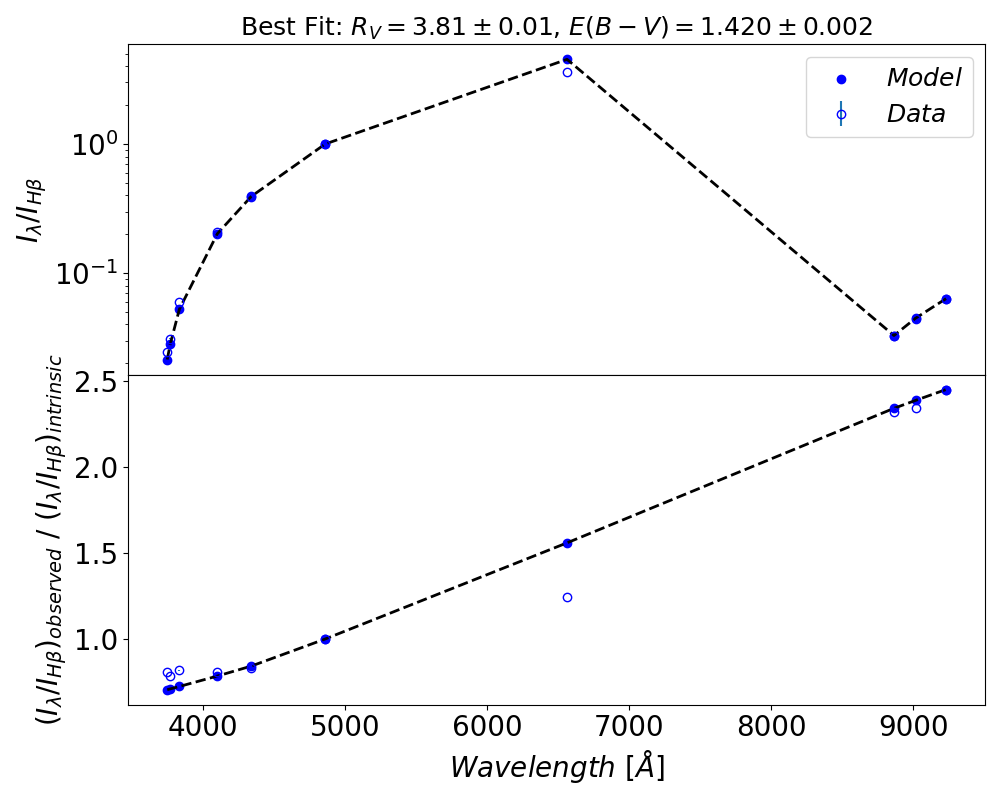

Rv_best, Rv_err, Ebv_best, Ebv_err 3.813504033536499 0.007813886018638265 1.4200729356941701 0.002363131496314124


In [14]:
# new script on may 28th, 25, to create a new plot with (I/I_hb)obs/(I/I_hb)theo


# Function to compute theoretical H line ratios using PyNeb

def pyneb_ratio(Te, ne):
    atom = pn.RecAtom('H', 1)
    wavelengths = [3750.15, 3770.63, 3835.38, 4101.74, 4340.463, 4861.32, 6563.0, 8862.78, 9014.91, 9229.01]  # Hk, He, Hd, Hg, Hb, Ha, P9
    emis = np.array([atom.getEmissivity(tem=Te, den=ne, wave=wl) for wl in wavelengths])
    ratios = emis / emis[5]  # Normalize to Hb
    return np.array(wavelengths), ratios


# Extinction curve calculator

def extinction_curve(model, wavelength, Rv, Ebv):
    extinction_model = model(Rv)
    k_lambda = extinction_model(wavelength * u.AA)
    return k_lambda * Ebv


# Load data

with fits.open(spectrum_flux) as hdu:
    data = hdu[1].data

# Line keys and labels
line_keys = ['HI3750', 'HI3771', 'HI3835', 'HI4102', 'Hgm4340', 'Hb4861', 'Ha6563', 'HI8863', 'HI9015', 'HI9229']
line_labels = ['Hk','Hi', 'He', 'Hd', 'Hg', 'Hb', 'Ha', 'P11', 'P10', 'P9']


# Observed line fluxes and errors

wave_array = np.array([data[f'{key}_wave0'][0] for key in line_keys])
flux_array = np.array([data[f'{key}_flux0'][0] for key in line_keys])
flux_err_array = np.array([data[f'{key}_flux0_err'][0] for key in line_keys])

# Normalize all to Hβ
Hb_flux = flux_array[5]
Hb_err = flux_err_array[5]
obs_ratios = flux_array / Hb_flux
err_obs_ratios = obs_ratios * np.sqrt((flux_err_array / flux_array)**2 + (Hb_err / Hb_flux)**2)
obs_ratios[5] = 1.0
err_obs_ratios[5] = 0


# Theoretical ratios from PyNeb

_, theo_ratios = pyneb_ratio(Te=8300, ne=120) # 8040K and 480 from ellipse and 8000KK and 120 for intgrated spectrum


# Fit using only Hd, Hg, P11, P9 (indices 0, 2, 3, 6, 8)

fit_indices = [3, 4, 7, 9]
wave_fit = wave_array[fit_indices]
obs_fit = obs_ratios[fit_indices]
err_fit = err_obs_ratios[fit_indices]
theo_fit = theo_ratios[fit_indices]


# Model function for curve_fit

def model_function(wavelength, Rv, Ebv):
    extinction_factors = 10**(-0.4 * (extinction_curve(F99, wavelength, Rv, Ebv) -
                                      extinction_curve(F99, 4861.32, Rv, Ebv)))
    return theo_fit * extinction_factors


# Fit routine

def fit_ebv_and_plot():
    p0 = [3.1, 0.3]  # Initial guess
    bounds = ([2, 0.0], [6, 3.0])
    popt, pcov = curve_fit(model_function, wave_fit, obs_fit, sigma=err_fit,
                           p0=p0, bounds=bounds, absolute_sigma=True)
    Rv_best, Ebv_best = popt
    Rv_err, Ebv_err = np.sqrt(np.diag(pcov))

    # Recompute modeled values for all lines (for plotting)
    extinction_factors_full = 10**(-0.4 * (extinction_curve(F99, wave_array, Rv_best, Ebv_best) -
                                           extinction_curve(F99, 4861.32, Rv_best, Ebv_best)))
    modeled_full = theo_ratios * extinction_factors_full

    # Plot
    plt.errorbar(wave_array, obs_ratios/theo_ratios, yerr=err_obs_ratios,
                 fmt='o', markerfacecolor='none', markeredgecolor='b',
                 label=r'$Observed$')
    plt.scatter(wave_array, modeled_full/theo_ratios, color='b', label=r'$Modeled$')
    plt.plot(wave_array, modeled_full/theo_ratios, linestyle='--', color='black', linewidth=2)
    
    lines = [r'$H\kappa$', r'$H\eta$', r'$H\delta$', r'$H\gamma$', r'$H\beta$', r'$H\alpha$', 'P 11\n', '\n P 10', '\nP 9']
    
    for x, y, label in zip(wave_array, obs_ratios/theo_ratios, lines):
        plt.text(x, y * 0.92, label, color='r', fontsize=15, ha='center')

    obs =r'$(I_{\lambda}/I_{H\beta})$'
    theo = r'$(I_{\lambda}/I_{H\beta})_{theo}$'

    # Labels and title
    plt.xlabel(r'$Wavelength [\AA$]', fontsize=19)
    plt.ylabel(f'{obs}/{theo}', fontsize=19)
    plt.yscale('log')
    plt.title(fr'Best Fit: $R_V = {Rv_best:.3f} \pm {Rv_err:.3f}$, $E(B-V) = {Ebv_best:.3f} \pm {Ebv_err:.4f}$', fontsize=17)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

    plt.legend(fontsize=14)
    plt.tight_layout()

    # Save plot
    #plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/testing_Ebv_fits/integrated_spectrum_obs_model_vs_theoretical_fit_Rv_{Rv_best:.3f}_Ebv_{Ebv_best:.3f}_aug5.png', dpi=100) #elliptical_
    #plt.close()
    
    #=================================================== Plot goes inn thee paper =====================================================
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, height_ratios=[1, 1])

    # Observed vs Modeled
    ax1.errorbar(wave_array, obs_ratios, yerr=err_obs_ratios,
                 fmt='o', markerfacecolor='none', markeredgecolor='b',
                 label=r'$Data$')
    ax1.scatter(wave_array, modeled_full, color='b', label=r'$Model$')
    ax1.plot(wave_array, modeled_full, linestyle='--', color='black', linewidth=2)

    lines = [r'$H\kappa$', r'$H\eta$', r'$H\delta$', r'$H\gamma$', r'$H\beta$', r'$H\alpha$', 'P11\n\n ', '\n\n P10', '\n\nP9']
    #for x, y, label in zip(wave_array, obs_ratios*0.8, lines):
    #    ax1.text(x, y * 1.3, label, color='r', alpha =1, fontsize=20, ha='center')

    ax1.set_ylabel(r'$I_{\lambda}/I_{H\beta}$', fontsize=20)
    ax1.set_yscale('log')
    ax1.set_title(fr'Best Fit: $R_V = {Rv_best:.2f} \pm {Rv_err:.2f}$, '
                  fr'$E(B-V) = {Ebv_best:.3f} \pm {Ebv_err:.3f}$', fontsize=18)
    ax1.legend(fontsize=18)
    ax1.tick_params(labelsize=20)

    # Observed / Modeled (residuals)
    residuals = obs_ratios / theo_ratios
    model_residuals = modeled_full/theo_ratios
    err_residuals = err_obs_ratios 

    ax2.errorbar(wave_array, residuals, yerr=err_residuals,
                 fmt='o', markerfacecolor='none', markeredgecolor='b',
                 label=r'$Data$')
    ax2.scatter(wave_array, model_residuals, color='b', label=r'$Model$')
    ax2.plot(wave_array, model_residuals, color='k', linestyle='--', linewidth=2)

    #for x, y, label in zip(wave_array, residuals*1.1, lines):
    #    ax2.text(x, y, label, color='r', alpha = 1, fontsize=17, ha='center')

    obs = r'$(I_{\lambda}/I_{H\beta})_{observed}$'
    theo = r'$(I_{\lambda}/I_{H\beta})_{intrinsic}$'
    ax2.set_xlabel(r'$Wavelength\ [\AA]$', fontsize=20)
    ax2.set_ylabel(fr'{obs} / {theo}', fontsize=20)
    #ax2.set_yscale('log')
    ax2.tick_params(labelsize=20)
    #ax2.legend(fontsize=14)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0)  # Less vertical gap
    
    # Save plot
    #out_path = data_dir+f'{spectrum_name}_obs_model_rati_two_plots_fit_Rv_{Rv_best:.3f}_Ebv_{Ebv_best:.3f}_1.1.2dev0.png'  #elliptical_
    #plt.savefig(out_path, dpi=100)
    plt.show()

    print('Rv_best, Rv_err, Ebv_best, Ebv_err', Rv_best, Rv_err, Ebv_best, Ebv_err)
    return Rv_best, Rv_err, Ebv_best, Ebv_err


# Run fit and plot
Rv, Rv_err, Ebv, Ebv_err = fit_ebv_and_plot()


In [9]:
plt.close('all')

In [11]:
# Rv, Rv_err, Ebv, Ebv_err

def dust_corr(filename, lines_to_correct):
    
    with fits.open(filename) as hdul:
        table = hdul[1].data

        print(table)

        print('Rv, Rv_err, Ebv, Ebv_err:', Rv, Rv_err, Ebv, Ebv_err)
        extinction_model = F99(Rv) 
        

        # Lists to store new columns 
        new_columns = []

        # Copy and rename observed columns
        for key in table.columns.names:
            if 'flux' in key :
                obs_col_name = f"obs_{key}"
                new_columns.append(fits.Column(name=obs_col_name, format='D', array=table[key]))

        # Loop over lines to correct
        offsets = [0, 14.19, 23.38, 31.69, 34.65, 41.97, 43.68, 51.01, 54.47, 69.07]
        offsets_oii = [0, 2.95, 10.27, 11.98, 19.31, 22.77, 37.37]

        for line_label in lines_to_correct:
            for i in range(10):  # Correcting up to 10 components (0 to 10)

                flux_column = f'{line_label}_flux{i}'
                flux_err_column = f'{line_label}_flux{i}_err'
                wave_column = f'{line_label}_wave{i}'

                if flux_column in table.columns.names:

                    if line_label == 'NII_OII':
                        line_wavelength = 4607.16 + offsets[i]  # Using the above provided offsets
                    
                    elif line_label == '[OIII]4363':
                        line_wavelength = 4363.2 

                    else:
                        line_wavelength = table[wave_column][0]  # Using the observed wavelength from the table


                    #f_line = extinction_model((line_wavelength / 1e4) * u.micron)
                    #A_line = 1.37 * f_line         #best_Ebv           
                    #A_line_err = 0.0006 * f_line    #err_Ebv
                        
                    x_value = 1 / (line_wavelength / 1e4)  # Convert to microns and then take 1/λ

                    if 0.3 <= x_value <= 10.0:
                        f_line = extinction_model((line_wavelength / 1e4) * u.micron)
                        A_line =  Ebv* f_line  
                        A_line_err = Ebv_err * f_line  

                    else:
                        print(f"Skipping {line_wavelength} Å: outside valid range for F99")
                        continue


                    observed_flux = table[flux_column]
                    observed_flux_err = table[flux_err_column]

                    ########################################### calculating Av #########################################
                    k_lambda = extinction_model(line_wavelength * u.AA)
                    Av = A_line * (Rv/k_lambda)

                    print('line_label, A_line, Av:', line_label, A_line, Av)

                    ####################################################################################################
                    
                    intrinsic_flux = observed_flux * 10 ** (0.4 * A_line)
                    intrinsic_flux_err = intrinsic_flux * np.sqrt((observed_flux_err / observed_flux) ** 2 + (0.4 * A_line_err * np.log(10)) ** 2)
                    
                    # Store corrected fluxes and errors
                    int_flux_col_name = f"int_{flux_column}"
                    int_flux_err_col_name = f"int_{flux_err_column}"
                    
                    new_columns.append(fits.Column(name=int_flux_col_name, format='D', array=intrinsic_flux))
                    new_columns.append(fits.Column(name=int_flux_err_col_name, format='D', array=intrinsic_flux_err))
                    
    print('A_line:', np.nanmean(A_line), 'A_line_err:', np.nanmean(A_line_err) )

    # Add E(B-V) and its error
    ebv_array = np.full(len(table), Ebv) 
    ebv_err_array = np.full(len(table), Ebv_err)
    new_columns.append(fits.Column(name='E_B_V', format='D', array=ebv_array))
    new_columns.append(fits.Column(name='E_B_V_err', format='D', array=ebv_err_array))


    # Write to a new FITS file
    cols = fits.ColDefs(new_columns)
    hdu = fits.BinTableHDU.from_columns(cols)


    output_filename = spectrum_obs_corr_flux
    hdu.writeto(output_filename, overwrite=True)
    print(f"File saved: {output_filename}")

# Variable radial bins
filename = spectrum_flux

lines_to_correct = {
    
    'HI3750': [3750.15],
    'HI3771': [3770.63],
    'HI3835': [3835.38],
    'HI4102': [4101.74],
    'HI8863': [8862.78],
    'HI9015': [9014.91],
    'HI9229': [9229.01],
    'Ha6563': [6562.8],
    'Hb4861': [4861.32],
    'Hgm4340': [4340.463] ,
    'NII_OII' : [4607.16] ,
    '[SII]4069': [4068.6] ,
    '[SII]6717': [6716.44],
    '[SII]6731': [6730.82],
    '[NII]5755': [5754.64],
    '[NII]6548': [6548.04],
    '[NII]6584': [6583.46],
    '[OIII]4363': [4363.2],
    '[OIII]4959': [4958.91],
    '[OIII]5007': [5006.84],
    '[OII]3726': [3726.03],
    '[OII]7320': [7319.99],
    '[OII]7330': [7330],
    '[ClIII]5517':[5517.71],
    '[ClIII]5537':[5537.88],
    'CII4267':[4267.09],
    'HI9229': [9229.01],
    '[SIII]6312': [6312.1],
    '[SIII]9069': [9068.6],
    '[SIII]9531': [9530.6],
    #'OII4638': [4638.86]
    
      }

dust_corr(filename, lines_to_correct)

[(5.88691798e-17, 1.69810533e-19, 3750.49951783, 0.00224608, 0.75644267, 5.53899637e-18, 1.9208517e-20, 7.44355046e-17, 1.61321494e-19, 3771.05546921, 0.00164475, 0.71777681, 6.06175068e-18, 1.71207354e-20, 1.41937297e-16, 1.58350988e-19, 3835.99701441, 0.00084459, 0.70651922, 6.4250396e-18, 1.5902197e-20, 4.98535436e-16, 1.51490178e-19, 4102.72685614, 0.00021677, 0.65606821, 6.38807553e-18, 1.49783561e-20, 7.79895982e-17, 1.6746788e-19, 8863.22245773, 0.0019073, 0.85177453, 9.32474662e-18, 1.60265346e-20, 1.05190103e-16, 1.65414838e-19, 9015.32706672, 0.00136535, 0.83207705, 9.03393823e-18, 1.60232363e-20, 1.51653249e-16, 1.66748131e-19, 9229.52792558, 0.00102439, 0.87549627, 9.63741343e-18, 1.3951784e-20, 8.64506465e-15, 1.80691706e-19, 6563.1277876, 1.49508771e-05, 0.64057027, 7.70619662e-18, 1.31903742e-20, 2.39420989e-15, 1.63228758e-19, 4861.4806532, 5.22926317e-05, 0.67383493, 5.80937902e-18, 8.82778683e-21, 9.26728465e-16, 1.49750216e-19, 4341.37773482, 0.00011722, 0.64842079, 

In [349]:
# Run Pyneb to calculate nebular diagnostics

In [13]:
with fits.open(spectrum_obs_corr_flux) as hdu:
    table = hdu[1].data
    header = hdu[1].header


# Load PyNeb packages
atoms = pn.getAtomDict()
O3 = pn.Atom('O', 3)
S2 = pn.Atom('S', 2)
N2 = pn.Atom('N', 2)
O2 = pn.Atom('O', 2)
S3 = pn.Atom('S', 3)
Cl3 = pn.Atom('Cl', 3)


diagnostics_dict = {

    'neO2': [], 'neS2': [],  'neCl3': [],'neO2err': [], 'neS2err': [], 'neCl3err': [], 'neS2syserr': [], 
    
    'TeO2': [], 'TeN2': [],  'TeS2': [],   'TeO3': [],  'TeS3': [], 
    'TeO2err': [], 'TeN2err': [], 'TeS2err': [], 'TeO3err': [], 'TeS3err': [], 'TeN2syserr': [], 'TeO3syserr': [],

    'Opp_cel': [], 'Opp_cel_err': [], 'Opp_cel_syserr': [], 'Op_cel': [], 'Op_cel_err': [], 'Op_cel_syserr': [], 'Spp_cel': [], 'Spp_cel_err': [], 
    'Sp_cel': [], 'Sp_cel_err': [], 'Np_cel': [], 'Np_cel_err': [], 'Opp_RL': [], 'Opp_RL_err': [], 'Opp_RL_syserr': [], 
    'Opp_RL_teorl':[],  'Opp_RL_teorl_err':[]
    
    }    #'Opp_RL_teorl':[],  'Opp_RL_teorl_err':[], 'TeO3RL': [], 'TeO3RLerr': [], 


Te = 8300
niter = 50

#np.random.seed(2000)

#################################################################################################################
#Add systematic error of 5% to all the relative line flux
def flux_sys_err(flux, wave):
   
    frac_err = 0.05 * (wave - 3600) / (9800 - 3600) 
    frac_err = np.clip(frac_err, 0, 0.05)
    return flux * frac_err


################################ Function to perform Monte Carlo simulation #####################################
def mc_sim_sys(flux, wave):

    sys_err = flux_sys_err(flux, wave)
    flux_err = np.sqrt(sys_err**2)
    return np.random.normal(flux, flux_err)


################################# Function to perform Monte Carlo simulation #######################################
def mc_sim(flux, flux_err):
    return np.random.normal(flux, flux_err)


#======================================================= First iteration ==================================================================

######################### Monte Carlo simulation for neO2 ########################
NO2 = np.zeros((niter))
for i in range(niter):

    f3726 = mc_sim(table['int_[OII]3726_flux0'], table['int_[OII]3726_flux0_err'])
    f3729 = mc_sim(table['int_[OII]3726_flux1'], table['int_[OII]3726_flux1_err'])
    NO2[i] = O2.getTemDen(f3726/ f3729, tem=Te, wave1=3726, wave2=3729)

neO2 = np.nanmean(NO2, axis = 0)
neO2err = np.nanstd(NO2, axis = 0)

print()
print('neO2', neO2)
print('neO2err', neO2err)

#=================================== test sep2, 25 on sys err ===================================#
NO2new = np.zeros((niter))
for i in range(niter):

    f3726 = mc_sim_sys(table['int_[OII]3726_flux0'], 3726)
    f3729 = mc_sim_sys(table['int_[OII]3726_flux1'], 3729)
    NO2new[i] = O2.getTemDen(f3726/ f3729, tem=Te, wave1=3726, wave2=3729)

neO2 = np.nanmean(NO2new, axis = 0)
neO2err = np.nanstd(NO2new, axis = 0)

print()
print('neO2new', neO2)
print('neO2errnew', neO2err)


######################### Monte Carlo simulation for neS2 ########################
NS2 = np.zeros((niter))
for i in range(niter):

    f6717 = mc_sim(table['int_[SII]6717_flux0'], table['int_[SII]6717_flux0_err'])
    f6731 = mc_sim(table['int_[SII]6731_flux0'], table['int_[SII]6731_flux0_err'])
    NS2[i] = S2.getTemDen(f6717/ f6731, tem=Te, wave1=6717, wave2=6731)

neS2 = np.nanmean(NS2, axis = 0)
neS2err = np.nanstd(NS2, axis = 0)

print('neS2', neS2)
print('neS2err', neS2err)

print()

########################################### MC on computed density to be propagated to other quantities ##########################
neS2_mc = mc_sim(neS2, neS2err)

######################### Monte Carlo simulation for TeN2 ########################
TN2 = np.zeros((niter))
for i in range(niter):
    f5755 = mc_sim(table['int_[NII]5755_flux0'], table['int_[NII]5755_flux0_err'])
    f6584 = mc_sim(3.05*table['int_[NII]6548_flux0'], table['int_[NII]6584_flux0_err'])
    f6548 = mc_sim(table['int_[NII]6548_flux0'], table['int_[NII]6548_flux0_err'])
    TN2[i] = N2.getTemDen(f5755 / (f6548+f6584), den=neS2_mc, to_eval = 'L(5755)/(L(6584)+L(6548))')

TeN2 = np.nanmean(TN2, axis = 0)
TeN2err = np.nanstd(TN2, axis = 0)

print('TeN2', TeN2)
print('TeN2err', TeN2err)
print()

TeN2_mc = mc_sim(TeN2, TeN2err)


#======================================================= second iteration ==================================================================

#######################################################  neO2 ######################################################
NO2 = np.zeros((niter))
for i in range(niter):

    f3726 = mc_sim(table['int_[OII]3726_flux0'], table['int_[OII]3726_flux0_err'])
    f3729 = mc_sim(table['int_[OII]3726_flux1'], table['int_[OII]3726_flux1_err'])
    NO2[i] = O2.getTemDen(f3726/ f3729, tem=TeN2_mc, wave1=3726, wave2=3729)

neO2 = np.nanmean(NO2, axis = 0)
neO2err = np.nanstd(NO2, axis = 0)

print()
print('2nd iter neO2', neO2)
print('2nd iter neO2err', neO2err)

############################################################## neS2  ###################################################
NS2 = np.zeros((niter))
for i in range(niter):

    f6717 = mc_sim(table['int_[SII]6717_flux0'], table['int_[SII]6717_flux0_err'])
    f6731 = mc_sim(table['int_[SII]6731_flux0'], table['int_[SII]6731_flux0_err'])
    NS2[i] = S2.getTemDen(f6717/ f6731, tem=TeN2_mc, wave1=6717, wave2=6731)

neS2 = np.nanmean(NS2, axis = 0)
neS2err = np.nanstd(NS2, axis = 0)


print('2nd iter neS2', neS2)
print('2nd iter neS2err', neS2err)

print()
neS2_mc = mc_sim(neS2, neS2err)

######################### Monte Carlo simulation for TeN2 ########################
TN2 = np.zeros((niter))
for i in range(niter):
    f5755 = mc_sim(table['int_[NII]5755_flux0'], table['int_[NII]5755_flux0_err'])
    f6584 = mc_sim(3.05*table['int_[NII]6548_flux0'], table['int_[NII]6584_flux0_err'])
    f6548 = mc_sim(table['int_[NII]6548_flux0'], table['int_[NII]6548_flux0_err'])
    TN2[i] = N2.getTemDen(f5755 / (f6548+f6584), den=neS2_mc, to_eval = 'L(5755)/(L(6584)+L(6548))')

TeN2 = np.nanmean(TN2, axis = 0)
TeN2err = np.nanstd(TN2, axis = 0)

print('2nd iter TeN2', TeN2)
print('2nd iter TeN2err', TeN2err)
print()

TeN2_mc = mc_sim(TeN2, TeN2err)



#======================================================= third iteration ==================================================================

#######################################################  neO2 ######################################################
NO2 = np.zeros((niter))
for i in range(niter):

    f3726 = mc_sim(table['int_[OII]3726_flux0'], table['int_[OII]3726_flux0_err'])
    f3729 = mc_sim(table['int_[OII]3726_flux1'], table['int_[OII]3726_flux1_err'])
    NO2[i] = O2.getTemDen(f3726/ f3729, tem=TeN2_mc, wave1=3726, wave2=3729)

neO2 = np.nanmean(NO2, axis = 0)
neO2err = np.nanstd(NO2, axis = 0)
diagnostics_dict['neO2'] = neO2
diagnostics_dict['neO2err'] = neO2err
print()
print('3rd iter neO2', neO2)
print('3rd iter neO2err', neO2err)

############################################################## neS2  ###################################################
NS2 = np.zeros((niter))
for i in range(niter):

    f6717 = mc_sim(table['int_[SII]6717_flux0'], table['int_[SII]6717_flux0_err'])
    f6731 = mc_sim(table['int_[SII]6731_flux0'], table['int_[SII]6731_flux0_err'])
    NS2[i] = S2.getTemDen(f6717/ f6731, tem=TeN2_mc, wave1=6717, wave2=6731)

neS2 = np.nanmean(NS2, axis = 0)
neS2err = np.nanstd(NS2, axis = 0)
diagnostics_dict['neS2'] = neS2
diagnostics_dict['neS2err'] = neS2err

print('3rd iter neS2', neS2)
print('3rd iter neS2err', neS2err)

print()
neS2_mc = mc_sim(neS2, neS2err)

#========================= test sep2, 25 on sys err ===================================#
NS2new = np.zeros((niter))
for i in range(niter):

    f6717 = mc_sim_sys(table['int_[SII]6717_flux0'], 6717)
    f6731 = mc_sim_sys(table['int_[SII]6731_flux0'], 6731)
    NS2new[i] = S2.getTemDen(f6717/ f6731, tem=TeN2_mc, wave1=6717, wave2=6731)

neS2new = np.nanmean(NS2new, axis = 0)
neS2errnew = np.nanstd(NS2new, axis = 0)

diagnostics_dict['neS2syserr'] = neS2errnew

print('neS2new', neS2new)
print('neS2errnew', neS2errnew)



######################### Monte Carlo simulation for TeN2 ########################
TN2 = np.zeros((niter))
for i in range(niter):
    f5755 = mc_sim(table['int_[NII]5755_flux0'], table['int_[NII]5755_flux0_err'])
    f6584 = mc_sim(3.05*table['int_[NII]6548_flux0'], table['int_[NII]6584_flux0_err'])
    f6548 = mc_sim(table['int_[NII]6548_flux0'], table['int_[NII]6548_flux0_err'])
    TN2[i] = N2.getTemDen(f5755 / (f6548+f6584), den=neS2_mc, to_eval = 'L(5755)/(L(6584)+L(6548))')

TeN2 = np.nanmean(TN2, axis = 0)
TeN2err = np.nanstd(TN2, axis = 0)
diagnostics_dict['TeN2'] = TeN2
diagnostics_dict['TeN2err'] = TeN2err

print('2nd iter TeN2', TeN2)
print('2nd iter TeN2err', TeN2err)
print()

#======================================= test sep2 25 on sys err ===================================#
TN2new = np.zeros((niter))
for i in range(niter):
    f5755 = mc_sim_sys(table['int_[NII]5755_flux0'], 5755)
    f6584 = mc_sim_sys(3.05*table['int_[NII]6548_flux0'], 6584)
    f6548 = mc_sim_sys(table['int_[NII]6548_flux0'], 6548) 
    TN2new[i] = N2.getTemDen(f5755 / (f6548+f6584), den=neS2_mc, to_eval = 'L(5755)/(L(6584)+L(6548))')

TeN2new = np.nanmean(TN2new, axis = 0)
TeN2errnew = np.nanstd(TN2new, axis = 0)
diagnostics_dict['TeN2syserr'] = TeN2errnew

print('TeN2 new',TeN2new)
print('TeN2err new',TeN2errnew)

######################### Monte Carlo simulation for TeS3 ########################
TS3 = np.zeros((niter))
for i in range(niter):

    f6312 = mc_sim(table['int_[SIII]6312_flux0'], table['int_[SIII]6312_flux0_err'])
    f9531 = mc_sim(table['int_[SIII]9531_flux0'], table['int_[SIII]9531_flux0_err'])
    f9069 = mc_sim(table['int_[SIII]9069_flux0'], table['int_[SIII]9069_flux0_err'])

    TS3[i] = S3.getTemDen(f6312 / (f9069+f9531), den=neS2_mc, to_eval = 'L(6312)/(L(9069)+L(9531))')

TeS3 = np.nanmean(TS3, axis = 0)
TeS3err = np.nanstd(TS3, axis = 0)
diagnostics_dict['TeS3'] = TeS3
diagnostics_dict['TeS3err'] = TeS3err

print('TeS3', TeS3)
print('TeS3err', TeS3err)

######################### Monte Carlo simulation for TeO2 ########################
TO2 = np.zeros((niter))
for i in range(niter):

    f3726 = mc_sim(table['int_[OII]3726_flux0'], table['int_[OII]3726_flux0_err'])
    f3729 = mc_sim(table['int_[OII]3726_flux1'], table['int_[OII]3726_flux1_err'])
    f7320 = mc_sim(table['int_[OII]7320_flux0'], table['int_[OII]7320_flux0_err'])
    f7330 = mc_sim(table['int_[OII]7330_flux0'], table['int_[OII]7330_flux0_err'])
    TO2[i] = O2.getTemDen((f7320 + f7330)/(f3726 + f3729) , den=neS2_mc, to_eval='(L(7320)+L(7330))/(L(3726)+L(3729))')
    p  = np.nanmean(O2.getTemDen((f7330 )/(f3726 + f3729) , den=neS2_mc, to_eval='(L(7320))/(L(3726)+L(3729))'))
    perr = np.nanstd(O2.getTemDen((f7330 )/(f3726 + f3729) , den=neS2_mc, to_eval='(L(7320))/(L(3726)+L(3729))'))

TeO2 = np.nanmean(TO2, axis = 0)
TeO2err = np.nanstd(TO2, axis = 0)
diagnostics_dict['TeO2'] = p
diagnostics_dict['TeO2err'] = perr

print('TeO2', TeO2, p)
print('TeO2err', TeO2err, perr)


######################### Monte Carlo simulation for TeO3 ########################
TO3 = np.zeros((niter))
for i in range(niter):

    f4363 = mc_sim(table['int_[OIII]4363_flux1'], table['int_[OIII]4363_flux1_err'])
    f5007 = mc_sim(table['int_[OIII]5007_flux0'], table['int_[OIII]5007_flux0_err'])
    f4959 = mc_sim(table['int_[OIII]4959_flux0'], table['int_[OIII]4959_flux0_err'])

    TO3[i] = O3.getTemDen(f4363 / (f4959+f5007), den=neS2_mc, to_eval = 'L(4363)/(L(4959)+L(5007))')
    
TeO3 = np.nanmean(TO3, axis = 0)
TeO3err = np.nanstd(TO3, axis = 0)
diagnostics_dict['TeO3'] = TeO3
diagnostics_dict['TeO3err'] = TeO3err

TeO3_mc = mc_sim(TeO3, TeO3err)


print('TeO3', TeO3)
print('TeO3err', TeO3err)

print()
# ==================================================  new ttest sep 2, 25 ==============================
TO3new = np.zeros((niter))
for i in range(niter):

    f4363 = mc_sim_sys(table['int_[OIII]4363_flux1'], 4363)
    f5007 = mc_sim_sys(table['int_[OIII]5007_flux0'], 5007)
    f4959 = mc_sim_sys(table['int_[OIII]4959_flux0'], 4959)

    TO3new[i] = O3.getTemDen(f4363 / (f4959+f5007), den=neS2_mc, to_eval = 'L(4363)/(L(4959)+L(5007))')
    
TeO3new = np.nanmean(TO3new, axis = 0)
TeO3errnew = np.nanstd(TO3new, axis = 0)

diagnostics_dict['TeO3syserr'] = TeO3errnew
print('TeO3new', TeO3new)
print('TeO3errnew', TeO3errnew)

print()


########################################### MC on computed density to be propagated to other quantities ##########################


NCl3 = np.zeros((niter))
for i in range(niter):

    f5517 = mc_sim(table['int_[ClIII]5517_flux0'], table['int_[ClIII]5517_flux0_err'])
    f5537 = mc_sim(table['int_[ClIII]5537_flux0'], table['int_[ClIII]5537_flux0_err'])
    NCl3[i] = Cl3.getTemDen(f5517 / f5537, tem=TeO3_mc, wave1=5517, wave2=5537)

neCl3 = np.nanmean(NCl3, axis = 0)
neCl3err = np.nanstd(NCl3, axis = 0)
diagnostics_dict['neCl3'] = neCl3
diagnostics_dict['neCl3err'] = neCl3err

print('neCl3', neCl3)
print('neCl3err', neCl3err)

print()

######################### Monte Carlo simulation for TeS2 ########################

TS2 = np.zeros((niter))
for i in range(niter):
    f4069 = mc_sim(table['int_[SII]4069_flux0'], table['int_[SII]4069_flux0_err'])
    f4077 = mc_sim(table['int_[SII]4069_flux1'], table['int_[SII]4069_flux1_err'])
    f6717 = mc_sim(table['int_[SII]6717_flux0'], table['int_[SII]6717_flux0_err'])
    f6731 = mc_sim(table['int_[SII]6731_flux0'], table['int_[SII]6731_flux0_err'])
    TS2[i] = S2.getTemDen((f4069 + f4077) / (f6717 + f6731), den=neS2_mc, to_eval = '(L(4069)+L(4077))/(L(6717)+L(6731))')

TeS2 = np.nanmean(TS2, axis = 0)
TeS2err = np.nanstd(TS2, axis = 0)
diagnostics_dict['TeS2'] = TeS2
diagnostics_dict['TeS2err'] = TeS2err

print('TeS2', TeS2)
print('TeS2err', TeS2err)

print()


TeO2_mc = mc_sim(p, perr)
TeS2_mc = mc_sim(TeS2, TeS2err)
TeS3_mc = mc_sim(TeS3, TeS3err)

#=========================================================== TeORL ===========================================================#
with fits.open(spectrum_teorl) as hdu: #
    int_teorl = hdu[1].data

te_obs_int =    np.array(int_teorl['Te_obs'])
te_obs_err_int =np.array(int_teorl['Te_obs_err'])

diagnostics_dict['TeO3RL'] = te_obs_int
diagnostics_dict['TeO3RLerr'] = te_obs_err_int

print('TeO3RL', np.nanmean(te_obs_int))
print('TeO3RLerr', np.nanmean(te_obs_err_int))
print()

#=========================================================== TeORL ===========================================================#


# print(te_obs_int, neS2)
############################################################## Calculating ionic abunadnces ################################################


########################################### MC on computed density to be propagated to other quantities ##########################

# O+/H+ ionic abundance
Op_cel=np.zeros((niter))
for i in range (niter):

    f3726 = mc_sim(table['int_[OII]3726_flux0'], table['int_[OII]3726_flux0_err'])
    f3729 = mc_sim(table['int_[OII]3726_flux1'], table['int_[OII]3726_flux1_err'])
    f4861 = mc_sim(table['int_Hb4861_flux0'], table['int_Hb4861_flux0_err'])

    Int_Oph = np.divide((f3726+f3726),f4861)

    Op_cel[i]=12+np.log10(O2.getIonAbundance(int_ratio=100*(Int_Oph), tem= TeN2_mc, den= neS2_mc, to_eval='L(3726)+L(3729)'))

diagnostics_dict['Op_cel']=np.nanmean(Op_cel, axis = 0)
diagnostics_dict['Op_cel_err']= np.nanstd(Op_cel, axis = 0)

print('mean Op_cel', np.nanmean(Op_cel, axis = 0))
print('mean Op_cel_err', np.nanstd(Op_cel, axis = 0))
print()

#=================================== new after adding sys error ==============================================

# O+/H+ ionic abundance
Op_celnew=np.zeros((niter))
for i in range (niter):

    f3726 = mc_sim_sys(table['int_[OII]3726_flux0'], 3726)
    f3729 = mc_sim_sys(table['int_[OII]3726_flux1'], 3729)
    f4861 = mc_sim_sys(table['int_Hb4861_flux0'], 4861)

    Int_Oph = np.divide((f3726+f3726),f4861)

    Op_celnew[i]=12+np.log10(O2.getIonAbundance(int_ratio=100*(Int_Oph), tem= TeN2_mc, den= neS2_mc, to_eval='L(3726)+L(3729)'))

diagnostics_dict['Op_cel_syserr']= np.nanstd(Op_celnew, axis = 0)

print('mean Op_cel new', np.nanmean(Op_celnew, axis = 0))
print('mean Op_cel_err new', np.nanstd(Op_celnew, axis = 0))
print()


##################################### O++/H+ ionic abundance ##################################### 
Opp_cel=np.zeros((niter))
for i in range (niter):

    f5007 = mc_sim(table['int_[OIII]5007_flux0'], table['int_[OIII]5007_flux0_err'])
    f4959 = mc_sim(table['int_[OIII]4959_flux0'], table['int_[OIII]4959_flux0_err'])
    f4861 = mc_sim(table['int_Hb4861_flux0'], table['int_Hb4861_flux0_err'])

    Int_Opph = np.divide((f5007+f4959),f4861)
    Opp_cel[i]=12+np.log10(O3.getIonAbundance(int_ratio=100*(Int_Opph), tem= TeO3_mc, den= neS2_mc, to_eval='L(5007)+L(4959)'))

diagnostics_dict['Opp_cel']=np.nanmean(Opp_cel, axis = 0)
diagnostics_dict['Opp_cel_err']= (np.nanstd(Opp_cel, axis = 0))

print('mean Opp_cel', np.nanmean(Opp_cel, axis = 0))
print('mean Opp_cel_err', (np.nanstd(Opp_cel, axis = 0)))
print()

# ================================================== new after adding sys error ==============================================

Opp_celnew=np.zeros((niter))
for i in range (niter):

    f5007 = mc_sim_sys(table['int_[OIII]5007_flux0'], 5007)
    f4959 = mc_sim_sys(table['int_[OIII]4959_flux0'], 4959)
    f4861 = mc_sim_sys(table['int_Hb4861_flux0'], 4861)

    Int_Opph = np.divide((f5007+f4959), f4861)
    Opp_celnew[i]=12+np.log10(O3.getIonAbundance(int_ratio=100*(Int_Opph), tem= TeO3_mc, den= neS2_mc, to_eval='L(5007)+L(4959)'))

diagnostics_dict['Opp_cel_syserr']= np.nanstd(Opp_celnew, axis = 0)

print('mean Opp_cel new', np.nanmean(Opp_celnew, axis = 0))
print('mean Opp_cel_err new', (np.nanstd(Opp_celnew, axis = 0)))
print()



######################################  N+/H+ ionic abundance ##################################### 
Np_cel=np.zeros((niter))
for i in range (niter):
    f6584 = mc_sim(3.05*table['int_[NII]6548_flux0'], table['int_[NII]6584_flux0_err'])
    f6548 = mc_sim(table['int_[NII]6548_flux0'], table['int_[NII]6548_flux0_err'])
    f4861 = mc_sim(table['int_Hb4861_flux0'], table['int_Hb4861_flux0_err'])
    
    Int_Nph = np.divide((f6548+f6584),f4861)
    Np_cel[i]=12+np.log10(N2.getIonAbundance(int_ratio=100*(Int_Nph), tem= TeN2_mc, den= neS2_mc, to_eval='L(6584)+L(6548)'))

diagnostics_dict['Np_cel']=np.nanmean(Np_cel, axis = 0)
diagnostics_dict['Np_cel_err']= (np.nanstd(Np_cel, axis = 0))

print('mean Np_cel', np.nanmean(Np_cel, axis = 0))
print('mean Np_cel_err', (np.nanstd(Np_cel, axis = 0)))
print()


######################################  S+/H+ ionic abundance  ##################################### 
Sp_cel=np.zeros((niter))
for i in range (niter):

    f6717 = mc_sim(table['int_[SII]6717_flux0'], table['int_[SII]6717_flux0_err'])
    f6731 = mc_sim(table['int_[SII]6731_flux0'], table['int_[SII]6731_flux0_err'])
    
    f4861 = mc_sim(table['int_Hb4861_flux0'], table['int_Hb4861_flux0_err'])
    Int_Sph = np.divide((f6717+f6731),f4861)
    Sp_cel[i]=12+np.log10(S2.getIonAbundance(int_ratio=100*(Int_Sph), tem= TeN2_mc, den= neS2_mc, to_eval='L(6717)+L(6731)'))

diagnostics_dict['Sp_cel']=np.nanmean(Sp_cel, axis = 0)
diagnostics_dict['Sp_cel_err']= (np.nanstd(Sp_cel, axis = 0))

print('mean Sp_cel', np.nanmean(Sp_cel, axis = 0))
print('Sp_cel_err', (np.nanstd(Sp_cel, axis = 0)))

######################################  S++/H+ ionic abundance  ##################################### 
Spp_cel=np.zeros((niter))
for i in range (niter):
    
    f9069 = mc_sim(table['int_[SIII]9069_flux0'], table['int_[SIII]9069_flux0_err'])
    f9531 = mc_sim(table['int_[SIII]9531_flux0'], table['int_[SIII]9531_flux0_err'])
    f4861 = mc_sim(table['int_Hb4861_flux0'], table['int_Hb4861_flux0_err'])

    Int_Spph = np.divide((f9531+f9069),f4861)
    Spp_cel[i]=12+np.log10(S3.getIonAbundance(int_ratio=100*(Int_Spph), tem= TeS3_mc, den= neS2_mc, to_eval='L(9531)+L(9069)'))

diagnostics_dict['Spp_cel']=np.nanmean(Spp_cel, axis = 0)
diagnostics_dict['Spp_cel_err']= (np.nanstd(Spp_cel, axis = 0))

print('mean Spp_cel', np.nanmean(Spp_cel, axis = 0))
print('Spp_cel_err', (np.nanstd(Spp_cel, axis = 0)))

print()

##################################### O++/H+ RL abundance ##################################### 

O2r = pn.RecAtom('O', 2)

Opp_RL=np.zeros((niter))
for i in range (niter):

    f4638 = mc_sim(table['int_NII_OII_flux3'], table['int_NII_OII_flux3_err'])
    f4641 = mc_sim(table['int_NII_OII_flux4'], table['int_NII_OII_flux4_err'])
    f4649 = mc_sim(table['int_NII_OII_flux5'], table['int_NII_OII_flux5_err'])
    f4650 = mc_sim(table['int_NII_OII_flux6'], table['int_NII_OII_flux6_err'])
    f4662 = mc_sim(table['int_NII_OII_flux8'], table['int_NII_OII_flux8_err'])
    f4676 = mc_sim(table['int_NII_OII_flux9'], table['int_NII_OII_flux9_err'])       

    f4861 = mc_sim(table['int_Hb4861_flux0'], table['int_Hb4861_flux0_err'])
    
    Int_OII_v2 = np.divide((f4638+f4641+f4649+f4650+f4662+f4676), f4861)
    Opp_RL[i] =12+np.log10( O2r.getIonAbundance(int_ratio=Int_OII_v2*100, tem= TeO3_mc, den= neS2_mc, to_eval='L(4638.86)+L(4641.81)+L(4649.13)+L(4650.84)+L(4661.63)+L(4676.23)'))

diagnostics_dict['Opp_RL']=np.nanmean(Opp_RL, axis = 0)
diagnostics_dict['Opp_RL_err']= (np.nanstd(Opp_RL, axis = 0))

print()
print('mean Opp_RL', np.nanmean(Opp_RL, axis = 0))
print('mean Opp_RL_err', (np.nanstd(Opp_RL, axis = 0)))

# ================================================================== new after adding sys error =======================================

Opp_RLnew=np.zeros((niter))
for i in range (niter):

    f4638 = mc_sim_sys(table['int_NII_OII_flux3'], 4638)
    f4641 = mc_sim_sys(table['int_NII_OII_flux4'], 4641)
    f4649 = mc_sim_sys(table['int_NII_OII_flux5'], 4649)
    f4650 = mc_sim_sys(table['int_NII_OII_flux6'], 4650)
    f4662 = mc_sim_sys(table['int_NII_OII_flux8'], 4662)
    f4676 = mc_sim_sys(table['int_NII_OII_flux9'], 4676)       

    f4861 = mc_sim_sys(table['int_Hb4861_flux0'], 4861)
    
    Int_OII_v2 = np.divide((f4638+f4641+f4649+f4650+f4662+f4676), f4861)
    Opp_RLnew[i] =12+np.log10( O2r.getIonAbundance(int_ratio=Int_OII_v2*100, tem= TeO3_mc, den= neS2_mc, to_eval='L(4638.86)+L(4641.81)+L(4649.13)+L(4650.84)+L(4661.63)+L(4676.23)'))

diagnostics_dict['Opp_RL_syserr']= np.nanstd(Opp_RLnew, axis = 0)

print()
print('mean Opp_RL new', np.nanmean(Opp_RLnew, axis = 0))
print('mean Opp_RL_err new', (np.nanstd(Opp_RLnew, axis = 0)))

####################################### using TeORL #######################################################

Opp_RL_v1=np.zeros((niter))
for i in range (niter):

    f4638 = mc_sim(table['int_NII_OII_flux3'], table['int_NII_OII_flux3_err'])
    f4641 = mc_sim(table['int_NII_OII_flux4'], table['int_NII_OII_flux4_err'])
    f4649 = mc_sim(table['int_NII_OII_flux5'], table['int_NII_OII_flux5_err'])
    f4650 = mc_sim(table['int_NII_OII_flux6'], table['int_NII_OII_flux6_err'])
    f4662 = mc_sim(table['int_NII_OII_flux8'], table['int_NII_OII_flux8_err'])
    f4676 = mc_sim(table['int_NII_OII_flux9'], table['int_NII_OII_flux9_err'])       

    f4861 = mc_sim(table['int_Hb4861_flux0'], table['int_Hb4861_flux0_err'])
    
    Int_OII_v2 = np.divide((f4638+f4641+f4649+f4650+f4662+f4676), f4861)
    Opp_RL_v1[i] =12+np.log10( O2r.getIonAbundance(int_ratio=Int_OII_v2*100, tem= np.nanmean(te_obs_int), den= neS2, to_eval='L(4638.86)+L(4641.81)+L(4649.13)+L(4650.84)+L(4661.63)+L(4676.23)'))

print()
diagnostics_dict['Opp_RL_teorl']=np.nanmean(Opp_RL_v1, axis = 0)
diagnostics_dict['Opp_RL_teorl_err']= (np.nanstd(Opp_RL_v1, axis = 0))

print()
print('mean Opp_RL_teorl', np.nanmean(Opp_RL_v1, axis = 0))
print('mean Opp_RL_teorl_err', np.nanmean(np.nanstd(Opp_RL_v1, axis = 0)))
print()

# Convert dictionary to structured FITS columns
columns = []
for key, value in diagnostics_dict.items():
    col = fits.Column(name=key, array=np.array([value]), format='E')  # 'E' for single-precision float
    columns.append(col)

# Create a new FITS table and save
coldefs = fits.ColDefs(columns)
hdu = fits.BinTableHDU.from_columns(coldefs)

output_file = spectrum_diag

hdu.writeto(output_file, overwrite=True)

print(f"Diagnostics dictionary saved to {output_file}")



warng _ManageAtomicData: rec data not available for Al2
warng _ManageAtomicData: rec data not available for Ar2
warng _ManageAtomicData: rec data not available for Ar3
warng _ManageAtomicData: rec data not available for Ar4
warng _ManageAtomicData: rec data not available for Ar5
warng _ManageAtomicData: rec data not available for Ba2
warng _ManageAtomicData: rec data not available for Ba4
ERROR None: No data for this case B
ERROR None: No data for this case B
warng _ManageAtomicData: rec data not available for Ca5
warng _ManageAtomicData: rec data not available for Cl2
warng _ManageAtomicData: rec data not available for Cl3
warng _ManageAtomicData: rec data not available for Cl4
warng _ManageAtomicData: rec data not available for Fe3
warng _ManageAtomicData: rec data not available for K4
warng _ManageAtomicData: rec data not available for K5
warng _ManageAtomicData: rec data not available for Mg5
warng _ManageAtomicData: rec data not available for Mg7
ERROR None: No data for this case 

/var/folders/g4/svmgwvyj7c7_qv7_5yns8mzh0000gn/T/ipykernel_12237/1734963785.py:427: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Op_cel[i]=12+np.log10(O2.getIonAbundance(int_ratio=100*(Int_Oph), tem= TeN2_mc, den= neS2_mc, to_eval='L(3726)+L(3729)'))
/var/folders/g4/svmgwvyj7c7_qv7_5yns8mzh0000gn/T/ipykernel_12237/1734963785.py:448: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Op_celnew[i]=12+np.log10(O2.getIonAbundance(int_ratio=100*(Int_Oph), tem= TeN2_mc, den= neS2_mc, to_eval='L(3726)+L(3729)'))
/var/folders/g4/svmgwvyj7c7_qv7_5yns8mzh0000gn/T/ipykernel_12237/1734963785.py:466: DeprecationWarning: Conversion of an array with ndim > 

mean Op_cel 8.126163966175472
mean Op_cel_err 0.00020855780420844723

mean Op_cel new 8.124837621775232
mean Op_cel_err new 0.004017565753470152

mean Opp_cel 8.092464995987486
mean Opp_cel_err 0.00018801415385317436



/var/folders/g4/svmgwvyj7c7_qv7_5yns8mzh0000gn/T/ipykernel_12237/1734963785.py:485: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Opp_celnew[i]=12+np.log10(O3.getIonAbundance(int_ratio=100*(Int_Opph), tem= TeO3_mc, den= neS2_mc, to_eval='L(5007)+L(4959)'))
/var/folders/g4/svmgwvyj7c7_qv7_5yns8mzh0000gn/T/ipykernel_12237/1734963785.py:503: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Np_cel[i]=12+np.log10(N2.getIonAbundance(int_ratio=100*(Int_Nph), tem= TeN2_mc, den= neS2_mc, to_eval='L(6584)+L(6548)'))
/var/folders/g4/svmgwvyj7c7_qv7_5yns8mzh0000gn/T/ipykernel_12237/1734963785.py:522: DeprecationWarning: Conversion of an array with ndim 

mean Opp_cel new 8.093073576355714
mean Opp_cel_err new 0.0050100555181072474

mean Np_cel 7.493517503400431
mean Np_cel_err 0.00017001064618281354

mean Sp_cel 6.243544254796783
Sp_cel_err 0.00016512393282566736


/var/folders/g4/svmgwvyj7c7_qv7_5yns8mzh0000gn/T/ipykernel_12237/1734963785.py:539: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Spp_cel[i]=12+np.log10(S3.getIonAbundance(int_ratio=100*(Int_Spph), tem= TeS3_mc, den= neS2_mc, to_eval='L(9531)+L(9069)'))
/var/folders/g4/svmgwvyj7c7_qv7_5yns8mzh0000gn/T/ipykernel_12237/1734963785.py:566: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Opp_RL[i] =12+np.log10( O2r.getIonAbundance(int_ratio=Int_OII_v2*100, tem= TeO3_mc, den= neS2_mc, to_eval='L(4638.86)+L(4641.81)+L(4649.13)+L(4650.84)+L(4661.63)+L(4676.23)'))


mean Spp_cel 7.068709420840198
Spp_cel_err 0.00016277575137904678


mean Opp_RL 8.464416490342407
mean Opp_RL_err 0.01834733700336439


/var/folders/g4/svmgwvyj7c7_qv7_5yns8mzh0000gn/T/ipykernel_12237/1734963785.py:590: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Opp_RLnew[i] =12+np.log10( O2r.getIonAbundance(int_ratio=Int_OII_v2*100, tem= TeO3_mc, den= neS2_mc, to_eval='L(4638.86)+L(4641.81)+L(4649.13)+L(4650.84)+L(4661.63)+L(4676.23)'))



mean Opp_RL new 8.46274955487723
mean Opp_RL_err new 0.004541972941166816


ValueError: could not broadcast input array from shape (0,) into shape (1,)

In [351]:
elemental_abund_O = 12 + np.log10(10 ** (diagnostics_dict['Opp_cel'] - 12) + 10 ** (diagnostics_dict['Op_cel'] - 12))
elemental_abund_O_new = 12 + np.log10(10**(np.nanmean(Opp_celnew, axis = 0)-12) + 10 ** (np.nanmean(Op_celnew, axis = 0) - 12))

op_abundance_err =  diagnostics_dict['Op_cel_err']  
opp_abundance_err = diagnostics_dict['Opp_cel_err']  
op_abundance_err_new = np.nanstd(Op_celnew, axis = 0)
opp_abundance_err_new = np.nanstd(Opp_celnew, axis = 0)

total_oxygen_abundance_err = np.sqrt(op_abundance_err**2 + opp_abundance_err**2)
total_oxygen_abundance_err_new = np.sqrt(op_abundance_err_new**2 + opp_abundance_err_new**2)

print(elemental_abund_O, total_oxygen_abundance_err)
print(elemental_abund_O_new, total_oxygen_abundance_err_new)

8.417668564352324 0.005381703401008306
8.417063568023353 0.007479214532819929


In [352]:
elemental_abund_O = 12 + np.log10(10 ** (diagnostics_dict['Opp_RL'] - 12) + 10 ** (diagnostics_dict['Op_cel'] - 12))
elemental_abund_O_new = 12 + np.log10(10**(np.nanmean(Opp_RLnew, axis = 0)-12) + 10 ** (np.nanmean(Op_celnew, axis = 0) - 12))

op_abundance_err =  diagnostics_dict['Op_cel_err']  
opp_abundance_err = diagnostics_dict['Opp_RL_err']  
op_abundance_err_new = np.nanstd(Op_celnew, axis = 0)
opp_abundance_err_new = np.nanstd(Opp_RLnew, axis = 0)

total_oxygen_abundance_err = np.sqrt(op_abundance_err**2 + opp_abundance_err**2)
total_oxygen_abundance_err = np.sqrt(op_abundance_err_new**2 + opp_abundance_err_new**2)

print(elemental_abund_O, total_oxygen_abundance_err)
print(elemental_abund_O_new, total_oxygen_abundance_err_new)

8.569934515808495 0.006666012691090286
8.572271013604617 0.007479214532819929


In [353]:
# 0====================================== adf ==========================================

In [354]:
def calculate_adf(Opp_cel, Opp_rl, Opp_cel_err, Opp_rl_err):

    Opp_RL_abund_linear = 10**(Opp_rl - 12)
    Opp_cel_linear = 10**(Opp_cel - 12)

    # errors to linear scale
    Opp_RL_abund_linear_err = Opp_RL_abund_linear * np.log(10) * Opp_rl_err
    Opp_cel_linear_err = Opp_cel_linear * np.log(10) * Opp_cel_err

    # ADF in linear scale
    ADF_linear = Opp_RL_abund_linear / Opp_cel_linear

    # error on ADF in linear scale
    ADF_linear_err = ADF_linear * np.sqrt((Opp_RL_abund_linear_err / Opp_RL_abund_linear)**2 + 
                                          (Opp_cel_linear_err / Opp_cel_linear)**2)

    # ADF and its error back to logarithmic scale
    dex = np.log10(ADF_linear)
    err_dex = ADF_linear_err / (ADF_linear * np.log(10))

    print(f"ADF: {dex}, error on ADF: {err_dex}")

    return dex, err_dex

calculate_adf(diagnostics_dict['Opp_cel'], diagnostics_dict['Opp_RL'], diagnostics_dict['Opp_cel_err'], diagnostics_dict['Opp_RL_err'])

calculate_adf(np.nanmean(Opp_celnew, axis = 0), np.nanmean(Opp_RLnew, axis = 0), np.nanstd(Opp_celnew, axis = 0), np.nanstd(Opp_RLnew, axis = 0))


ADF: 0.33978074197226243, error on ADF: 0.055393653567672625
ADF: 0.3449381026588841, error on ADF: 0.007636409879270838


(0.3449381026588841, 0.007636409879270838)

In [355]:
# =============================== calculate TeORL from the ratio and ne ===============================

In [356]:
############################################ integrated data ##################################

with fits.open(spectrum_obs_corr_flux) as  hdul:
    int_data = hdul[1].data

with fits.open(spectrum_diag) as  hdul:
    diag_int = hdul[1].data


In [357]:
############# integrated spectrum ##################

# Flux values and errors
f4638, f4638_err = int_data['int_NII_OII_flux3'], int_data['int_NII_OII_flux3_err']
f4641, f4641_err = int_data['int_NII_OII_flux4'], int_data['int_NII_OII_flux4_err']
f4649, f4649_err = int_data['int_NII_OII_flux5'], int_data['int_NII_OII_flux5_err']
f4650, f4650_err = int_data['int_NII_OII_flux6'], int_data['int_NII_OII_flux6_err']
f4662, f4662_err = int_data['int_NII_OII_flux8'], int_data['int_NII_OII_flux8_err']
f4676, f4676_err = int_data['int_NII_OII_flux9'], int_data['int_NII_OII_flux9_err']
f5007, f5007_err = int_data['int_[OIII]5007_flux0'], int_data['int_[OIII]5007_flux0_err']

# Sum of OII fluxes
sum_OII = f4638 + f4641 + f4649 + f4650 + f4662 + f4676

# Propagate error on sum
sum_OII_err = np.sqrt(f4638_err**2 + f4641_err**2 + f4649_err**2 + 
                      f4650_err**2 + f4662_err**2 + f4676_err**2)

# Compute ratio and propagate errors
ratio_obs = sum_OII / f5007
ratio_err = ratio_obs * np.sqrt((sum_OII_err / sum_OII)**2 + (f5007_err / f5007)**2)

# Print mean ratio and error
print(f"Mean ratio_obs: {np.nanmean(ratio_obs):.4f} ± {np.nanmean(ratio_err):.4f}")

ne_obs = diag_int['neS2']
ne_err = diag_int['neS2err']

# Define PyNeb atoms
O2r = pn.RecAtom('O', 2)
O3 = pn.Atom('O', 3)

# Define Te and ne grids
te_grid = np.linspace(4000, 18000, 30)
ne_grid = np.linspace(10, 2000, 20)

# Compute theoretical OII/[OIII] ratio grid
ratio_pyneb_grid = np.zeros((len(te_grid), len(ne_grid)))

for i, te in enumerate(te_grid):
    for j, ne in enumerate(ne_grid):
        emis_OII = sum(O2r.getEmissivity(tem=te, den=ne, wave=wl) 
                       for wl in [4638.86, 4641.81, 4649.13, 4650.84, 4661.63, 4676.23])
        emis_OIII = O3.getEmissivity(tem=te, den=ne, wave=5006.84)
        ratio_pyneb_grid[i, j] = emis_OII / emis_OIII


# Create 2D interpolation function
interp_func = RegularGridInterpolator((te_grid, ne_grid), ratio_pyneb_grid, 
                                      bounds_error=False, fill_value=None)

# Function to find Te for given (ratio, ne)
def find_te_for_ratio(ratio, ne):
    def func(te):  
        return interp_func((te, ne)) - ratio
    try:
        sol = root_scalar(func, bracket=[5000, 20000], method='brentq')
        return sol.root if sol.converged else np.nan
    except ValueError:
        return np.nan  

# Compute Te_obs
te_obs = np.array([find_te_for_ratio(r, n) for r, n in zip(ratio_obs, ne_obs)])

# Monte Carlo Error Propagation

n_MC = 500  # MC iter
te_obs_MC = np.zeros((len(ratio_obs), n_MC))

for i in range(n_MC):
    ratio_MC = np.random.normal(ratio_obs, ratio_err)  # Perturb ratio
    ne_MC = np.random.normal(ne_obs, ne_err)  # Perturb ne
    te_obs_MC[:, i] = np.array([find_te_for_ratio(r, n) for r, n in zip(ratio_MC, ne_MC)])

# Compute Te error as the standard deviation from MC trials
te_obs_err = np.nanstd(te_obs_MC, axis=1)

# Print results
print('Mean Te_obs:', np.nanmean(te_obs))
print('Median Te_obs:', np.nanmedian(te_obs))
print('Mean Te_err:', np.nanmean(te_obs_err))

cols = [
    fits.Column(name='Te_obs', format='E', array=te_obs),
    fits.Column(name='Te_obs_err', format='E', array=te_obs_err),
    fits.Column(name='Ratio_obs', format='E', array=ratio_obs),
    fits.Column(name='Ratio_err', format='E', array=ratio_err),
    fits.Column(name='ne_obs', format='E', array=ne_obs),
    fits.Column(name='ne_err', format='E', array=ne_err)
]

hdu = fits.BinTableHDU.from_columns(cols)
hdu.writeto(spectrum_teorl, overwrite=True)


Mean ratio_obs: 0.0019 ± 0.0003
Mean Te_obs: 6805.052291200456
Median Te_obs: 6805.052291200456
Mean Te_err: 191.07350906606908


In [358]:
plt.close()
if:

SyntaxError: invalid syntax (348547646.py, line 2)

In [ ]:

# Load FITS data
with fits.open('/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/lagoon_integrated_sframe_obs_corr_flux_10_1.1.2.dev0_spaxel_weighted.fits') as hdu:
    table = hdu[1].data

# Initialize PyNeb atoms
O3 = pn.Atom('O', 3)
S2 = pn.Atom('S', 2)
N2 = pn.Atom('N', 2)
O2 = pn.Atom('O', 2)
S3 = pn.Atom('S', 3)
Cl3 = pn.Atom('Cl', 3)

# Initialize diagnostics dictionary
diagnostics_dict = {
    'neO2': [], 'neS2': [], 'neCl3': [],
    'TeO2': [], 'TeN2': [], 'TeS2': [], 'TeO3': [], 'TeS3': [],
    'neO2err': [], 'neS2err': [], 'neCl3err': [],
    'TeO2err': [], 'TeN2err': [], 'TeS2err': [], 'TeO3err': [], 'TeS3err': []
}

Te = 10000  # Initial temperature
niter = 100  # Increase iterations for better MC results

def mc_sim(flux, flux_err):
    """Monte Carlo simulation for flux values."""
    return np.random.normal(flux, flux_err, size=niter)

# Compute neO2
NO2 = np.array([
    O2.getTemDen(
        mc_sim(table['int_[OII]3726_flux0'], table['int_[OII]3726_flux0_err']) /
        mc_sim(table['int_[OII]3726_flux1'], table['int_[OII]3726_flux1_err']),
        tem=Te, wave1=3726, wave2=3729
    )
    for _ in range(niter)
])
diagnostics_dict['neO2'] = np.nanmean(NO2)
diagnostics_dict['neO2err'] = np.nanstd(NO2)

# Compute neS2
NS2 = np.array([
    S2.getTemDen(
        mc_sim(table['int_[SII]6717_flux0'], table['int_[SII]6717_flux0_err']) /
        mc_sim(table['int_[SII]6731_flux0'], table['int_[SII]6731_flux0_err']),
        tem=Te, wave1=6717, wave2=6731
    )
    for _ in range(niter)
])
diagnostics_dict['neS2'] = np.nanmean(NS2)
diagnostics_dict['neS2err'] = np.nanstd(NS2)

# Convert dictionary to structured FITS columns
columns = []
for key, value in diagnostics_dict.items():
    col = fits.Column(name=key, array=np.array([value]), format='E')  # 'E' for single-precision float
    columns.append(col)

# Create a new FITS table and save
coldefs = fits.ColDefs(columns)
hdu = fits.BinTableHDU.from_columns(coldefs)
hdu.writeto('diagnostics_results.fits', overwrite=True)

print("Saved diagnostics results to 'diagnostics_results.fits'")


In [ ]:

def dust_corr(filename, lines_to_correct):
    
    with fits.open(filename) as hdul:
        table = hdul[1].data

    # Initializing the F99 extinction model
    extinction_model = F99(Rv=3.1)

    # Retrieving Ha and Hb line fluxes and their errors
    Hgm_flux = table['Hgm4340_flux0']
    Hb_flux =  table['Hb4861_flux0']
    Hgm_flux_err = table['Hgm4340_flux0_err']
    Hb_flux_err = table['Hb4861_flux0_err']

    # Observed wavelengths of Ha abd Hb
    Hgm_wavelength = table['Hgm4340_wave0']* u.AA
    Hb_wavelength =  table['Hb4861_wave0']* u.AA

    # Intrinsic Ha/Hb ratio
    I_intrinsic = 0.468

    # Observed Ha/Hb ratio
    I_observed = Hgm_flux / Hb_flux
    I_observed_err = I_observed * np.sqrt((Hgm_flux_err / Hgm_flux) ** 2 + (Hb_flux_err / Hb_flux) ** 2)

    print(I_observed, I_observed_err)

    # Color excess
    fHgm = extinction_model(Hgm_wavelength)
    fHb = extinction_model(Hb_wavelength)

    E_B_V = 2.5 * np.log10(I_observed / I_intrinsic) / (fHb - fHgm)

    # Error on E(B-V)
    log_err_term = (1 / np.log(10)) * (I_observed_err / I_observed)
    E_B_V_err = np.abs((2.5 / (fHb - fHgm)) * log_err_term)

    print(E_B_V, E_B_V_err)

    # Lists to store new columns
    new_columns = []

    # Copy and rename observed columns
    for key in table.columns.names:
        if 'flux' in key or 'distance' in key:
            obs_col_name = f"obs_{key}"
            new_columns.append(fits.Column(name=obs_col_name, format='D', array=table[key]))

    # Loop over lines to correct
    offsets = [0, 14.19, 23.38, 31.69, 34.65, 41.97, 43.68, 51.01, 54.47, 69.07]

    for line_label, wavelengths in lines_to_correct:
        for i in range(10):  # Correcting up to 10 components (0 to 10)

            flux_column = f'{line_label}_flux{i}'
            flux_err_column = f'{line_label}_flux{i}_err'
            wave_column = f'{line_label}_wave{i}'

            if flux_column in table.columns.names:

                if line_label == 'NII_OII':
                    line_wavelength = 4607.16 + offsets[i]  # Using the above provided offsets
                else:
                    line_wavelength = table[wave_column][0]  # Using the observed wavelength from the table
                
                if line_wavelength == 0:  # Check for zero wavelength

                    # Copying the column without correction
                    int_flux_col_name = f"int_{flux_column}"
                    int_flux_err_col_name = f"int_{flux_err_column}"
                    new_columns.append(fits.Column(name=int_flux_col_name, format='D', array=table[flux_column]))
                    new_columns.append(fits.Column(name=int_flux_err_col_name, format='D', array=table[flux_err_column]))

                else:
                    
                    f_line = extinction_model(line_wavelength * u.AA)
                    A_line = E_B_V * f_line
                    A_line_err = E_B_V_err * f_line

                    observed_flux = table[flux_column]
                    observed_flux_err = table[flux_err_column]
                    intrinsic_flux = observed_flux * 10 ** (0.4 * A_line)
                    intrinsic_flux_err = intrinsic_flux * np.sqrt((observed_flux_err / observed_flux) ** 2 + (0.4 * A_line_err * np.log(10)) ** 2)

                    # Store corrected fluxes and errors
                    int_flux_col_name = f"int_{flux_column}"
                    int_flux_err_col_name = f"int_{flux_err_column}"
                    new_columns.append(fits.Column(name=int_flux_col_name, format='D', array=intrinsic_flux))
                    new_columns.append(fits.Column(name=int_flux_err_col_name, format='D', array=intrinsic_flux_err))

    # Add E(B-V) and its error to the new columns
    new_columns.append(fits.Column(name='E_B_V', format='D', array=E_B_V))
    new_columns.append(fits.Column(name='E_B_V_err', format='D', array=E_B_V_err))

    # Create FITS columns for the new data
    cols = fits.ColDefs(new_columns)

    # Create a BinTableHDU object with the columns and write it to a FITS file
    hdu = fits.BinTableHDU.from_columns(cols)
    hdu.writeto('/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/Hgm_corr_SB_lagoon_integrated_obs_corr_flux_table.fits', overwrite=True)

# Variable radial bins
filename = '/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/SB_lagoon_integrated_obs_flux_table.fits'

lines_to_correct = {
    'NII_OII' : [4607.16],
    #'[SII]4069': [4068.6], 
    '[SII]6717': [6716.44],
    '[SII]6731': [6730.82],
    '[OIII]4363':[4363.2],
    '[OIII]4959':[4958.91],
    '[OIII]5007':[5006.84],
    '[OII]3726': [3726.03],
    '[OII]7320': [7319.99],
    '[OII]7330': [7330],
    'Ha6563':  [6562.8],
    'Hb4861':  [4861.32],
    'Hgm4340': [4340.46],
    'HI3750': [3750.15],
    'HI3771': [3770.63],
    'HI3835': [3835.38],
    'HI4102': [4101.74],
    'HI8863': [8862.78],
    'HI9015': [9014.91],
    'HI9229': [9229.01]
    
      }

dust_corr(filename, lines_to_correct)

wave array : [3750.55112505 3771.09676351 3836.03848668 4102.76324046 4341.41494687
 4861.52346158 8863.27618821 9015.35637043 9229.57926504]
theo ratio array : [0.03032651 0.03939852 0.07241822 0.25642073 0.46493465 1.
 0.01413227 0.01888237 0.02607835]
obs_ratio array : [[0.01869696]
 [0.02365734]
 [0.05080472]
 [0.20189414]
 [0.39215878]
 [1.        ]
 [0.02724487]
 [0.03680263]
 [0.05395386]]
err obs ratio array : [[6.60422816e-05]
 [6.36458551e-05]
 [6.37482936e-05]
 [6.33817309e-05]
 [7.70098306e-05]
 [1.32985434e-04]
 [1.81651894e-05]
 [1.78995798e-05]
 [2.15027131e-05]]
hi ratios [0.03032651 0.03939852 0.07241822 0.25642073 0.46493465 1.
 0.01413227 0.01888237 0.02607835]
[0.39215878] [7.70098306e-05]
[1.19926563] [0.00133203]


ValueError: too many values to unpack (expected 2)

In [ ]:
##################################################### FITTING OF LINES IN A SPECTRUM from the unmasked region #####################################################

'''

# Initializing linefit dictinory to store rest frame wavelengths, line range and the underlying left and right continua

line_fitting = {


            'NII_OII' : [4607.16, [4606.4, 4678], [4600, 4605], [4680, 4694]],

            '[SII]4069': [4068.6, [4067, 4080], [4055, 4063],[4087, 4097]], 
            '[SII]6717': [6716.44, [6714, 6720], [6690, 6710], [6735, 6750]],
            '[SII]6731': [6730.82, [6728, 6734], [6684, 6702], [6740, 6760]],

            '[NII]5755': [5754.64, [5752, 5758], [5730, 5745], [5760, 5770]],
            '[NII]6548': [6548.04, [6546, 6551], [6525, 6540], [6590, 6605]],  
            '[NII]6584': [6583.46, [6581, 6586], [6535, 6545], [6590, 6605]],

            '[OIII]4363': [4363.2,[4359, 4366.5], [4347, 4353],  [4372, 4381]],
            '[OIII]4959': [4958.91,[4955, 4962], [4830, 4850],  [5020, 5035]],
            '[OIII]5007': [5006.84,[5004, 5010], [4830, 4850],  [5020, 5035]],

            '[OII]3726': [3726.03, [3724, 3734], [3650, 3675], [3755, 3765]],
            '[OII]7320': [7319.99, [7317, 7324], [7300, 7315], [7345, 7360]],
            '[OII]7330': [7330, [7327, 7335], [7300, 7315], [7345, 7360]],

            '[ClIII]5517':[5517.71, [5515, 5520], [5490, 5510], [5522, 5535]],
            '[ClIII]5537':[5537.88, [5536, 5541], [5522, 5533], [5546, 5570]],

            'Ha6563': [6562.8, [6560, 6566], [6535, 6545], [6590, 6605]],
            'Hb4861': [4861.32, [4858, 4866], [4820, 4850], [4870, 4900]],
            'Hgm4340': [4340.463, [4338, 4344], [4310, 4335], [4345, 4355]],

            #'OII4638': [4638.86, [4636.5, 4678], [4610, 4620], [4680, 4694]]

              }

linename = []
lines = []
line_mask_arr = []
left_mask_arr = []
right_mask_arr = []

# Iterating over the above linefitdict keys and values to append values to above lists
for key, values in zip(line_fitting.keys(), line_fitting.values()):
    linename.append(key)
    lines.append(values[0])
    line_mask_arr.append(values[1]) 
    left_mask_arr.append(values[2]) 
    right_mask_arr.append(values[3]) 

linefitdict = {}  # Dictionary to store data for each line in each fiber from each tile

num = np.linspace(1, 10, 10, dtype = int)

for i, j in enumerate(linename):
    for k in num:  # Assuming up to 10 components 
        linefitdict[f'{j}_flux{k-1}'] = []
        linefitdict[f'{j}_flux{k-1}_err'] = []
        linefitdict[f'{j}_wave{k-1}'] = []
        linefitdict[f'{j}_wave{k-1}_err'] = []
        linefitdict[f'{j}_sigma{k-1}'] = []
    linefitdict[f'{j}_cont'] = []
    linefitdict[f'{j}_cont_err'] = []

# Defining fiber number to fit the spectrum
fib = 16581

# Reading fits file
#with fits.open('/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/annular_binned/region_masks/v1_unmasked_lagoon_spectra.fits') as hdul:  # reading the fits file
with fits.open('/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/condition2_cont.fits') as hdu:
    header = hdu[1].header
    data = hdu[1].data
    flux = data['flux']/978.18
    error= data['error']/978.18
    wave= data['wave'][0]


    #wave = hdul[3].data
    #flux = hdul[1].data
    #error = hdul[2].data


    print(fib)
    int_flux = flux[fib]*1e17
    int_error = error[fib]*1e17

    # Iterating over each line and masks to select emission line ranges with their underlying left and right continuum masks
    for lineid, line_data in line_fitting.items():

        # Extracting data for line fitting
        line, line_mask, left_mask, right_mask = line_data

        if lineid == '[OII]3726':

            total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)
            #Fit 2 gaussians to [OII] doublets 3726 and 3729 \lambda (3726 is written as line+2.8)

            popt, pcov, mean_flux, std_flux, mean_flux1, std_flux1 = fit_double_gauss(wave[total_mask], int_flux[total_mask], int_error[total_mask], line, line+2.8, plot = False, plotout=f'{lineid:2}')

            print('popt: flux, wave, err', popt[0]*1e-17, mean_flux, popt[1], ', pcov err', pcov[0,0]*1e-17, ', MC std_flux err', std_flux)

            # Store data for 1st component
            linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)                 
            linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0,0])*1e-17)
            linefitdict[lineid+'_wave0'].append(popt[1])
            linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1,1]))
            linefitdict[lineid+'_sigma0'].append(popt[2])


            # Store data for 2nd component
            linefitdict[lineid+'_flux1'].append(popt[3]*1e-17)
            linefitdict[lineid+'_flux1_err'].append(np.sqrt(pcov[3,3])*1e-17)
            linefitdict[lineid+'_wave1'].append(popt[4])
            linefitdict[lineid+'_wave1_err'].append(np.sqrt(pcov[4,4]))
            linefitdict[lineid+'_sigma1'].append(popt[5])


            # Store continuum data
            linefitdict[lineid+'_cont'].append(popt[6]*1e-17)
            linefitdict[lineid+'_cont_err'].append(np.sqrt(pcov[6,6]*1e-17))

            num = np.linspace(2, 9, 8, dtype =int)
            for i in num:
                i = str(i)

                linefitdict[lineid+'_flux'+i].append(0)
                linefitdict[lineid+'_flux'+i+'_err'].append(0)
                linefitdict[lineid+'_wave'+i].append(0)
                linefitdict[lineid+'_wave'+i+'_err'].append(0)
                linefitdict[lineid+'_sigma'+i].append(0)

        elif lineid == '[OIII]4363':

            total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)

            #Fit 2 gaussians to [FeII]4360 and [OIII]4363 \lambda lines (4360 \lambda is written as line-3.2)
            popt, pcov, mean_flux, std_flux, mean_flux1, std_flux1 = fit_double_gauss(wave[total_mask], int_flux[total_mask], int_error[total_mask], line-3.2, line, plot = False,  plotout=f'fib_{fib}_from_unmasked_region_{lineid:2}', bin =fib, n_iter= 500)

            print('popt: flux, wave', popt[3]*1e-17, mean_flux1, popt[1], ', pcov err', pcov[3,3]*1e-17, ', MC std_flux err', std_flux1, ', snr: ', mean_flux1/std_flux1)

            # Store data for 1st component       
            linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)
            linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0,0])*1e-17)
            linefitdict[lineid+'_wave0'].append(popt[1])
            linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1,1]))
            linefitdict[lineid+'_sigma0'].append(popt[2])

            # Store data for 2nd component
            linefitdict[lineid+'_flux1'].append(popt[3]*1e-17)
            linefitdict[lineid+'_flux1_err'].append(np.sqrt(pcov[3,3])*1e-17)
            linefitdict[lineid+'_wave1'].append(popt[4])
            linefitdict[lineid+'_wave1_err'].append(np.sqrt(pcov[4,4]))
            linefitdict[lineid+'_sigma1'].append(popt[5])

            # Store continuum data
            linefitdict[lineid+'_cont'].append(popt[6]*1e-17)
            linefitdict[lineid+'_cont_err'].append(np.sqrt(pcov[6,6])*1e-17)

            num = np.linspace(2, 9, 8, dtype =int)
            for i in num:
                i = str(i)

                linefitdict[lineid+'_flux'+i].append(0)
                linefitdict[lineid+'_flux'+i+'_err'].append(0)
                linefitdict[lineid+'_wave'+i].append(0)
                linefitdict[lineid+'_wave'+i+'_err'].append(0)
                linefitdict[lineid+'_sigma'+i].append(0)

        elif lineid == 'OII4638':

            total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)

            popt, pcov, mean_flux, std_flux = fit_siete_gauss(wave[total_mask], int_flux[total_mask], int_error[total_mask], line, plot = False, plotout=f'{lineid:2}')

            print('popt: flux, wave', popt[0]*1e-17, mean_flux, popt[1], ', pcov err', pcov[0,0]*1e-17, ', MC std_flux err', std_flux)

            # Store data for 1st component
            linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)
            linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0,0])*1e-17)
            linefitdict[lineid+'_wave0'].append(popt[1])
            linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1,1]))
            linefitdict[lineid+'_sigma0'].append(popt[2])

            # Store data for 2nd component
            linefitdict[lineid+'_flux1'].append(popt[4]*1e-17)
            linefitdict[lineid+'_flux1_err'].append(np.sqrt(pcov[4, 4])*1e-17)
            linefitdict[lineid+'_wave1'].append(0)
            linefitdict[lineid+'_wave1_err'].append(0)
            linefitdict[lineid+'_sigma1'].append(0)

            # Store data for 3rd component
            linefitdict[lineid+'_flux2'].append(popt[5]*1e-17)
            linefitdict[lineid+'_flux2_err'].append(np.sqrt(pcov[5, 5])*1e-17)
            linefitdict[lineid+'_wave2'].append(0)
            linefitdict[lineid+'_wave2_err'].append(0)     ############## 
            linefitdict[lineid+'_sigma2'].append(0)

            # Store data for 4th component
            linefitdict[lineid+'_flux3'].append(popt[6]*1e-17)
            linefitdict[lineid+'_flux3_err'].append(np.sqrt(pcov[6, 6])*1e-17)
            linefitdict[lineid+'_wave3'].append(0)
            linefitdict[lineid+'_wave3_err'].append(np.sqrt(0))     ############## 
            linefitdict[lineid+'_sigma3'].append(0)


            # Store data for 5th component
            linefitdict[lineid+'_flux4'].append(popt[7]*1e-17)
            linefitdict[lineid+'_flux4_err'].append(np.sqrt(pcov[7, 7])*1e-17)
            linefitdict[lineid+'_wave4'].append(0)
            linefitdict[lineid+'_wave4_err'].append(0)     ############## 
            linefitdict[lineid+'_sigma4'].append(0)

            # Store data for 6th component
            linefitdict[lineid+'_flux5'].append(popt[8]*1e-17)
            linefitdict[lineid+'_flux5_err'].append(np.sqrt(pcov[8, 8])*1e-17)
            linefitdict[lineid+'_wave5'].append(0)
            linefitdict[lineid+'_wave5_err'].append(0)     ############## 
            linefitdict[lineid+'_sigma5'].append(0)

            # Store data for 6th component
            linefitdict[lineid+'_flux6'].append(popt[9]*1e-17)
            linefitdict[lineid+'_flux6_err'].append(np.sqrt(pcov[9, 9])*1e-17)
            linefitdict[lineid+'_wave6'].append(0)
            linefitdict[lineid+'_wave6_err'].append(0)     ############## 
            linefitdict[lineid+'_sigma6'].append(0)

            # Store continuum data
            linefitdict[lineid+'_cont'].append(popt[10]*1e-17)
            linefitdict[lineid+'_cont_err'].append(np.sqrt(pcov[10, 10])*1e-17)

            num = np.linspace(7, 9, 3, dtype =int)
            for i in num:
                i = str(i)

                linefitdict[lineid+'_flux'+i].append(0)
                linefitdict[lineid+'_flux'+i+'_err'].append(0)
                linefitdict[lineid+'_wave'+i].append(0)
                linefitdict[lineid+'_wave'+i+'_err'].append(0)
                linefitdict[lineid+'_sigma'+i].append(0)


        elif lineid == 'NII_OII':

            total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)

            popt, pcov, mean_flux1, std_flux1, mean_flux2, std_flux2, mean_flux3, std_flux3, mean_flux4, std_flux4, mean_flux5, std_flux5, mean_flux6, std_flux6, mean_flux7, std_flux7, mean_flux8, std_flux8, mean_flux9, std_flux9, mean_flux10, std_flux10  = fit_ten_gauss(wave[total_mask], int_flux[total_mask], int_error[total_mask], line, plot = False,  plotout=f'fib_{fib}_from_unmasked_region_{lineid:2}', bin =fib, n_iter= 500)

            print('popt: flux, wave', (popt[6]+popt[7]+popt[8]+popt[9]+popt[11]+popt[12])*1e-17, (mean_flux4+mean_flux5+mean_flux6+mean_flux7+mean_flux8+mean_flux10), popt[1],  ', pcov err', pcov[6,6]*1e-17, ', MC std_flux err', std_flux4)

            # Store data for 1st component
            linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)
            linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0,0])*1e-17)
            linefitdict[lineid+'_wave0'].append(popt[1])
            linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1,1]))
            linefitdict[lineid+'_sigma0'].append(popt[2])

            # Store data for 2nd component
            linefitdict[lineid+'_flux1'].append(popt[4]*1e-17)
            linefitdict[lineid+'_flux1_err'].append(np.sqrt(pcov[4, 4])*1e-17)
            linefitdict[lineid+'_wave1'].append(0)
            linefitdict[lineid+'_wave1_err'].append(0)
            linefitdict[lineid+'_sigma1'].append(0)

            # Store data for 3rd component
            linefitdict[lineid+'_flux2'].append(popt[5]*1e-17)
            linefitdict[lineid+'_flux2_err'].append(np.sqrt(pcov[5, 5])*1e-17)
            linefitdict[lineid+'_wave2'].append(0)
            linefitdict[lineid+'_wave2_err'].append(0)     ############## 
            linefitdict[lineid+'_sigma2'].append(0)

            # Store data for 4th component
            linefitdict[lineid+'_flux3'].append(popt[6]*1e-17)
            linefitdict[lineid+'_flux3_err'].append(np.sqrt(pcov[6, 6])*1e-17)
            linefitdict[lineid+'_wave3'].append(0)
            linefitdict[lineid+'_wave3_err'].append(np.sqrt(0))     ############## 
            linefitdict[lineid+'_sigma3'].append(0)

            # Store data for 5th component
            linefitdict[lineid+'_flux4'].append(popt[7]*1e-17)
            linefitdict[lineid+'_flux4_err'].append(np.sqrt(pcov[7, 7])*1e-17)
            linefitdict[lineid+'_wave4'].append(0)
            linefitdict[lineid+'_wave4_err'].append(0)     ############## 
            linefitdict[lineid+'_sigma4'].append(0)

            # Store data for 6th component
            linefitdict[lineid+'_flux5'].append(popt[8]*1e-17)
            linefitdict[lineid+'_flux5_err'].append(np.sqrt(pcov[8, 8])*1e-17)
            linefitdict[lineid+'_wave5'].append(0)
            linefitdict[lineid+'_wave5_err'].append(0)     ############## 
            linefitdict[lineid+'_sigma5'].append(0)

            # Store data for 7th component
            linefitdict[lineid+'_flux6'].append(popt[9]*1e-17)
            linefitdict[lineid+'_flux6_err'].append(np.sqrt(pcov[9, 9])*1e-17)
            linefitdict[lineid+'_wave6'].append(0)
            linefitdict[lineid+'_wave6_err'].append(0)     ############## 
            linefitdict[lineid+'_sigma6'].append(0)

            # Store data for 8th component
            linefitdict[lineid+'_flux7'].append(popt[10]*1e-17)
            linefitdict[lineid+'_flux7_err'].append(np.sqrt(pcov[10, 10])*1e-17)
            linefitdict[lineid+'_wave7'].append(0)
            linefitdict[lineid+'_wave7_err'].append(0)     ############## 
            linefitdict[lineid+'_sigma7'].append(0)

            # Store data for 9th component
            linefitdict[lineid+'_flux8'].append(popt[11]*1e-17)
            linefitdict[lineid+'_flux8_err'].append(np.sqrt(pcov[11, 11])*1e-17)
            linefitdict[lineid+'_wave8'].append(0)
            linefitdict[lineid+'_wave8_err'].append(0)     ############## 
            linefitdict[lineid+'_sigma8'].append(0)

            # Store data for 9th component
            linefitdict[lineid+'_flux9'].append(popt[12]*1e-17)
            linefitdict[lineid+'_flux9_err'].append(np.sqrt(pcov[12, 12])*1e-17)
            linefitdict[lineid+'_wave9'].append(0)
            linefitdict[lineid+'_wave9_err'].append(0)     ############## 
            linefitdict[lineid+'_sigma9'].append(0)

            # Store continuum data
            linefitdict[lineid+'_cont'].append(popt[13]*1e-17)
            linefitdict[lineid+'_cont_err'].append(np.sqrt(pcov[13, 13])*1e-17)


        elif lineid == '[SII]4069':

            total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)

            #Fit 3 Gaussians to 4069, 4073 and 4076 \lambda lines, the rest frame lambda of other two lines are defined as line+c (c is a const)
            popt, pcov, mean_flux, std_flux, mean_flux1, std_flux1  = fit_double_gauss(wave[total_mask], int_flux[total_mask], int_error[total_mask], line, line+7.5, plot = False, plotout=f'int_{lineid}')

            print('popt: flux, wave', popt[0]*1e-17, mean_flux, popt[1], ', pcov err', pcov[0,0]*1e-17, ', MC std_flux err', std_flux)
            print()

            # Store data for 1st component
            linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)
            linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0,0])*1e-17)
            linefitdict[lineid+'_wave0'].append(popt[1])
            linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1,1]))
            linefitdict[lineid+'_sigma0'].append(popt[2])

            # Store data for 2nd component
            linefitdict[lineid+'_flux1'].append(popt[3]*1e-17)
            linefitdict[lineid+'_flux1_err'].append(np.sqrt(pcov[3,3])*1e-17)
            linefitdict[lineid+'_wave1'].append(popt[4])
            linefitdict[lineid+'_wave1_err'].append(np.sqrt(pcov[4,4]))
            linefitdict[lineid+'_sigma1'].append(popt[5])

            # Store continuum data
            linefitdict[lineid+'_cont'].append(popt[6]*1e-17)
            linefitdict[lineid+'_cont_err'].append(np.sqrt(pcov[6,6])*1e-17)

            num = np.linspace(2, 9, 8, dtype =int)
            for i in num:
                i = str(i)

                linefitdict[lineid+'_flux'+i].append(0)
                linefitdict[lineid+'_flux'+i+'_err'].append(0)
                linefitdict[lineid+'_wave'+i].append(0)
                linefitdict[lineid+'_wave'+i+'_err'].append(0)
                linefitdict[lineid+'_sigma'+i].append(0)
                    
        else:

            total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)

            # Single Gaussian fitting
            popt, pcov, mean_flux, std_flux = fit_gauss(wave[total_mask], int_flux[total_mask], int_error[total_mask], line, plot = False, plotout=f'{lineid:2}')

            print('popt: flux, wave', popt[0]*1e-17, mean_flux, popt[1], ', pcov err', pcov[0,0]*1e-17, ', MC std_flux err', std_flux, ', snr:',  mean_flux/std_flux)
            print()

            # Store fitting parameters
            linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)
            linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0, 0])*1e-17)
            linefitdict[lineid+'_wave0'].append(popt[1])
            linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1, 1]))
            linefitdict[lineid+'_sigma0'].append(popt[2])

            linefitdict[lineid+'_cont'].append(popt[3]*1e-17)
            linefitdict[lineid+'_cont_err'].append(np.sqrt(pcov[3, 3])*1e-17)

            # Other componets store 0 for single gaussian fit

            num = np.linspace(1, 9, 9, dtype =int)
            for i in num:
                i = str(i)

                linefitdict[lineid+'_flux'+i].append(0)
                linefitdict[lineid+'_flux'+i+'_err'].append(0)
                linefitdict[lineid+'_wave'+i].append(0)
                linefitdict[lineid+'_wave'+i+'_err'].append(0)
                linefitdict[lineid+'_sigma'+i].append(0)

print()

'''

"\n\n# Initializing linefit dictinory to store rest frame wavelengths, line range and the underlying left and right continua\n\nline_fitting = {\n\n\n            'NII_OII' : [4607.16, [4606.4, 4678], [4600, 4605], [4680, 4694]],\n\n            '[SII]4069': [4068.6, [4067, 4080], [4055, 4063],[4087, 4097]], \n            '[SII]6717': [6716.44, [6714, 6720], [6690, 6710], [6735, 6750]],\n            '[SII]6731': [6730.82, [6728, 6734], [6684, 6702], [6740, 6760]],\n\n            '[NII]5755': [5754.64, [5752, 5758], [5730, 5745], [5760, 5770]],\n            '[NII]6548': [6548.04, [6546, 6551], [6525, 6540], [6590, 6605]],  \n            '[NII]6584': [6583.46, [6581, 6586], [6535, 6545], [6590, 6605]],\n\n            '[OIII]4363': [4363.2,[4359, 4366.5], [4347, 4353],  [4372, 4381]],\n            '[OIII]4959': [4958.91,[4955, 4962], [4830, 4850],  [5020, 5035]],\n            '[OIII]5007': [5006.84,[5004, 5010], [4830, 4850],  [5020, 5035]],\n\n            '[OII]3726': [3726.03, [3724, 3734

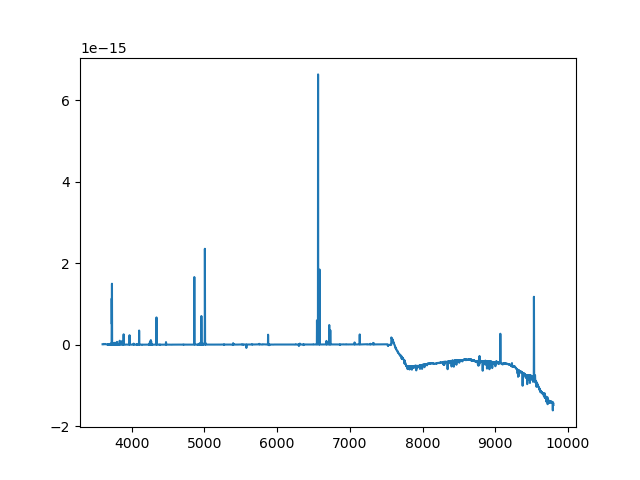

In [ ]:
with fits.open('/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/lagoon_integrated_spectrum_SB.fits') as hdul:  # reading the fits file

    header = hdul[1].header
    data = hdul[1].data

    wave = data['wave'].flatten()
    int_flux = data['flux'].flatten()

plt.plot(wave, int_flux)
plt.show()

In [ ]:
with fits.open('/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum//Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/Hgm_corr_SB_lagoon_integrated_obs_corr_flux_table.fits') as hdu:
    print(repr(hdu[1].header))
    data = hdu[1].data

with fits.open('/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/4643fitted_SB_lagoon_integrated_obs_flux_table.fits') as hdul:
    new_data = hdul[1].data

#print('OII 4641 flux after fitting 10 gaussian fits:',  data['NII_OII_flux4'], 'OII 4641 flux after fitting 11 gaussian fits:',new_data['NII_OII_flux4'], 'OII 4641 from OII line fits:',data['OII4638_flux1'])
#print()
#print('NII 4643 (1.37*flux of NII 4607):', 1.36*data['NII_OII_flux0'], 'NII 4643 on fitting the line:', new_data['NII_OII_flux5'])
#print()

print('[OIII]5007 snr', data['[OIII]5007_flux0']/data['[OIII]5007_flux0_err'], '[OIII]4363 snr', data['[OIII]4363_flux1']/data['[OIII]4363_flux1_err'])

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 7904 / length of dimension 1                          
NAXIS2  =                    1 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                  988 / number of table fields                         
TTYPE1  = 'NII_OII_flux0'                                                       
TFORM1  = 'D       '                                                            
TTYPE2  = 'NII_OII_flux0_err'                                                   
TFORM2  = 'D       '                                                            
TTYPE3  = 'NII_OII_wave0'   

In [ ]:
print('4643/4621', np.log10(1.37*data['NII_OII_flux0']/data['NII_OII_flux1']))

print('4643/4630', np.log10(1.37*data['NII_OII_flux0']/data['NII_OII_flux2']))

4643/4621 [0.27457123]
4643/4630 [-0.01960189]


In [ ]:
# Testing Perez montero equation 7

R = (data['[OIII]5007_flux0']+data['[OIII]4959_flux0'])/data['[OIII]4363_flux1']

print('RO3', R)

t = 0.7840-0.0001375*(R)+(48.44/R)
dt = 0.7840 - 0.0001375*(R+(R/258))+(48.44/(R+(R/258)))

print('Te[OIII]', t*1e4, dt*1e4, (t-dt)*1e4)


RO3 [692.88964233]
Te[OIII] [7586.37797005] [7579.9860117] [6.39195835]


In [ ]:
################################ Dust correction function ################################

In [ ]:
# Testing above observed and dust corrected fluxes and other ratios

In [ ]:
with fits.open('/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/Hgm_corr_SB_lagoon_integrated_obs_corr_flux_table.fits') as hdu:
    data = hdu[1].data

print(data['E_B_V'], data['E_B_V_err'])
print()
print('obs balmer decr 1', data['obs_Ha6563_flux0']/data['obs_Hb4861_flux0'])
print()
print('obs balmer decr 2', data['obs_Hgm4340_flux0']/data['obs_Hb4861_flux0'])
print()
print('int balmer decr 1', data['int_Ha6563_flux0']/data['int_Hb4861_flux0'])
print()
print('int balmer decr 2', data['int_Hgm4340_flux0']/data['int_Hb4861_flux0'])
print()
#print('OII4638', data['int_OII4638_flux2'], data['obs_OII4638_flux2'])
#print()
#print('[OIII]4363', data['int_[OIII]4363_flux1'], data['obs_[OIII]4363_flux1'])
#print()
    
oiisum = data['obs_NII_OII_flux3']+data['obs_NII_OII_flux4']+data['obs_NII_OII_flux5']+data['obs_NII_OII_flux6']+data['obs_NII_OII_flux8']+data['obs_NII_OII_flux9']
print(oiisum)
    
print('[OIII]5007/Hb', np.log10(data['int_[OIII]5007_flux0']/data['int_Hb4861_flux0']), np.log10(data['obs_[OIII]5007_flux0']/data['obs_Hb4861_flux0']))
print()

print('[SII]6717+31/Ha', np.log10((data['int_[SII]6717_flux0']+data['int_[SII]6731_flux0'])/data['int_Ha6563_flux0']), np.log10((data['obs_[SII]6717_flux0']+data['obs_[SII]6731_flux0'])/data['obs_Ha6563_flux0']))
print()
#print('Ha6563', data['int_Ha6563_flux0'], data['obs_Ha6563_flux0'])
#print()
#print('Hb4861', data['int_Hb4861_flux0'], data['obs_Hb4861_flux0'])
#print()
#print('[OII]3729', data['int_[OII]3726_flux1'], data['obs_[OII]3726_flux1'])


[1.23724989] [0.00051334]

obs balmer decr 1 [3.7859427]

obs balmer decr 2 [0.38996859]

int balmer decr 1 [2.38433155]

int balmer decr 2 [0.468]

[1.06319631e-17]
[OIII]5007/Hb [0.11260383] [0.1356933]

[SII]6717+31/Ha [-0.94710717] [-0.93349761]



In [ ]:
################################### Converting fits file to a text file ########################################

In [ ]:
# Open the FITS file and read the data
with fits.open('/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/lagoon_integrated_sframe_obs_corr_flux_10_1.1.2.dev0_spaxel_weighted.fits') as hdu:
    data = hdu[1].data
    header = hdu[1].header

# Create an empty list to store non-zero values and their labels
non_zero_data = []

# Iterate over all columns in the data
for label in data.columns.names:
    values = data[label]
    # Check for non-zero values and store them
    for value in values:
        if value != 0:
            non_zero_data.append((label, value))

# Write the non-zero data to a text table
output_file = '/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/lagoon_integrated_sframe_obs_corr_flux_10_1.1.2dev0.txt'
with open(output_file, 'w') as f:
    # Write header
    f.write('Label\tValue\n')
    # Write data
    for label, value in non_zero_data:
        f.write(f'{label}\t{value}\n')

print(f'Lagoon integrated obs corr flux table {output_file}')


Lagoon integrated obs corr flux table /Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/lagoon_integrated_sframe_obs_corr_flux_10_1.1.2dev.txt


In [ ]:
# Open the FITS file and read the data
with fits.open('/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/lagoon_Te_ne_abund_new.fits') as hdu:
    data = hdu[1].data
    header = hdu[1].header

# Get all column names from the FITS file
all_columns = data.columns.names

# Prepare the output file
output_file = '/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/lagoon_Te_ne_abund.csv'

# Write the data to a text file
with open(output_file, 'w') as f:
    # Write the header row (column names)
    f.write('\t'.join(all_columns) + '\n')
    
    # Write each row of values for all columns
    for i in range(len(data)):  # Loop through each spaxel (row)
        row = [str(data[col][i]) for col in all_columns]
        f.write('\t'.join(row) + '\n')

In [ ]:
####################################### Determining Te, ne, ans abundances using PyNeb #########################################

In [ ]:
# Number of iterations to reproduce Nimisha et. al. 2019 
niter = 5

# Load PyNeb packages
O3 = pn.Atom('O', 3)

# Monte Carlo simulation for TeO3
TO3 = np.zeros((niter))

for i in range(niter):
    f4363 = 8.87e-15 + np.random.normal(0, 0.6e-15)
    f5007 = 356.30e-15 + np.random.normal(0, 2.29e-15)
    n = 50  # Electron density is constant here

    try:
        TO3[i] = O3.getTemDen(f4363 / f5007, den=n, wave1=4363, wave2=5007)
        #print(f"Iteration {i}: TO3_value = {TO3[i]}")
    except Exception as e:
        print(f"Error in iteration {i} with ratio {f4363 / f5007}: {e}")

# Calculate mean and standard deviation of TeO3
TeO3 = np.nanmean(TO3)
TeO3err = np.std(TO3)

print('nimisha_2019_TeO3', TeO3)
print('nimisha_2019_TeO3err', TeO3err)

nimisha_2019_TeO3 17060.094226773585
nimisha_2019_TeO3err 635.7054516747191


In [ ]:
print()

RO3 = np.divide(table['int_[OIII]5007_flux0'],table['int_[OIII]4959_flux0'])
err = np.sqrt((table['int_[OIII]5007_flux0_err']/table['int_[OIII]5007_flux0'])**2 + (table['int_[OIII]4959_flux0_err']/table['int_[OIII]4959_flux0'])**2)
print(RO3)
print(RO3*err)


[3.23043432]
[0.00052658]


warng _ManageAtomicData: rec data not available for Al2
warng _ManageAtomicData: rec data not available for Ar2
warng _ManageAtomicData: rec data not available for Ar3
warng _ManageAtomicData: rec data not available for Ar4
warng _ManageAtomicData: rec data not available for Ar5
warng _ManageAtomicData: rec data not available for Ba2
warng _ManageAtomicData: rec data not available for Ba4
ERROR None: No data for this case B
ERROR None: No data for this case B
warng _ManageAtomicData: rec data not available for Ca5
warng _ManageAtomicData: rec data not available for Cl2
warng _ManageAtomicData: rec data not available for Cl3
warng _ManageAtomicData: rec data not available for Cl4
warng _ManageAtomicData: rec data not available for Fe3
warng _ManageAtomicData: rec data not available for K4
warng _ManageAtomicData: rec data not available for K5
warng _ManageAtomicData: rec data not available for Mg5
warng _ManageAtomicData: rec data not available for Mg7
ERROR None: No data for this case 

KeyError: "Key 'int_[SIII]6312_flux0' does not exist."

In [ ]:
max_length = max(len(lst) for lst in diagnostics_dict.values())

for key in diagnostics_dict:
    if len(diagnostics_dict[key]) < max_length:
        diagnostics_dict[key].extend([0] * (max_length - len(diagnostics_dict[key])))
 
diagnostics_dict = {key: np.array(value) for key, value in diagnostics_dict.items()}

table = Table(diagnostics_dict)

# Saving FITS table to a file
fits_file_path = '/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/Oct3_Hg_corr_lagoon_integrated_diagnostics_table.fits'
table.writeto(fits_file_path, overwrite=True)

print(f"Successfully saved FITS table to: {fits_file_path}")

TypeError: object of type 'numpy.float64' has no len()

ADF: 2.2479712162679464, error on ADF: 1.0064808836077819


(0.35179074608918093, 0.0028055306181196168)

In [ ]:
############## Testing emperical relation from Perez-Montero 2017 paper, eq. no. 28 and 13 ###############

# Calculating emperical TeN2 using observational TeO3
TO_3=(1/(TeO3*1e-4))

emp_TeN2 = 1.85/(TO_3 + 0.72)

print(TeO3, TeN2, emp_TeN2*1e4)

# Calculating emperical TeO2 using observational TeO3
emp_TeO2 = 2/(TO_3 +0.8)

emp_TeS2 = 0.7*emp_TeO2 + 0.12

print(TeO3, TeO2, emp_TeO2*1e4, TeS2, emp_TeS2*1e4)

7495.179897383229 8673.840739174393 9005.979423245364
7495.179897383229 11748.278338697073 9371.233387057602 7582.712024770834 7759.863370940321


In [ ]:
table = Table(diagnostics_dict)

# Saving FITS table to a file
fits_file_path = '/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/Oct3_Hg_corr_lagoon_integrated_diagnostics_table.fits'
table.writeto(fits_file_path, overwrite=True)

print(f"Successfully saved FITS table to: {fits_file_path}")

TypeError: len() of unsized object

In [ ]:
##################################### No Monte Carlo sims ###################################
atoms=pn.getAtomDict()
O3=pn.Atom('O',3)
S2=pn.Atom('S',2)
N2=pn.Atom('N',2)
O2=pn.Atom('O',2)
S3=pn.Atom('S',3)
Cl3 = pn.Atom('Cl', 3)

diagnostics_dict = {
    'RA':[],
    'Dec':[],
    'neO2' : [],
    'neS2' : [],
    'neCl3' : [],
    'TeO2' : [],  
    'TeN2' : [],
    'TeS3' : [],
    'TeS2' : [],   
    'TeO3' : [],
    'neO2err' : [],
    'neS2err' : [],
    'neCl3err' : [],
    'TeO2err' : [],  
    'TeN2err' : [],
    'TeS3err' : [],
    'TeS2err' : [],   
    'TeO3err' : [],
    'Opp_cel' : [],
    'Opp_cel_err' : [],
    'Op_cel' : [],
    'Op_cel_err' : [],
    'Spp_cel' : [],
    'Spp_cel_err' : [],
    'Np_cel' : [],
    'Np_cel_err' : [],
    'elemental_abund_O':[],
    'elemental_abund_S':[],
    'Opp_RL' : [],
    'Opp_RL_err' : []
    }

ne = 110 #cm-3, 
niter =1000

########################## TS3 temperature diagnostic #########################
TS3=np.zeros((niter))
for i in range (niter):

    f6312=table['int_[SIII]6312_flux0']+table['int_[SIII]6312_flux0_err']
    f9531=table['int_[SIII]9531_flux0']+table['int_[SIII]9531_flux0_err']
    TS3[i]=S3.getTemDen(f6312/f9531, den=ne, wave1=6312, wave2=9531)

print('len of TeS3:', TS3.shape)
TeS3 = np.nanmean(TS3 )
TeS3err = np.nanstd(TS3 )

print('mean TeS3', np.nanmean(TS3))
print('mean TeS3 err', np.nanmean(np.nanstd(TS3 )))
diagnostics_dict['TeS3']=TeS3
diagnostics_dict['TeS3err']=TeS3err

########################## TO2 temperature diagnostic  #########################
TO2=np.zeros((niter))
for i in range (niter):
    f3726 = table['int_[OII]3726_flux0']+table['int_[OII]3726_flux0_err']
    f3729 = table['int_[OII]3726_flux1']+table['int_[OII]3726_flux1_err']
    f7320 = table['int_[OII]7320_flux0']+table['int_[OII]7320_flux0_err']
    f7330 = table['int_[OII]7330_flux0']+table['int_[OII]7330_flux0_err']

    TO2[i] = O2.getTemDen((f7320+f7330)/(f3726+f3729), den=ne, to_eval = '(L(7320)+L(7330))/(L(3726)+L(3729))')
TeO2 = np.nanmean(TO2 )
TeO2err = np.nanstd(TO2 )

print('mean TeO2', np.nanmean(TO2))
print('mean TeO2 err', np.nanmean(np.nanstd(TO2 )))
diagnostics_dict['TeO2']=TeO2
diagnostics_dict['TeO2err']=TeO2err

########################## TO3 temperature diagnostic #########################
TO3 = np.zeros((niter))
for i in range (niter):

    f4363 = table['int_[OIII]4363_flux1']+table['int_[OIII]4363_flux1_err']
    f5007 = table['int_[OIII]5007_flux0']+table['int_[OIII]5007_flux0_err']
    TO3[i] = O3.getTemDen((f4363)/(f5007), den=ne, wave1=4363, wave2=5007)

TeO3 = np.nanmean(TO3) 
TeO3err = np.nanstd(TO3 )

print('mean TeO3', np.nanmean(TO3))
print('mean TeO3 err', np.nanmean(TeO3err))

diagnostics_dict['TeO3']=TeO3
diagnostics_dict['TeO3err']=TeO3err

########################## TN2 temperature diagnostic #########################
TN2=np.zeros((niter))
for i in range (niter):

    f5755=table['int_[NII]5755_flux0']+table['int_[NII]5755_flux0_err']
    f6584=3.05*table['int_[NII]6548_flux0']+table['int_[NII]6584_flux0_err']
    TN2[i]=N2.getTemDen(f5755/f6584, den=ne, wave1=5755, wave2=6584)

TeN2 = np.nanmean(TN2 )
TeN2err = np.nanstd(TN2 )

print('mean TeN2', np.nanmean(TN2))
print('mean TeN2err', np.nanmean(np.nanstd(TN2 )))

diagnostics_dict['TeN2']=TeN2
diagnostics_dict['TeN2err']=TeN2err     

########################## TS2 temperature diagnostic #########################
TS2=np.zeros((niter))
for i in range (niter):
    f4069=table['int_[SII]4069_flux0']+table['int_[SII]4069_flux0_err']
    f4077=table['int_[SII]4069_flux1']+table['int_[SII]4069_flux1_err']
    f6717=table['int_[SII]6717_flux0']+table['int_[SII]6717_flux0_err']
    f6731=table['int_[SII]6731_flux0']+table['int_[SII]6731_flux0_err']
    TS2[i]=S2.getTemDen((f4069+f4077)/(f6717+f6731), den=ne, wave1=4073, wave2=6724)
    
TeS2 = np.nanmean(TS2 )
TeS2err = np.nanstd(TS2 )

print('mean TeS2', np.nanmean(TS2))
print('mean TeS2 err', np.nanmean(np.nanstd(TS2)))

diagnostics_dict['TeS2']=TeS2
diagnostics_dict['TeS2err']=TeS2err      

############################################################## Electron density diagnostics #############################################################
########################## NO2 electron density diagnostic #########################
NO2=np.zeros((niter))
for i in range (niter):

    f3726=table['int_[OII]3726_flux0']+table['int_[OII]3726_flux0_err']
    f3729=table['int_[OII]3726_flux1']+table['int_[OII]3726_flux1_err']
    NO2[i]=O2.getTemDen(f3726/f3729, tem=TN2[i], wave1=3726, wave2=3729)

neO2 = np.nanmean(NO2 )
neO2err = np.nanstd(NO2 )

print('mean neO2', np.nanmean(NO2))
print('mean neO2 err', np.nanmean(np.nanstd(NO2)))

diagnostics_dict['neO2']=neO2
diagnostics_dict['neO2err']=neO2err  

########################## NS2 electron density diagnostic #########################
NS2=np.zeros((niter))
for i in range (niter):
    f6717=table['int_[SII]6717_flux0']+table['int_[SII]6717_flux0_err']
    f6731=table['int_[SII]6731_flux0']+table['int_[SII]6731_flux0_err']
    NS2[i]=S2.getTemDen(f6731/f6717, tem=TN2[i], wave1=6731, wave2=6717) 

neS2 = np.nanmean(NS2 )
neS2err = np.nanstd(NS2 )

print('mean neS2', np.nanmean(NS2))
print('mean neS2 err', np.nanmean(np.nanstd(NS2 )))

diagnostics_dict['neS2']=neS2
diagnostics_dict['neS2err']=neS2err

########################## NCl3 electron density diagnostic #########################
NCl3=np.zeros((niter))
for i in range (niter):

    f5517=table['int_[ClIII]5517_flux0']+table['int_[ClIII]5517_flux0_err']
    f5537=table['int_[ClIII]5537_flux0']+table['int_[ClIII]5537_flux0_err']
    NCl3[i]=Cl3.getTemDen(f5537/f5517, tem=TN2[i], wave1=5537, wave2=5517)

neCl3 = np.nanmean(NCl3 )
neCl3err = np.nanstd(NCl3 )

print('mean neCl3', np.nanmean(NCl3))
print('mean neCl3 err', np.nanmean(np.nanstd(NCl3 )))

diagnostics_dict['neCl3']=neCl3
diagnostics_dict['neCl3err']=neCl3err  

print()
############################################################## Calculating ionic abunadnces ################################################
# Calculating ionic abundance for following ion
# O+/H+ ionic abundance
Op_cel=np.zeros((niter))
for i in range (niter):

    f3726 = table['int_[OII]3726_flux0']+table['int_[OII]3726_flux0_err']
    f3729 = table['int_[OII]3726_flux1']+table['int_[OII]3726_flux1_err']
    f4861 = table['int_Hb4861_flux0']+table['int_Hb4861_flux0_err']
    Int_Oph = np.divide((f3726+f3726),f4861)
    Op_cel[i]=12+np.log10(O2.getIonAbundance(int_ratio=100*(Int_Oph), tem= TN2[i], den= NS2[i], to_eval='L(3726)+L(3729)'))

diagnostics_dict['Op_cel']=np.nanmean(Op_cel)
diagnostics_dict['Op_cel_err']= np.nanstd(Op_cel)

print('mean Op_cel', np.nanmean(Op_cel))
print('mean Op_cel_err', np.nanmean(np.nanstd(Op_cel)))


######################### O++/H+ ionic abundance ######################### 
Opp_cel=np.zeros((niter))
for i in range (niter):
    f5007 = table['int_[OIII]5007_flux0']+table['int_[OIII]5007_flux0_err']
    f4861 = table['int_Hb4861_flux0']+table['int_Hb4861_flux0_err']
    Int_Opph = np.divide(f5007,f4861)
    Opp_cel[i]=12+np.log10(O3.getIonAbundance(int_ratio=100*(Int_Opph), tem= TO3[i], den= NS2[i], to_eval='L(5007)'))

diagnostics_dict['Opp_cel']=np.nanmean(Opp_cel )
diagnostics_dict['Opp_cel_err']= np.nanstd(Opp_cel )

print('mean Opp_cel', np.nanmean(Opp_cel))
print('mean Opp_cel_err', np.nanmean(np.nanstd(Opp_cel)))


##########################  N+/H+ ionic abundance ######################### 
Np_cel=np.zeros((niter))
for i in range (niter):
    f6584 = 3.05*table['int_[NII]6548_flux0']+table['int_[NII]6584_flux0_err']
    f4861 = table['int_Hb4861_flux0']+table['int_Hb4861_flux0_err']
    Int_Nph = np.divide(f6584,f4861)
    Np_cel[i]=12+np.log10(N2.getIonAbundance(int_ratio=100*(Int_Nph), tem= TN2[i], den= NS2[i], to_eval='L(6584)'))

diagnostics_dict['Np_cel']=np.nanmean(Np_cel )
diagnostics_dict['Np_cel_err']= np.nanstd(Np_cel )

print('mean Np_cel', np.nanmean(Np_cel))
print('mean Np_cel_err', np.nanmean(np.nanstd(Np_cel)))

##########################  S+/H+ ionic abundance  ######################### 
Sp_cel=np.zeros((niter))
for i in range (niter):

    f6717 = table['int_[SII]6717_flux0']+table['int_[SII]6717_flux0_err']
    f6731 = table['int_[SII]6731_flux0']+table['int_[SII]6731_flux0_err']
    
    f4861 = table['int_Hb4861_flux0']+table['int_Hb4861_flux0_err']
    Int_Sph = np.divide((f6717+f6731),f4861)
    Sp_cel[i]=12+np.log10(S2.getIonAbundance(int_ratio=100*(Int_Sph), tem= TN2[i], den= NS2[i], to_eval='L(6717)+L(6731)'))

diagnostics_dict['Sp_cel']=np.nanmean(Sp_cel )
diagnostics_dict['Sp_cel_err']= np.nanstd(Sp_cel )

print('mean Sp_cel', np.nanmean(Sp_cel))
print('mean Sp_cel_err', np.nanmean(np.nanstd(Sp_cel)))

##########################  S++/H+ ionic abundance  ######################### 
Spp_cel=np.zeros((niter))
for i in range (niter):
    
    f9069 = table['int_[SIII]9069_flux0']+table['int_[SIII]9069_flux0_err']
    f9531 = table['int_[SIII]9531_flux0']+table['int_[SIII]9531_flux0_err']
    f4861 = table['int_Hb4861_flux0']+table['int_Hb4861_flux0_err']

    Int_Spph = np.divide((f9531),f4861)
    Spp_cel[i]=12+np.log10(S3.getIonAbundance(int_ratio=100*(Int_Spph), tem= TS3[i], den= NS2[i], to_eval='L(9531)'))

diagnostics_dict['Spp_cel']=np.nanmean(Spp_cel )
diagnostics_dict['Spp_cel_err']= np.nanstd(Spp_cel)

print('mean Spp_cel', np.nanmean(Spp_cel))
print('median Spp_cel_err', np.nanmean(np.nanstd(Spp_cel)))


######################### Elemental abundance ######################### 

elemental_abund_O = 10 ** (Opp_cel - 12) + 10 ** (Op_cel - 12)
elemental_abund_S = 10 ** (Spp_cel - 12) + 10 ** (Sp_cel - 12)

diagnostics_dict['elemental_abund_O']=elemental_abund_O
diagnostics_dict['elemental_abund_S']=elemental_abund_S
print('elemental_abund_O: ', np.nanmean(12 + np.log10(elemental_abund_O)))
print('elemental_abund_S: ', np.nanmean(12 + np.log10(elemental_abund_S)))

######################### O++/H+ RL abundance ######################### 


O2 = pn.RecAtom('O', 2)
Opp_RL=np.zeros((niter))
for i in range (niter):

    f4638 = table['int_OII4638_flux0']+table['int_OII4638_flux0_err']
    f4641 = table['int_OII4638_flux1']+table['int_OII4638_flux1_err']
    f4649 = table['int_OII4638_flux2']+table['int_OII4638_flux2_err']
    f4650 = table['int_OII4638_flux3']+table['int_OII4638_flux3_err']
    f4662 = table['int_OII4638_flux5']+table['int_OII4638_flux5_err']
    f4676 = table['int_OII4638_flux6']+table['int_OII4638_flux6_err']       

    f4861 = table['int_Hb4861_flux0']+table['int_Hb4861_flux0_err']
    
    Int_OII_v2 = np.divide((f4638+f4641+f4649+f4650+f4662+f4676),f4861)
    Opp_rec_v2 =12+np.log10( O2.getIonAbundance(int_ratio=Int_OII_v2*100, tem= TO3[i], den= NS2[i], to_eval='L(4638.86)+L(4641.81)+L(4649.13)+L(4650.84)+L(4661.63)+L(4676.23)'))
 
diagnostics_dict['Opp_RL']=np.nanmean(Opp_rec_v2)
diagnostics_dict['Opp_RL_err']= np.nanstd(Opp_rec_v2)

print('mean Opp_RL', np.nanmean(Opp_rec_v2))
print('mean Opp_RL_err', np.nanmean(np.nanstd(Opp_rec_v2)))


warng _ManageAtomicData: rec data not available for Al2
warng _ManageAtomicData: rec data not available for Ar2
warng _ManageAtomicData: rec data not available for Ar3
warng _ManageAtomicData: rec data not available for Ar4
warng _ManageAtomicData: rec data not available for Ar5
warng _ManageAtomicData: rec data not available for Ba2
warng _ManageAtomicData: rec data not available for Ba4
ERROR None: No data for this case B
ERROR None: No data for this case B
warng _ManageAtomicData: rec data not available for Ca5
warng _ManageAtomicData: rec data not available for Cl2
warng _ManageAtomicData: rec data not available for Cl3
warng _ManageAtomicData: rec data not available for Cl4
warng _ManageAtomicData: rec data not available for Fe3
warng _ManageAtomicData: rec data not available for K4
warng _ManageAtomicData: rec data not available for K5
warng _ManageAtomicData: rec data not available for Mg5
warng _ManageAtomicData: rec data not available for Mg7
ERROR None: No data for this case 

NameError: name 'table' is not defined

In [ ]:
###################################### testing non-parametric fit ####################################

In [ ]:
with fits.open('/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/lagoon_integrated_spectrum_SB.fits') as hdu:
    data = hdu[1].data
    print(repr(hdu[1].header))

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =               198416 / length of dimension 1                          
NAXIS2  =                    1 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    3 / number of table fields                         
TTYPE1  = 'wave    '                                                            
TFORM1  = '12401E  '                                                            
TDIM1   = '(12401) '                                                            
TTYPE2  = 'flux    '                                                            
TFORM2  = '12401D  '        

In [ ]:
# Measure line fluxes by direct integration off the spectra and add to table
lidlist=['[OIII]4363' 'HI4861', '[OIII]5007', 'OII4676.2', 'OII4696', 'OII4641.8', 'CII4267', 'CII5342', 'OII4638.85', 'OII4641.81', 
        'OII4650v2']

lwavelist=[4363, 4861, 5007, 4676.2, 4696.35, 4641.8, 4267.25, 5342, 4638.85, 4649]

lrangelist=[(4361,4365), (4859,4863), (5005,5009), (4649, 4652), (4657.5, 4659.5), (4675, 4677), (4695.3, 4698), (4640, 4643), (4266.96, 4269), (5341.5, 5343.5), (4637.5, 4640.5), (4641, 4645.5), (4648.5, 4653)]

crangelist=[(4370, 4380), (4875,4885), (5019,5035), (6315,6320), (6607,6625), (6737,6747), (6737,6747), (7307,7313), (7307,7313), (3733,3740), (3733,3740), 
            (4645, 4649), (4653, 4656), (4671, 4675),  (4693, 4695), (4632, 4638), (4270, 4275), (5349, 5354), (4633.5, 4637.5), (4633.5, 4637.5), (4633.5, 4637.5)]

def sumlineflux(table, lidlist, lwavelist, lrangelist, crangelist):

    rssfile = '/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/lagoon_integrated_spectrum_SB.fits'
    fitsfile=fits.open(rssfile)
    rss = fitsfile[1].data
    wave=rss['wave'].data
    flux=rss['flux'].data
    error=rss['error'].data

        
    auxlinetab=Table()

    for j in range(len(lidlist)):

        lsel=(wave>=lrangelist[j][0])*(wave<=lrangelist[j][1])
        csel=(wave>=crangelist[j][0])*(wave<=crangelist[j][1])
        fluxsel=flux[:,lsel] # select line range 

        cfluxsel=fluxsel-np.tile(np.nanmedian(flux[:,csel], axis=1), (np.shape(fluxsel)[1],1)).transpose() # subtract continuum

        dpix=0.5  # pixel width in Angstroms

        lflux=np.nansum(cfluxsel*dpix, axis=1)
        lerror=np.sqrt(np.nansum((error[:,lsel]*dpix)**2, axis=1))
        #fluxcol = Column(lflux, name='flux_'+lidlist[j])
        #errorcol = Column(lerror, name='error_'+lidlist[j])
        auxlinetab['flux_'+lidlist[j]]=lflux
        auxlinetab['error_'+lidlist[j]]=lerror

    return vstack([table, auxlinetab])    


linetab=Table()

linetab=sumlineflux(linetab, lidlist, lwavelist, lrangelist, crangelist)
print(linetab)

TypeError: '>=' not supported between instances of 'memoryview' and 'int'

In [ ]:
import numpy as np
from astropy.io import fits
from astropy.table import Table, vstack

# Step 1: Define input lists
lidlist = ['[OIII]4363', 'HI4861', '[OIII]5007', 'OII4676.2', 'OII4696', 'OII4641.8', 
           'CII4267', 'CII5342', 'OII4638.85', 'OII4650v2']

lwavelist = [4363, 4861, 5007, 4676.2, 4696.35, 4641.8, 4267.25, 5342, 4638.85, 4649]

lrangelist = [(4361, 4365), (4859, 4863), (5005, 5009), (4675, 4677), (4695.3, 4698), 
              (4640, 4643), (4266.96, 4269), (5341.5, 5343.5), (4637.5, 4640.5), 
              (4648.5, 4653)]

crangelist = [(4370, 4380), (4875, 4885), (5019, 5035), (6315, 6320), (6607, 6625), 
              (6737, 6747), (7307, 7313), (3733, 3740), (4645, 4649),
              (4671, 4675)]

# Step 2: Function to read the FITS file and extract wavelength, flux, and error arrays
def load_spectrum_data(fits_file):
    with fits.open(fits_file) as fitsfile:
        data = fitsfile[1].data
        wave = np.array(data['wave'])
        flux = np.array(data['flux'])
        error = np.array(data['error'])
    return wave, flux, error

# Step 3: Function to calculate line fluxes and continuum subtraction
def calculate_fluxes(wave, flux, error, lidlist, lrangelist, crangelist, dpix=0.5):
    results = Table()

    for j, line_id in enumerate(lidlist):
        line_range = lrangelist[j]
        cont_range = crangelist[j]
        
        # Select the wavelength ranges
        line_mask = (wave >= line_range[0]) & (wave <= line_range[1])
        cont_mask = (wave >= cont_range[0]) & (wave <= cont_range[1])
        
        # Calculate median continuum level
        cont_flux = np.nanmedian(flux[cont_mask])
        
        # Calculate line flux (continuum-subtracted)
        line_flux = np.nansum((flux[line_mask] - cont_flux) * dpix)
        line_error = np.sqrt(np.nansum((error[line_mask] * dpix) ** 2))
        
        # Store results in a table
        results['flux_' + line_id] = [line_flux]
        results['error_' + line_id] = [line_error]

    return results

# Step 4: Define the main function to run the script
def main():
    # FITS file path (adjust path as needed)
    fits_file = '/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/lagoon_integrated_spectrum_SB.fits'
    
    # Load data
    wave, flux, error = load_spectrum_data(fits_file)
    
    # Calculate line fluxes
    flux_results = calculate_fluxes(wave, flux, error, lidlist, lwavelist, lrangelist, crangelist)
    
    # Combine results with the existing table (if needed)
    linetab = Table()  # Initialize empty table
    
    # Directly assign results to linetab instead of using vstack
    linetab = flux_results
    
    # Print or save results
    print(linetab)

# Run the main function
if __name__ == "__main__":
    main()


TypeError: 'int' object is not subscriptable